%md
# Fraud Transaction Detection Using Distributed SMOTE and Global Decision Tree on PySpark

### Mohammed Tahir Shaik - Individual Contribution For all the steps below in the Pipeline


**Module:** COMP4124 Big Data
**Dataset:** PaySim - 6,362,620 mobile money transactions, 0.13% fraud rate
**Dataset Source:** Lopez-Rojas et al. (2016) — https://www.kaggle.com/datasets/ealaxi/paysim1

**3 Smote approaches**

**Global Decision Tree Implementation**,
**Size up analysis and Partition Count Vs Accuracy for global Decision Tree**
---

## Pipeline Overview

| Step | Description |
|------|-------------|
| **1** | **Environment Setup** - Importing libraries  |
| **2** | **Data Ingestion** - Loading the PaySim CSV into a Spark DataFrame |
| **3** | **Schema Correction** - Casting all columns to correct numeric types |
| **4** | **Exploratory Analysis & Filtering** - Analysing fraud by payment type, dropping irrelevant columns and zero fraud types |
| **5** | **Feature Encoding** - One hot encoding the categorical type column |
| **6** | **Feature Assembly** - Building the final feature array for modelling |
| **7** | **Stratified Train/Test Split** - Splitting data while preserving class ratio |
| **8** | **SMOTE Core Function** - KDTree  based synthetic sample generation |
| **9** | **Approach 1: Broadcast Global SMOTE** - Broadcasting minority to all workers for global KNN |
| **10** | **Approach 2: Local SMOTE** - Partition local KNN with no inter node communication |
| **11** | **Approach 3: Shuffle-Based SMOTE** - Redistributing minority via shuffle then applying local SMOTE |
| **12** | **Custom Global Distributed Decision Tree** - Histogram based split finding with distributed training |
| **13** | **Evaluation Function** - Confusion matrix and classification metrics |
| **14-17** | **Model Training & Evaluation** - Training and evaluating each SMOTE approach + baseline |
| **18** | **Results Summary** - Compararing results  |
| **19** | **Visualisations** - Class distribution, metrics comparison, confusion matrices, timing |
| **20** | **Scalability Experiment** - Size-up analysis of the Global distributed decision tree |
| **21** | **Evaluation Experiment** - Partition Count Vs Accuracy for the global decision tree |

## Research Questions
### 1) How to implement different class imbalance techniques like undersampling, oversampling and class weights and different classification algorithms like Decision Tree , Gradient Boosting and Adaboost in distributed design for this dataset?

### 
### 2) Size up analysis of these implementations , which implementation follows linear, sub linear and super linear and why?
### 3)   How the accuracy changes with change in the partitions count whether the implementations folllowing ideal case or not and why? 





## Step 1 - Environment Setup
Importing all required libraries


In [0]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField, IntegerType, ArrayType, DoubleType, StringType
)
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.functions import vector_to_array
import numpy as np
from scipy.spatial import KDTree
from collections import Counter,defaultdict
import time
import matplotlib.pyplot as plt


sc = spark.sparkContext


## Step 2 - Data Ingestion
Load the raw PaySim CSV (~6.3M rows) from Azure Databricks mounted storage. The dataset simulates one month of mobile money transactions across five payment types.

In [0]:
#author: Mohammed Tahir
#loading the data 
df = spark.read.csv('/mnt/2026-group10/Mohammed_Tahir/Synthetic_Financial_Data.csv', header=True)
df.show(10)
print(f"Total rows: {df.count()}")
df.printSchema()

+----+--------+--------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|step|    type|  amount|   nameOrig|oldbalanceOrg|newbalanceOrig|   nameDest|oldbalanceDest|newbalanceDest|isFraud|isFlaggedFraud|
+----+--------+--------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|   1| PAYMENT| 9839.64|C1231006815|     170136.0|     160296.36|M1979787155|           0.0|           0.0|      0|             0|
|   1| PAYMENT| 1864.28|C1666544295|      21249.0|      19384.72|M2044282225|           0.0|           0.0|      0|             0|
|   1|TRANSFER|   181.0|C1305486145|        181.0|           0.0| C553264065|           0.0|           0.0|      1|             0|
|   1|CASH_OUT|   181.0| C840083671|        181.0|           0.0|  C38997010|       21182.0|           0.0|      1|             0|
|   1| PAYMENT|11668.14|C2048537720|      41554.0|      29885.86|M1230701703|      


## Step 3 - Schema Correction & Class Distribution
All columns are read as strings by default from CSV. Casting numeric columns to their correct types (integer/double) and inspecting the count of class distribution 

In [0]:
#author: Mohammed Tahir
#casting columns to correct data types and inspecting the class distribution

df = (
    df
    .withColumn("step", F.col("step").cast("integer"))
    .withColumn("amount", F.col("amount").cast("double"))
    .withColumn("oldbalanceOrg", F.col("oldbalanceOrg").cast("double"))
    .withColumn("newbalanceOrig", F.col("newbalanceOrig").cast("double"))
    .withColumn("oldbalanceDest", F.col("oldbalanceDest").cast("double"))
    .withColumn("newbalanceDest", F.col("newbalanceDest").cast("double"))
    .withColumn("isFraud", F.col("isFraud").cast("integer"))
    .withColumn("isFlaggedFraud", F.col("isFlaggedFraud").cast("integer"))
)

df.groupBy("isFraud").count().show()

+-------+-------+
|isFraud|  count|
+-------+-------+
|      1|   8213|
|      0|6354407|
+-------+-------+




## Step 4 - Exploratory Analysis & Feature Filtering




       type    total  fraud_count  fraud_pct
0  CASH_OUT  2237500         4116     0.1840
1  TRANSFER   532909         4097     0.7688
2   CASH_IN  1399284            0     0.0000
3   PAYMENT  2151495            0     0.0000
4     DEBIT    41432            0     0.0000


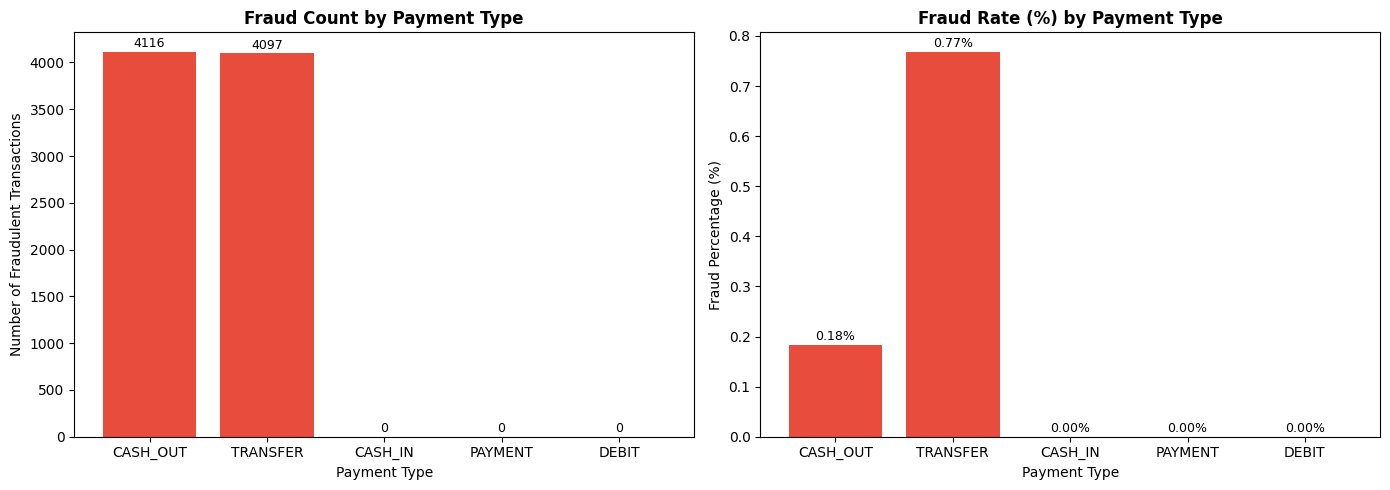

Rows after filtering: 2,770,409


In [0]:
#author: Mohammed Tahir
# nameOrig has 6.3M unique IDs, nameDest has 2.2M unique IDs
# High cardinality identifiers encoding impossible for distance based SMOTE 
# isFlaggedFraud is rule based fraud detection so target leakage feature
# step is Hourly time step of the simulation, weak discriminative signal
#dropping all the four columns 

cleaned_df = df.drop("step", "nameOrig", "nameDest", "isFlaggedFraud")


# Fraud Distribution by Payment Type
# counting the number of  fraud vs non fraud for each payment type
fraud_by_type = (
    cleaned_df
    .groupBy("type")
    .agg(
        F.count("*").alias("total"),
        F.sum("isFraud").alias("fraud_count"),
        F.round(F.mean("isFraud") * 100, 4).alias("fraud_pct")
    )
    .orderBy(F.desc("fraud_count"))
    .toPandas()
)

print(fraud_by_type)

# bar chart: fraud count by payment type
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Left: absolute fraud counts
colors = ['#e74c3c' if x > 0 else '#95a5a6' for x in fraud_by_type['fraud_count']]
ax[0].bar(fraud_by_type['type'], fraud_by_type['fraud_count'], color=colors)
ax[0].set_title('Fraud Count by Payment Type', fontweight='bold')
ax[0].set_xlabel('Payment Type')
ax[0].set_ylabel('Number of Fraudulent Transactions')
for i, v in enumerate(fraud_by_type['fraud_count']):
    ax[0].text(i, v + 50, str(int(v)), ha='center', fontsize=9)

# right: fraud percentage
ax[1].bar(fraud_by_type['type'], fraud_by_type['fraud_pct'], color=colors)
ax[1].set_title('Fraud Rate (%) by Payment Type', fontweight='bold')
ax[1].set_xlabel('Payment Type')
ax[1].set_ylabel('Fraud Percentage (%)')
for i, v in enumerate(fraud_by_type['fraud_pct']):
    ax[1].text(i, v + 0.01, f'{v:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('fraud_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

# Only TRANSFER and CASH_OUT contain fraudulent transactions
# Other types have zero fraud cases
# Filtering them out removes  nearly 3.5M non informative rows


cleaned_df = cleaned_df.filter(F.col("type").isin("TRANSFER", "CASH_OUT"))
cleaned_df = cleaned_df.withColumn("balanceDiffOrig", F.col("oldbalanceOrg") - F.col("newbalanceOrig"))
cleaned_df = cleaned_df.withColumn("balanceDiffDest", F.col("newbalanceDest") - F.col("oldbalanceDest"))
print(f"Rows after filtering: {cleaned_df.count():,}")


## Step 5 -Feature Encoding
One hot encoding the type column (TRANSFER vs CASH_OUT). Since only two categories remain after filtering this produces a single binary feature type_0

In [0]:
#author: Mohammed Tahir
#one hot encoding for transaction type column
type_indexer = StringIndexer(inputCol="type", outputCol="typeIndex")
type_encoder = OneHotEncoder(inputCol="typeIndex", outputCol="typeVec")
 
indexer_model = type_indexer.fit(cleaned_df)
cleaned_df = indexer_model.transform(cleaned_df)
encoder_model = type_encoder.fit(cleaned_df)
cleaned_df = encoder_model.transform(cleaned_df)
 
num_type_categories = int(
    cleaned_df.select(F.max("typeIndex")).collect()[0][0] + 1
)
print(f"Transaction type categories: {num_type_categories}")


Transaction type categories: 2



## Step 6 - Feature Array Assembly
Combining all numeric features and the encoded type column into a single features array column


In [0]:
#author: Mohammed Tahir
#buildding the feature array 
cleaned_df = cleaned_df.withColumn("typeArr", vector_to_array("typeVec"))
 
for i in range(num_type_categories - 1):
    cleaned_df = cleaned_df.withColumn(
        f"type_{i}", F.col("typeArr").getItem(i).cast("double")
    )
 
numeric_cols = [
     "amount", "oldbalanceOrg", "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest", "balanceDiffOrig", "balanceDiffDest"
]
type_feature_cols = [f"type_{i}" for i in range(num_type_categories - 1)]
all_feature_cols = numeric_cols + type_feature_cols
 
feature_df = cleaned_df.select(
    [F.col(c).cast("double") for c in all_feature_cols] + [F.col("isFraud")]
)
feature_df = feature_df.withColumn(
    "features", F.array([F.col(c) for c in all_feature_cols])
)
feature_df = feature_df.select("features", "isFraud")
feature_df.cache()
 
print(f"Feature columns ({len(all_feature_cols)}): {all_feature_cols}")

Feature columns (8): ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'balanceDiffOrig', 'balanceDiffDest', 'type_0']



## Step 7 - Stratified Train/Test Split
Splitting the data 80/20 while preserving the fraud class ratio in both sets. 

The training set is then separated into majority (non fraud) and minority (fraud) subsets to calculate how many synthetic samples SMOTE needs to generate. Target ratio is **1:4** (minority:majority)

In [0]:
#author: Mohammed Tahir
#splitting the data into train and test sets
# stratified split preserves fraud ratio in both sets
fraud_df = feature_df.filter(F.col("isFraud") == 1)
non_fraud_df = feature_df.filter(F.col("isFraud") == 0)

fraud_train, fraud_test = fraud_df.randomSplit([0.8, 0.2], seed=42)
non_fraud_train, non_fraud_test = non_fraud_df.randomSplit([0.8, 0.2], seed=42)

train_df = fraud_train.union(non_fraud_train)
test_df = fraud_test.union(non_fraud_test)

train_df.cache()
test_df.cache()

 
train_majority = train_df.filter(F.col("isFraud") == 0)
train_minority = train_df.filter(F.col("isFraud") == 1)
 
majority_count = train_majority.count()
minority_count = train_minority.count()
 
print(f"Training majority: {majority_count}")
print(f"Training minority: {minority_count}")
print(f"Imbalance ratio: 1:{majority_count // minority_count}")
 
target_minority_total = majority_count // 4
synthetics_needed = target_minority_total - minority_count
print(f"Synthetics needed (1:4 target): {synthetics_needed}")

Training majority: 2209514
Training minority: 6575
Imbalance ratio: 1:336
Synthetics needed (1:4 target): 545803



## Step 8 - SMOTE Core Function
The smote_generate function implements the core SMOTE (Synthetic Minority Oversampling Technique) algorithm:

1. Building a **KDTree** from the minority sample pool for efficient nearest neighbour lookup
2. For each seed sample finding its k nearest minority neighbours
3. Randomly selecting one neighbour and interpolating: synthetic = seed + lambda * (neighbour - seed)

This function is called by all three distributed SMOTE approaches, they differ only in **which minority samples are available** as the neighbour pool

In [0]:
#author: Mohammed Tahir
#generating synthetic samples using KDTree data structure 
def smote_generate(minority_samples, indices_to_oversample, all_minority, k=5, seed=None):
    rng = np.random.RandomState(seed)
 
    if len(all_minority) < k + 1:
        k = max(1, len(all_minority) - 1)
 
    tree = KDTree(all_minority)
    synthetics = []
 
    for idx in indices_to_oversample:
        sample = minority_samples[idx]
        distances, neighbour_ids = tree.query(sample, k=k + 1)
 
        valid_neighbours = [
            nid for nid in neighbour_ids
            if not np.allclose(all_minority[nid], sample)
        ][:k]
 
        if len(valid_neighbours) == 0:
            valid_neighbours = list(neighbour_ids[1:k + 1])
 
        nn_idx = valid_neighbours[rng.randint(0, len(valid_neighbours))]
        neighbour = all_minority[nn_idx]
 
        lam = rng.uniform(0, 1)
        synthetic = sample + lam * (neighbour - sample)
        synthetics.append(synthetic)
 
    return np.array(synthetics) if synthetics else np.empty((0, minority_samples.shape[1]))
 

### Answering Research Question 1 implemented 3 SMOTE approaches and Global Decision Tree in the steps below


## Step 9 - Approach 1: Broadcast Global SMOTE
**Strategy:** Collecting all minority samples to the driver and broadcasting them to every worker. Each partition generates its proportional share of synthetics using the **full global minority pool** for KNN

**Advantage:** Highest quality synthetic samples  every seed has access to all possible neighbours regardless of partition boundaries

**Trade-off:** Requires collecting minority data to the driver and broadcasting to all workers. Safe here since minority class is only 6K samples but would cause driver OOM with large minority sets.



In [0]:
#author: Mohammed Tahir

def broadcast_global_smote(train_majority, train_minority, synthetics_needed, k=5, seed=42):
    start_time = time.time()
 
    # collecting minority to driver 
    minority_rows = train_minority.select("features").collect()
    minority_array = np.array([row["features"] for row in minority_rows])
    n_minority = len(minority_array)
    print(f"[Broadcast Global] Collected {n_minority} minority samples")
 
    # broadcasting minority to all workers
    minority_bc = sc.broadcast(minority_array)
 
    # getting partition count and compute work distribution
    num_partitions = train_majority.rdd.getNumPartitions()
    base_per_partition = synthetics_needed // num_partitions
    remainder = synthetics_needed % num_partitions
    print(f"[Broadcast-Global] Using {num_partitions} partitions")
 
    # creating a DataFrame with partition assignments
    # each row is one partition's work assignment
    
    partition_assignments = [(i,) for i in range(num_partitions)]
    work_df = spark.createDataFrame(
        partition_assignments,
        StructType([StructField("partition_id", IntegerType(), False)])
    ).repartition(num_partitions)
 
    # broadcasting work parameters
    base_bc = sc.broadcast(base_per_partition)
    remainder_bc = sc.broadcast(remainder)
    n_minority_bc = sc.broadcast(n_minority)
    num_partitions_bc = sc.broadcast(num_partitions)
    k_bc = sc.broadcast(k)
    seed_bc = sc.broadcast(seed)
 
    # using applyInPandas 
    # groups by partition_id each group runs SMOTE independently
    import pandas as pd
 
    output_schema = StructType([
        StructField("features", ArrayType(DoubleType()), False),
        StructField("isFraud", IntegerType(), False)
    ])
 
    def generate_synthetics(pdf):
        partition_id = int(pdf["partition_id"].iloc[0])
        all_minority = minority_bc.value
        n_total = n_minority_bc.value
        n_parts = num_partitions_bc.value
 
        # counting how many synthetics this partition generates
        my_count = base_bc.value + (1 if partition_id < remainder_bc.value else 0)
        if my_count == 0:
            return pd.DataFrame({"features": [], "isFraud": []})
 
        # assigning non overlapping slice of minority as seeds
        start = (partition_id * n_total) // n_parts
        end = ((partition_id + 1) * n_total) // n_parts
        my_seeds = all_minority[start:end]
 
        if len(my_seeds) == 0:
            return pd.DataFrame({"features": [], "isFraud": []})
 
        # cycle through seeds
        indices = [i % len(my_seeds) for i in range(my_count)]
 
        # SMOTE  KNN against FULL minority (broadcast) global neighbours
        synthetics = smote_generate(
            minority_samples=my_seeds,
            indices_to_oversample=indices,
            all_minority=all_minority,
            k=k_bc.value,
            seed=seed_bc.value + partition_id
        )
 
        return pd.DataFrame({
            "features": [row.tolist() for row in synthetics],
            "isFraud": [1] * len(synthetics)
        })
 
    # applying SMOTE per partition group
    synthetic_df = work_df.groupBy("partition_id").applyInPandas(
        generate_synthetics, schema=output_schema
    )
 
    #  union originals + synthetics
    oversampled_df = (
        train_majority.select("features", "isFraud")
        .union(train_minority.select("features", "isFraud"))
        .union(synthetic_df)
    )
    oversampled_df = oversampled_df.cache() 
    result_count = oversampled_df.count()
    elapsed = time.time() - start_time
 
    # cleaningup broadcasts
    minority_bc.unpersist()
    base_bc.unpersist()
    remainder_bc.unpersist()
    n_minority_bc.unpersist()
    num_partitions_bc.unpersist()
    k_bc.unpersist()
    seed_bc.unpersist()
 
    print(f"[Broadcast-Global] {synthetics_needed} synthetics in {elapsed:.2f}s")
    print(f"[Broadcast-Global] Final dataset: {result_count} rows")
    oversampled_df.groupBy("isFraud").count().show()
 
    return oversampled_df, elapsed

print("APPROACH 1: BROADCAST-GLOBAL SMOTE")
broadcast_df, broadcast_time = broadcast_global_smote(
    train_majority, train_minority, synthetics_needed, k=5, seed=42
)


APPROACH 1: BROADCAST-GLOBAL SMOTE
[Broadcast Global] Collected 6575 minority samples
[Broadcast-Global] Using 48 partitions
[Broadcast-Global] 545803 synthetics in 25.09s
[Broadcast-Global] Final dataset: 2761892 rows
+-------+-------+
|isFraud|  count|
+-------+-------+
|      0|2209514|
|      1| 552378|
+-------+-------+




## Step 10 - Approach 2: Local SMOTE
**Strategy:** No data movement. Each partition uses only its **local minority samples** as the KNN neighbour pool. Synthetics are generated purely from within partition neighbours.

**Advantage:** Zero inter node communication  no broadcast, no shuffle

**Trade-off:** Neighbour quality is limited to partition local minorities. If a partition has very few minority samples, KNN diversity suffers



In [0]:
#author: Mohammed Tahir
# Approach 2: Local SMOTE  partition-local KNN, no data movement

def local_smote(train_df, synthetics_needed, k=5, seed=42):
    start_time = time.time()
    import pandas as pd

    train_minority = train_df.filter(F.col("isFraud") == 1).cache()
    train_majority = train_df.filter(F.col("isFraud") == 0).cache()
    global_minority_count = train_minority.count()  
    train_majority.count() 

    # preserving original partitioning no repartition, no shuffle
    train_minority_with_pid = train_minority.withColumn("pid", F.spark_partition_id())

    num_partitions = train_df.rdd.getNumPartitions()
    print(f"[Local SMOTE] Using {num_partitions} partitions, {global_minority_count} minority samples")

    synthetics_needed_bc = sc.broadcast(synthetics_needed)
    global_minority_bc = sc.broadcast(global_minority_count)
    k_bc = sc.broadcast(k)
    seed_bc = sc.broadcast(seed)

    output_schema = StructType([
        StructField("features", ArrayType(DoubleType()), False),
        StructField("isFraud", IntegerType(), False)
    ])

    def local_smote_synthetics(pdf):
        partition_id = int(pdf["pid"].iloc[0])
        minority_features = pdf["features"].tolist()

        result_features = list(minority_features)
        result_labels = [1] * len(minority_features)

        if len(minority_features) < 2:
            return pd.DataFrame({"features": result_features, "isFraud": result_labels})

        minority_arr = np.array(minority_features)

        total_needed = synthetics_needed_bc.value
        global_min = global_minority_bc.value
        my_share = int(total_needed * (len(minority_features) / global_min))

        if my_share == 0:
            return pd.DataFrame({"features": result_features, "isFraud": result_labels})

        local_k = min(k_bc.value, len(minority_features) - 1)
        if local_k < 1:
            return pd.DataFrame({"features": result_features, "isFraud": result_labels})

        indices = [i % len(minority_features) for i in range(my_share)]

        synthetics = smote_generate(
            minority_samples=minority_arr,
            indices_to_oversample=indices,
            all_minority=minority_arr,
            k=local_k,
            seed=seed_bc.value + partition_id
        )

        for row in synthetics:
            result_features.append(row.tolist())
            result_labels.append(1)

        return pd.DataFrame({"features": result_features, "isFraud": result_labels})

    synthetic_df = train_minority_with_pid.groupBy("pid").applyInPandas(
        local_smote_synthetics, schema=output_schema
    )

    oversampled_df = (
        train_majority.select("features", "isFraud")
        .union(synthetic_df)
    )
    oversampled_df = oversampled_df.cache()
    result_count = oversampled_df.count()
    elapsed = time.time() - start_time

    # clean up
    train_minority.unpersist()
    train_majority.unpersist()
    synthetics_needed_bc.unpersist()
    global_minority_bc.unpersist()
    k_bc.unpersist()
    seed_bc.unpersist()

    print(f"[Local SMOTE] Completed in {elapsed:.2f}s")
    print(f"[Local SMOTE] Final dataset: {result_count} rows")
    oversampled_df.groupBy("isFraud").count().show()

    return oversampled_df, elapsed


print("APPROACH 2: LOCAL SMOTE")
local_df, local_time = local_smote(train_df, synthetics_needed, k=5, seed=42)

APPROACH 2: LOCAL SMOTE
[Local SMOTE] Using 48 partitions, 6575 minority samples
[Local SMOTE] Completed in 48.59s
[Local SMOTE] Final dataset: 2761880 rows
+-------+-------+
|isFraud|  count|
+-------+-------+
|      0|2209514|
|      1| 552366|
+-------+-------+




## Step 11 - Approach 3: Shuffle Based SMOTE
**Strategy:** Explicitly repartitioning the minority data across all workers via a shuffle then applying local SMOTE on each partition's redistributed minority subset

**Advantage:** More even distribution of minority samples across partitions compared to Local SMOTE leading to more uniform synthetic generation per partition

**Trade-off:** The repartition triggers a full shuffle of minority data across the cluster



In [0]:
#author: Mohammed Tahir
#approach 3 shuffle based SMOTE, this will cause a data movement between workers distribuing 
# minority data across workers and then applying local smote 
#I'm using this approach to see how it performs compared to local smote and broadcast smote interms of time and accuracy
def shuffle_smote(train_majority, train_minority, synthetics_needed, k=5, seed=42):
    start_time = time.time()
 
    import pandas as pd
 
    num_partitions = train_majority.rdd.getNumPartitions()
    print(f"[Shuffle SMOTE] Repartitioning minority across {num_partitions} partitions")
 
    # repartitioning triggers shuffle redistributing minority across workers
    minority_repartitioned = train_minority.repartition(num_partitions)
    minority_repartitioned = minority_repartitioned.withColumn("pid", F.spark_partition_id())
 
    global_minority_count = train_minority.count()
 
    synthetics_needed_bc = sc.broadcast(synthetics_needed)
    global_minority_bc = sc.broadcast(global_minority_count)
    k_bc = sc.broadcast(k)
    seed_bc = sc.broadcast(seed)
 
    output_schema = StructType([
        StructField("features", ArrayType(DoubleType()), False),
        StructField("isFraud", IntegerType(), False)
    ])
 
    def shuffle_smote_synthetics(pdf):
        partition_id = int(pdf["pid"].iloc[0])
        minority_features = pdf["features"].tolist()
 
        # starting with original minority rows
        result_features = list(minority_features)
        result_labels = [1] * len(minority_features)
 
        if len(minority_features) < 2:
            return pd.DataFrame({
                "features": result_features,
                "isFraud": result_labels
            })
 
        minority_arr = np.array(minority_features)
 
        total_needed = synthetics_needed_bc.value
        global_min = global_minority_bc.value
        my_share = int(total_needed * (len(minority_features) / global_min))
 
        if my_share == 0:
            return pd.DataFrame({
                "features": result_features,
                "isFraud": result_labels
            })
 
        local_k = min(k_bc.value, len(minority_features) - 1)
        if local_k < 1:
            return pd.DataFrame({
                "features": result_features,
                "isFraud": result_labels
            })
 
        indices = [i % len(minority_features) for i in range(my_share)]
 
        synthetics = smote_generate(
            minority_samples=minority_arr,
            indices_to_oversample=indices,
            all_minority=minority_arr,  
            k=local_k,
            seed=seed_bc.value + partition_id
        )
 
        for row in synthetics:
            result_features.append(row.tolist())
            result_labels.append(1)
 
        return pd.DataFrame({
            "features": result_features,
            "isFraud": result_labels
        })
 
    synthetic_df = minority_repartitioned.groupBy("pid").applyInPandas(
        shuffle_smote_synthetics, schema=output_schema
    )
 
    # union: majority + shuffle synthetics
    oversampled_df = (
        train_majority.select("features", "isFraud")
        .union(synthetic_df)
    )
    oversampled_df=oversampled_df.cache()
    result_count = oversampled_df.count()
    elapsed = time.time() - start_time
 
    synthetics_needed_bc.unpersist()
    global_minority_bc.unpersist()
    k_bc.unpersist()
    seed_bc.unpersist()
 
    print(f"[Shuffle SMOTE] Completed in {elapsed:.2f}s")
    print(f"[Shuffle SMOTE] Final dataset: {result_count} rows")
    oversampled_df.groupBy("isFraud").count().show()
 
    return oversampled_df, elapsed

print("APPROACH 3: SHUFFLE-BASED SMOTE")
shuffle_df, shuffle_time = shuffle_smote(
    train_majority, train_minority, synthetics_needed, k=5, seed=42
)


APPROACH 3: SHUFFLE-BASED SMOTE
[Shuffle SMOTE] Repartitioning minority across 48 partitions
[Shuffle SMOTE] Completed in 38.04s
[Shuffle SMOTE] Final dataset: 2761862 rows
+-------+-------+
|isFraud|  count|
+-------+-------+
|      1| 552348|
|      0|2209514|
+-------+-------+




## Step 12 - Custom Global Decision Tree Classifier


**Training algorithm:**
1. **Bin computation:** For each feature, computing global min/max and creating n_bins equal width bins
2. **Distributed histogram aggregation:** Using posexplode to flatten the feature array, assigning bin indices then computing class count histograms with a single groupBy over (node_id, feature_index, bin, label)
3. **Driver side split finding:** Collecting histograms to the driver. For each active leaf node sweep bins left to right computing cumulative Gini information gain to find the best (feature, threshold) split
4. **Node assignment update:** Reassign rows to left/right children using SQL WHEN expressions
5. **Iterating** until max depth or min samples threshold is reached




In [0]:
#author: Mohammed Tahir
class DistributedDecisionTree:

    def __init__(self, max_depth=8, min_samples_split=100, n_bins=64):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_bins = n_bins
        self.tree = None
        self.n_features = None
        self._feat_minmax = None

    def _compute_split_candidates(self, train_df):
        n_features = self.n_features
        candidates = {}
        agg_exprs = []
        for i in range(n_features):
            agg_exprs.append(F.min(F.col("features").getItem(i)).alias(f"min_{i}"))
            agg_exprs.append(F.max(F.col("features").getItem(i)).alias(f"max_{i}"))
        stats = train_df.agg(*agg_exprs).collect()[0]

        self._feat_minmax = {}
        for i in range(n_features):
            f_min = stats[f"min_{i}"]
            f_max = stats[f"max_{i}"]

            if f_min is None or f_max is None or f_min >= f_max:
                continue
            f_min = float(f_min)
            f_max = float(f_max)
            self._feat_minmax[i] = (f_min, f_max)
            candidates[i] = np.linspace(f_min, f_max, self.n_bins + 1)[1:-1].tolist()
        return candidates

    def _gini_impurity(self, class_counts):
        total = sum(class_counts.values())
        if total == 0:
            return 0.0
        return 1.0 - sum((c / total) ** 2 for c in class_counts.values())

    def _information_gain(self, parent_counts, left_counts, right_counts):
        parent_total = sum(parent_counts.values())
        left_total = sum(left_counts.values())
        right_total = sum(right_counts.values())
        if parent_total == 0 or left_total == 0 or right_total == 0:
            return 0.0
        parent_gini = self._gini_impurity(parent_counts)
        left_gini = self._gini_impurity(left_counts)
        right_gini = self._gini_impurity(right_counts)
        weighted = (
            (left_total / parent_total) * left_gini +
            (right_total / parent_total) * right_gini
        )
        return parent_gini - weighted

    def fit(self, train_df):
        start_time = time.time()

        train_df = train_df.withColumn("isFraud", F.col("isFraud").cast("int"))

        first_row = train_df.first()
        self.n_features = len(first_row["features"])

        split_candidates = self._compute_split_candidates(train_df)
        print(f"[DT] Features with split candidates: {len(split_candidates)}")

        self.tree = {}
        active_leaves = [(0, 0)]

        # starting with all rows in node 0
        df = train_df.withColumn("node_id", F.lit(0)).cache()
        #forcing cache
        df.count() 
        print(f"[DT] Data cached with node_id column")

        iteration = 0
        while active_leaves:
            iteration += 1
            nodes_to_split = {nid for nid, _ in active_leaves}
            active_node_list = list(nodes_to_split)

            # filtering to active nodes only
            df_active = df.filter(F.col("node_id").isin(active_node_list))

            # posexplode: one row per feature per sample
            exploded = df_active.select(
                "node_id",
                "isFraud",
                F.posexplode(F.col("features")).alias("f_idx", "f_val")
            )

            # assign bin index using  floor((x - min) / (max - min) * n_bins)
            bin_expr = F.lit(-1)
            for f_idx, (fmin, fmax) in self._feat_minmax.items():
                denom = fmax - fmin
                if denom <= 0:
                    continue
                raw = F.floor(((F.col("f_val") - F.lit(fmin)) / F.lit(denom)) * F.lit(self.n_bins))
                clamped = F.greatest(F.lit(0), F.least(F.lit(self.n_bins - 1), raw))
                bin_expr = F.when(F.col("f_idx") == F.lit(int(f_idx)), clamped).otherwise(bin_expr)

            # ONE groupBy for all histograms for all nodes, all features, all bins
            hist_df = (
                exploded
                .withColumn("bin", bin_expr)
                .filter(F.col("bin") >= 0)
                .groupBy("node_id", "f_idx", "bin", "isFraud")
                .count()
            )

            hist_rows = hist_df.collect()

            # driver parses histogram counts
            node_feature_bins = defaultdict(lambda: defaultdict(lambda: defaultdict(Counter)))
            node_totals = defaultdict(Counter)

            for r in hist_rows:
                nid = int(r["node_id"])
                f = int(r["f_idx"])
                b = int(r["bin"])
                y = int(r["isFraud"])
                c = int(r["count"])
                node_feature_bins[nid][f][b][y] += c
                node_totals[nid][y] += c

            # finding best split per node
            best_splits = {}

            for node_id in active_node_list:
                parent_counts = node_totals.get(node_id, Counter())
                total_samples = sum(parent_counts.values())
                if total_samples < self.min_samples_split:
                    continue

                best_gain = 0.0
                best_feature = None
                best_bin = None

                for f_idx, bins in node_feature_bins.get(node_id, {}).items():
                    feat_total = Counter()
                    for bc in bins.values():
                        feat_total.update(bc)

                    if sum(feat_total.values()) < self.min_samples_split:
                        continue

                    # sweep left to right through bins cumulative histogram
                    left = Counter()
                    for k in sorted(bins.keys()):
                        left.update(bins[k])
                        right = feat_total - left
                        if sum(left.values()) == 0 or sum(right.values()) == 0:
                            continue
                        gain = self._information_gain(feat_total, left, right)
                        if gain > best_gain:
                            best_gain = gain
                            best_feature = f_idx
                            best_bin = k

                if best_gain > 0 and best_feature is not None and best_bin is not None:
                    fmin, fmax = self._feat_minmax[best_feature]
                    width = (fmax - fmin) / float(self.n_bins)
                    threshold = fmin + width * (best_bin + 1)
                    best_splits[node_id] = {
                        "gain": best_gain,
                        "feature": int(best_feature),
                        "threshold": float(threshold),
                        "total_samples": int(total_samples),
                    }

            # updating tree
            next_active_leaves = []
            all_ids = list(self.tree.keys()) + [nid for nid, _ in active_leaves]
            next_node_id = max(all_ids + [0]) + 1
            
            for node_id, depth in active_leaves:
                if node_id not in best_splits:
                    counts = node_totals.get(node_id, Counter())
                    pred = counts.most_common(1)[0][0] if counts else 0
                    self.tree[node_id] = {"is_leaf": True, "prediction": int(pred)}
                    continue

                if depth >= self.max_depth - 1:
                    counts = node_totals.get(node_id, Counter())
                    pred = counts.most_common(1)[0][0] if counts else 0 
                    self.tree[node_id] = {"is_leaf": True, "prediction": int(pred)}
                    continue

                split = best_splits[node_id]
                f_idx = split["feature"]
                thr = split["threshold"]

                left_id = next_node_id
                right_id = next_node_id + 1
                next_node_id += 2

                self.tree[node_id] = {
                    "feature": f_idx,
                    "threshold": thr,
                    "left": left_id,
                    "right": right_id,
                    "is_leaf": False
                }

                # updainge node assignments 
                df = df.withColumn(
                    "node_id",
                    F.when(
                        (F.col("node_id") == F.lit(node_id)) &
                        (F.col("features").getItem(f_idx) <= F.lit(thr)),
                        F.lit(left_id)
                    ).when(
                        F.col("node_id") == F.lit(node_id),
                        F.lit(right_id)
                    ).otherwise(F.col("node_id"))
                )

                next_active_leaves.append((left_id, depth + 1))
                next_active_leaves.append((right_id, depth + 1))

            # forcing materialization 
            df.unpersist()
            df = df.cache()
            df.count()  

            active_leaves = next_active_leaves
            print(f"[DT] Iteration {iteration}: {len(active_leaves)} active leaves, {len(self.tree)} nodes")

        df.unpersist()
        elapsed = time.time() - start_time
        print(f"[DT] Training complete in {elapsed:.2f}s — {len(self.tree)} nodes")

        return elapsed

    def predict(self, test_df):
        tree_local = self.tree.copy()

        @F.udf(IntegerType())
        def predict_udf(features):
            node_id = 0
            while node_id in tree_local:
                node = tree_local[node_id]
                if node.get("is_leaf", False):
                    return int(node["prediction"])
                if features[node["feature"]] <= node["threshold"]:
                    node_id = node["left"]
                else:
                    node_id = node["right"]
            return 0

        return test_df.withColumn("prediction", predict_udf(F.col("features")))


## Step 13 - Evaluation Function
Computing the confusion matrix via distributed groupBy aggregation then deriving accuracy, precision, recall, and F1-score on the driver

In [0]:
#author: Mohammed Tahir
def evaluate_predictions(predictions_df, approach_name):
    """
    Computing metrics using DataFrame groupBy
    """
    print(f"\n{approach_name}")
 
    # Confusion matrix using groupBy
    confusion_rows = (
        predictions_df
        .groupBy("isFraud", "prediction")
        .count()
        .collect()
    )
 
    confusion = {(row["isFraud"], row["prediction"]): row["count"] for row in confusion_rows}
 
    tp = confusion.get((1, 1), 0)
    tn = confusion.get((0, 0), 0)
    fp = confusion.get((0, 1), 0)
    fn = confusion.get((1, 0), 0)
    total = tp + tn + fp + fn
 
    accuracy = (tp + tn) / total if total > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
 
    print(f"\nConfusion Matrix:")
    print(f"                Predicted 0    Predicted 1")
    print(f"  Actual 0      {tn:>10}     {fp:>10}")
    print(f"  Actual 1      {fn:>10}     {tp:>10}")
    print(f"\nAccuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
 
    return {
        "approach": approach_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tp": tp, "tn": tn, "fp": fp, "fn": fn
    }


## Steps 14 - 17  Model Training & Evaluation
Training the Global Decision Tree (max_depth=8, min_samples_split=100, n_bins=32) on each SMOTE augmented dataset and the unaugmented baseline. All four models are evaluated on the same held out stratified test set

In [0]:
#author: Mohammed Tahir
# Broadcast Global SMOTE + Global Decision Tree
print("TRAINING: Broadcast Global SMOTE + global Decision Tree")

dt_broadcast = DistributedDecisionTree(max_depth=8, min_samples_split=100, n_bins=64)
dt_broadcast_time = dt_broadcast.fit(broadcast_df)
broadcast_pred = dt_broadcast.predict(test_df)
broadcast_results = evaluate_predictions(broadcast_pred, "Broadcast Global SMOTE")
broadcast_results["smote_time"] = broadcast_time
broadcast_results["dt_time"] = dt_broadcast_time

TRAINING: Broadcast Global SMOTE + global Decision Tree
[DT] Features with split candidates: 8
[DT] Data cached with node_id column
[DT] Iteration 1: 2 active leaves, 1 nodes
[DT] Iteration 2: 4 active leaves, 3 nodes
[DT] Iteration 3: 8 active leaves, 7 nodes
[DT] Iteration 4: 16 active leaves, 15 nodes
[DT] Iteration 5: 22 active leaves, 31 nodes
[DT] Iteration 6: 28 active leaves, 53 nodes
[DT] Iteration 7: 36 active leaves, 81 nodes
[DT] Iteration 8: 0 active leaves, 117 nodes
[DT] Training complete in 162.28s — 117 nodes

Broadcast Global SMOTE

Confusion Matrix:
                Predicted 0    Predicted 1
  Actual 0          544294           8388
  Actual 1             524           1114

Accuracy:  0.9839
Precision: 0.1172
Recall:    0.6801
F1 Score:  0.2000


In [0]:
#author: Mohammed Tahir
# Local SMOTE + global Decision Tree
print("TRAINING: Local SMOTE + global Decision Tree")
dt_local = DistributedDecisionTree(max_depth=8, min_samples_split=100, n_bins=64)
dt_local_time = dt_local.fit(local_df)
local_pred = dt_local.predict(test_df)
local_results = evaluate_predictions(local_pred, "Local SMOTE")
local_results["smote_time"] = local_time
local_results["dt_time"] = dt_local_time
 

TRAINING: Local SMOTE + global Decision Tree
[DT] Features with split candidates: 8
[DT] Data cached with node_id column
[DT] Iteration 1: 2 active leaves, 1 nodes
[DT] Iteration 2: 4 active leaves, 3 nodes
[DT] Iteration 3: 8 active leaves, 7 nodes
[DT] Iteration 4: 14 active leaves, 15 nodes
[DT] Iteration 5: 22 active leaves, 29 nodes
[DT] Iteration 6: 30 active leaves, 51 nodes
[DT] Iteration 7: 38 active leaves, 81 nodes
[DT] Iteration 8: 0 active leaves, 119 nodes
[DT] Training complete in 122.64s — 119 nodes

Local SMOTE

Confusion Matrix:
                Predicted 0    Predicted 1
  Actual 0          544333           8349
  Actual 1             525           1113

Accuracy:  0.9840
Precision: 0.1176
Recall:    0.6795
F1 Score:  0.2005


In [0]:
#author: Mohammed Tahir
# Shuffle SMOTE + global Decision Tree

print("TRAINING: Shuffle-Based SMOTE + global Decision Tree")
dt_shuffle = DistributedDecisionTree(max_depth=8, min_samples_split=100, n_bins=64)
dt_shuffle_time = dt_shuffle.fit(shuffle_df)
shuffle_pred = dt_shuffle.predict(test_df)
shuffle_results = evaluate_predictions(shuffle_pred, "Shuffle-Based SMOTE")
shuffle_results["smote_time"] = shuffle_time
shuffle_results["dt_time"] = dt_shuffle_time

TRAINING: Shuffle-Based SMOTE + global Decision Tree
[DT] Features with split candidates: 8
[DT] Data cached with node_id column
[DT] Iteration 1: 2 active leaves, 1 nodes
[DT] Iteration 2: 4 active leaves, 3 nodes
[DT] Iteration 3: 8 active leaves, 7 nodes
[DT] Iteration 4: 14 active leaves, 15 nodes
[DT] Iteration 5: 24 active leaves, 29 nodes
[DT] Iteration 6: 34 active leaves, 53 nodes
[DT] Iteration 7: 40 active leaves, 87 nodes
[DT] Iteration 8: 0 active leaves, 127 nodes
[DT] Training complete in 144.91s — 127 nodes

Shuffle-Based SMOTE

Confusion Matrix:
                Predicted 0    Predicted 1
  Actual 0          544333           8349
  Actual 1             525           1113

Accuracy:  0.9840
Precision: 0.1176
Recall:    0.6795
F1 Score:  0.2005


In [0]:
#author: Mohammed Tahir
# Baseline — No SMOTE

print("TRAINING: Baseline (No SMOTE) + global Decision Tree")
baseline_df = train_majority.union(train_minority)
dt_baseline = DistributedDecisionTree(max_depth=8, min_samples_split=100, n_bins=64)
dt_baseline_time = dt_baseline.fit(baseline_df)
baseline_pred = dt_baseline.predict(test_df)
baseline_results = evaluate_predictions(baseline_pred, "No SMOTE (Baseline)")
baseline_results["smote_time"] = 0.0
baseline_results["dt_time"] = dt_baseline_time

TRAINING: Baseline (No SMOTE) + global Decision Tree
[DT] Features with split candidates: 8
[DT] Data cached with node_id column
[DT] Iteration 1: 2 active leaves, 1 nodes
[DT] Iteration 2: 4 active leaves, 3 nodes
[DT] Iteration 3: 8 active leaves, 7 nodes
[DT] Iteration 4: 12 active leaves, 15 nodes
[DT] Iteration 5: 18 active leaves, 27 nodes
[DT] Iteration 6: 26 active leaves, 45 nodes
[DT] Iteration 7: 30 active leaves, 71 nodes
[DT] Iteration 8: 0 active leaves, 101 nodes
[DT] Training complete in 93.53s — 101 nodes

No SMOTE (Baseline)

Confusion Matrix:
                Predicted 0    Predicted 1
  Actual 0          552645             37
  Actual 1             975            663

Accuracy:  0.9982
Precision: 0.9471
Recall:    0.4048
F1 Score:  0.5672



## Step 18 - Results Summary
Comparative table of all four approaches across accuracy, precision, recall, F1-score, and SMOTE generation time

 From this we can see that all SMOTE approaches are better than the baseline interms of recall
 but SMOTE is generating much noise around non fraud points so precision is falling 
 so other techniques will be useful for dealing this data set like undersampling or class weights which are implemented by other team members

 Local SMOTE doesn't guarantee even minority distribution. Some partitions get lots of minority samples, others get very few. The uneven load means the slowest partition determines total runtime. Shuffle explicitly redistributes minority evenly, and Broadcast parallelises work evenly by design 

 Runtime: Shuffle  < Broadcast  < Local 
 Shuffle is fastest: only  6K minority rows shuffled, even distribution
 Broadcast is mid: driver collect + broadcast overhead but even work distribution  
 Local is slowest despite zero communication: uneven minority distribution

In [0]:

#author: Mohammed Tahir
all_results = [baseline_results, broadcast_results, local_results, shuffle_results]

print(f"{'Approach':<30} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'SMOTE(s)':>10}")
print("=" * 80)
for r in all_results:
    print(
        f"{r['approach']:<30} "
        f"{r['accuracy']:>10.4f} "
        f"{r['precision']:>10.4f} "
        f"{r['recall']:>10.4f} "
        f"{r['f1']:>10.4f} "
        f"{r['smote_time']:>10.2f}"
    )
 



Approach                         Accuracy  Precision     Recall         F1   SMOTE(s)
No SMOTE (Baseline)                0.9982     0.9471     0.4048     0.5672       0.00
Broadcast Global SMOTE             0.9839     0.1172     0.6801     0.2000      25.09
Local SMOTE                        0.9840     0.1176     0.6795     0.2005      48.59
Shuffle-Based SMOTE                0.9840     0.1176     0.6795     0.2005      38.04



## Step 19 - Visualisations
Four plots summarising the experiment:
1. **Class distribution** Before vs after SMOTE (1:4 target ratio)
2. **Metrics comparison** Grouped bar chart of accuracy, precision, recall, F1 across all approaches
3. **Confusion matrices** Side by side heatmaps showing TP/TN/FP/FN for each approach
4. **SMOTE timing** Generation time comparison across the three distributed strategies

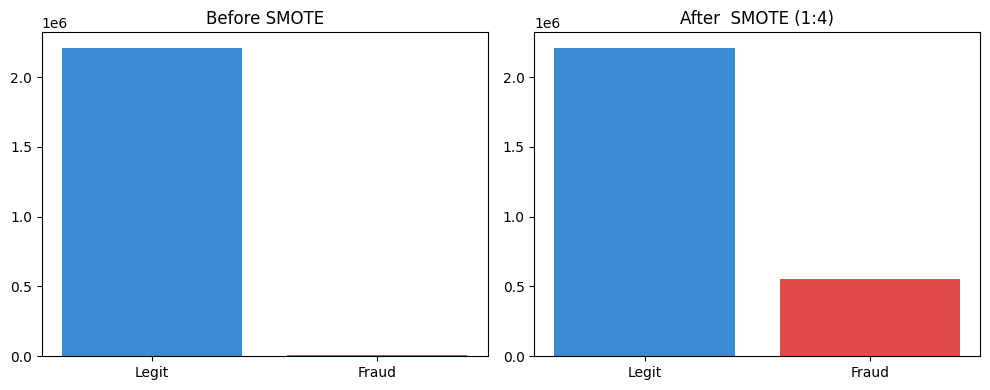

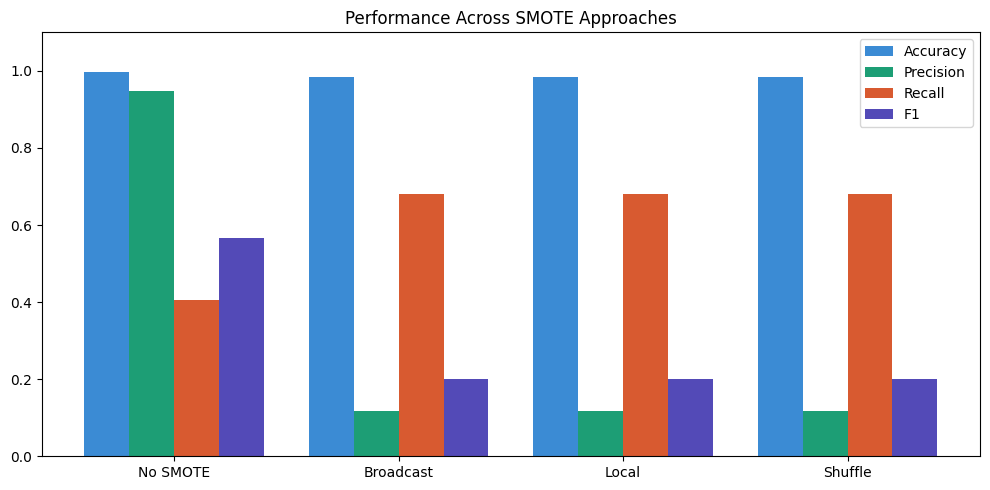

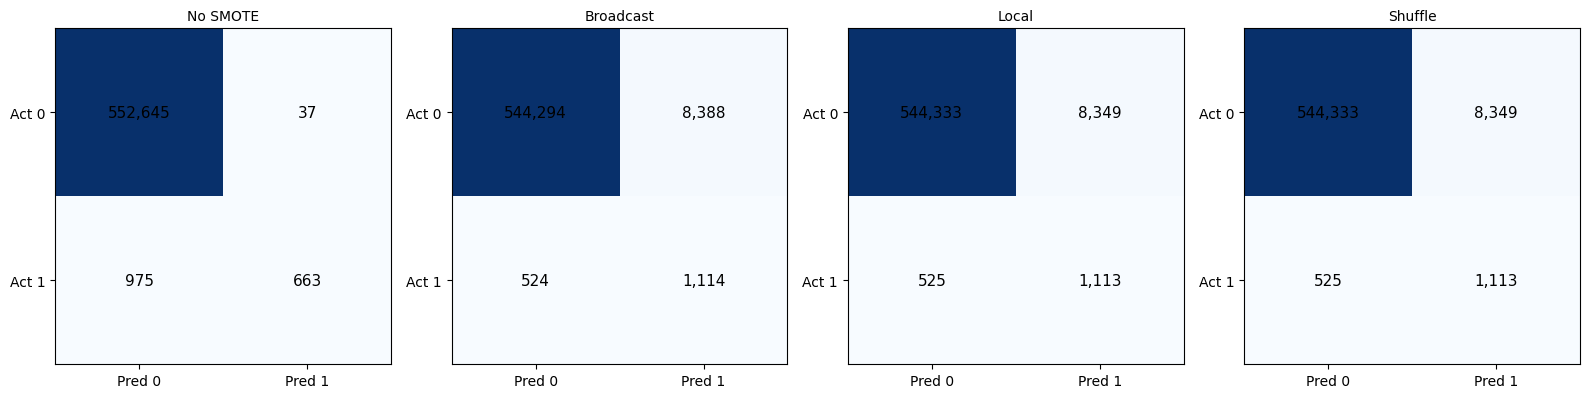

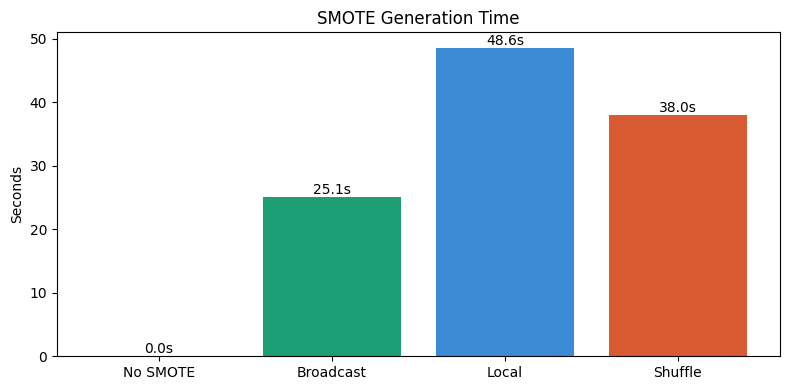

In [0]:

#author: Mohammed Tahir
import matplotlib.pyplot as plt

all_results = [baseline_results, broadcast_results, local_results, shuffle_results]
names = ['No SMOTE', 'Broadcast', 'Local', 'Shuffle']



#  class Distribution before vs after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['Legit', 'Fraud'], [majority_count, minority_count], color=['#3B8BD4', '#E24B4A'])
axes[0].set_title('Before SMOTE')

after = broadcast_df.groupBy("isFraud").count().collect()
after_dict = {r["isFraud"]: r["count"] for r in after}
axes[1].bar(['Legit', 'Fraud'], [after_dict[0], after_dict[1]], color=['#3B8BD4', '#E24B4A'])
axes[1].set_title('After  SMOTE (1:4)')
plt.tight_layout()
plt.show()



# metrics comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = range(4)
w = 0.2
for i, (m, c) in enumerate(zip(['accuracy','precision','recall','f1'], ['#3B8BD4','#1D9E75','#D85A30','#534AB7'])):
    vals = [r[m] for r in all_results]
    ax.bar([xi + i*w for xi in x], vals, w, label=m.title(), color=c)
ax.set_xticks([xi + 1.5*w for xi in x])
ax.set_xticklabels(names)
ax.set_ylim(0, 1.1)
ax.legend()
ax.set_title('Performance Across SMOTE Approaches')
plt.tight_layout()
plt.show()



# confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for idx, (name, r) in enumerate(zip(names, all_results)):
    cm = [[r["tn"], r["fp"]], [r["fn"], r["tp"]]]
    axes[idx].imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            axes[idx].text(j, i, f'{cm[i][j]:,}', ha='center', va='center', fontsize=11)
    axes[idx].set_xticks([0,1]); axes[idx].set_xticklabels(['Pred 0','Pred 1'])
    axes[idx].set_yticks([0,1]); axes[idx].set_yticklabels(['Act 0','Act 1'])
    axes[idx].set_title(name, fontsize=10)
plt.tight_layout()
plt.show()



# smote timing
fig, ax = plt.subplots(figsize=(8, 4))
smote_times = [0, broadcast_time, local_time, shuffle_time]
colors = ['#888780', '#1D9E75', '#3B8BD4', '#D85A30']
bars = ax.bar(names, smote_times, color=colors)
for bar, t in zip(bars, smote_times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{t:.1f}s', ha='center', fontsize=10)
ax.set_title('SMOTE Generation Time')
ax.set_ylabel('Seconds')
plt.tight_layout()
plt.show()



### Answering Research Question2)  performed size up ananlysis of Global Decision Tree 


## Step 20 - Scalability Experiment: Size Up Analysis
Evaluating how the Global Decision Tree scales with increasing data size. The SMOTE augmented dataset (Broadcast Global) is sampled at 10% increments from 10% to 100% and training time is measured at each fraction.

The histogram based design achieves sub linear scaling because the communication cost is bounded by the histogram dimensionality (nodes* features* bins* labels) not the input size. At the tested scale, per iteration coordination overhead dominates computation, resulting in near constant runtime 




[DT] Features with split candidates: 8
[DT] Data cached with node_id column
[DT] Iteration 1: 2 active leaves, 1 nodes
[DT] Iteration 2: 4 active leaves, 3 nodes
[DT] Iteration 3: 8 active leaves, 7 nodes
[DT] Iteration 4: 16 active leaves, 15 nodes
[DT] Iteration 5: 24 active leaves, 31 nodes
[DT] Iteration 6: 26 active leaves, 55 nodes
[DT] Iteration 7: 30 active leaves, 81 nodes
[DT] Iteration 8: 0 active leaves, 111 nodes
[DT] Training complete in 166.65s — 111 nodes
10% (276,403 rows): 166.6s
[DT] Features with split candidates: 8
[DT] Data cached with node_id column
[DT] Iteration 1: 2 active leaves, 1 nodes
[DT] Iteration 2: 4 active leaves, 3 nodes
[DT] Iteration 3: 8 active leaves, 7 nodes
[DT] Iteration 4: 16 active leaves, 15 nodes
[DT] Iteration 5: 22 active leaves, 31 nodes
[DT] Iteration 6: 30 active leaves, 53 nodes
[DT] Iteration 7: 36 active leaves, 83 nodes
[DT] Iteration 8: 0 active leaves, 119 nodes
[DT] Training complete in 135.74s — 119 nodes
20% (552,382 rows): 1

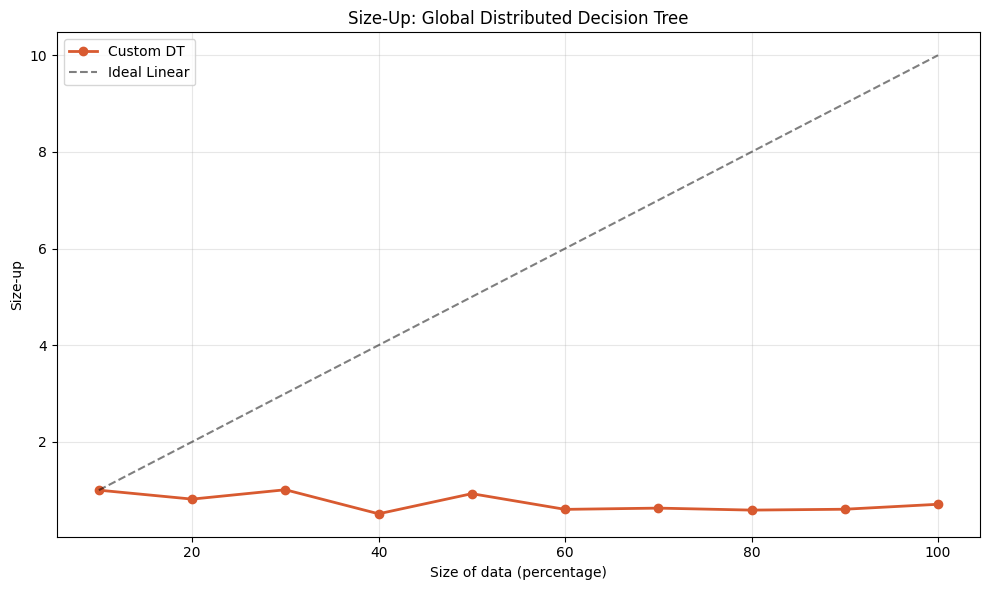

In [0]:
#author: Mohammed Tahir
fractions = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
size_up_results = []

for frac in fractions:
    sampled = broadcast_df.sample(fraction=frac, seed=42).cache()
    n_rows = sampled.count()
    
    dt = DistributedDecisionTree(max_depth=8, min_samples_split=100, n_bins=64)
    dt_time = dt.fit(sampled)
    
    size_up_results.append({"fraction": frac, "rows": n_rows, "dt_time": dt_time})
    print(f"{int(frac*100)}% ({n_rows:,} rows): {dt_time:.1f}s")
    
    sampled.unpersist()

# Size up ratio plot
baseline_time = size_up_results[0]["dt_time"]
ns = [r["fraction"] / fractions[0] for r in size_up_results]

fig, ax = plt.subplots(figsize=(10, 6))

pcts = [r["fraction"] * 100 for r in size_up_results]  #
size_ups = [r["dt_time"] / baseline_time for r in size_up_results]

ax.plot(pcts, size_ups, 'o-', label='Custom DT', linewidth=2, color='#D85A30')
ax.plot(pcts, [p / pcts[0] for p in pcts], 'k--', label='Ideal Linear', alpha=0.5)

ax.set_xlabel('Size of data (percentage)')
ax.set_ylabel('Size-up')
ax.set_title('Size-Up: Global Distributed Decision Tree')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



### Answering Research Question 3) Evaluated how Global Decision Tree accuracy changes with number of paritions 

%md

## Step 21 - Evaluation 
### Partition Count Vs Accuracy

As this is the global method it should be independent of partitions so the plot number of partitions Vs Accuracy should be constant 


[DT] Features with split candidates: 8
[DT] Data cached with node_id column
[DT] Iteration 1: 2 active leaves, 1 nodes
[DT] Iteration 2: 4 active leaves, 3 nodes
[DT] Iteration 3: 8 active leaves, 7 nodes
[DT] Iteration 4: 16 active leaves, 15 nodes
[DT] Iteration 5: 22 active leaves, 31 nodes
[DT] Iteration 6: 28 active leaves, 53 nodes
[DT] Iteration 7: 36 active leaves, 81 nodes
[DT] Iteration 8: 0 active leaves, 117 nodes
[DT] Training complete in 242.32s — 117 nodes

Broadcast p=2

Confusion Matrix:
                Predicted 0    Predicted 1
  Actual 0          544294           8388
  Actual 1             524           1114

Accuracy:  0.9839
Precision: 0.1172
Recall:    0.6801
F1 Score:  0.2000
[DT] Features with split candidates: 8
[DT] Data cached with node_id column
[DT] Iteration 1: 2 active leaves, 1 nodes
[DT] Iteration 2: 4 active leaves, 3 nodes
[DT] Iteration 3: 8 active leaves, 7 nodes
[DT] Iteration 4: 16 active leaves, 15 nodes
[DT] Iteration 5: 22 active leaves, 31 n

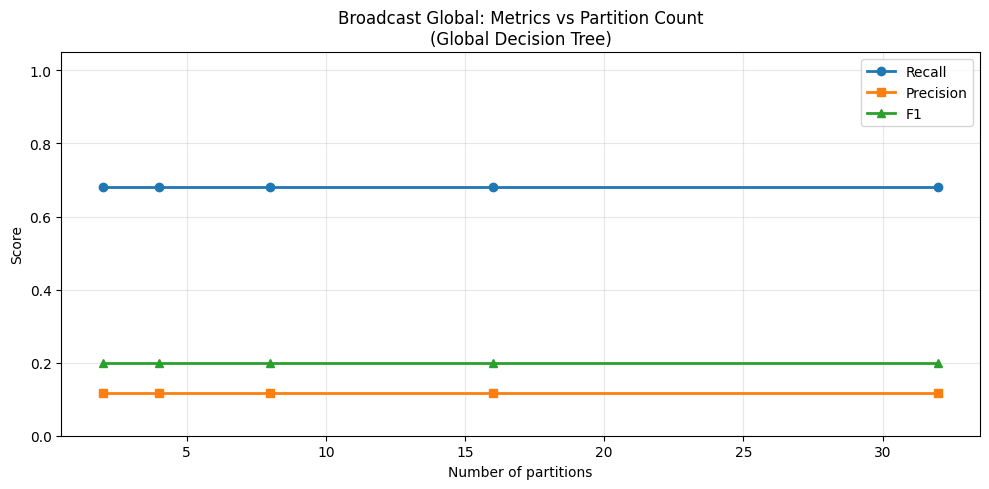

In [0]:
#author: Mohammed Tahir
partition_counts = [2, 4, 8, 16, 32]
invariance_results = []

for p in partition_counts:
    # Broadcast SMOTE 
    repart_broadcast = broadcast_df.repartition(p).cache()
    repart_broadcast.count()
    
    dt = DistributedDecisionTree(max_depth=8, min_samples_split=100, n_bins=64)
    dt.fit(repart_broadcast)
    preds = dt.predict(test_df)
    r = evaluate_predictions(preds, f"Broadcast p={p}")
    r["partitions"] = p
    r["approach"] = "Broadcast"
    invariance_results.append(r)
    repart_broadcast.unpersist()

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
bc_results = [r for r in invariance_results if r["approach"] == "Broadcast"]

ax.plot([r["partitions"] for r in bc_results],
        [r["recall"] for r in bc_results], 'o-', label='Recall', linewidth=2)
ax.plot([r["partitions"] for r in bc_results],
        [r["precision"] for r in bc_results], 's-', label='Precision', linewidth=2)
ax.plot([r["partitions"] for r in bc_results],
        [r["f1"] for r in bc_results], '^-', label='F1', linewidth=2)

ax.set_xlabel('Number of partitions')
ax.set_ylabel('Score')
ax.set_title('Broadcast Global: Metrics vs Partition Count\n(Global Decision Tree)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

# Distributed Solution of Fraud Transaction Detection Using PySpark Local GBT Classifiers 
## COMP4124 - Big Data | University of Nottingham
### Mohammed Adnan - Individual Contribution

---

**Dataset:** PaySim synthetic mobile money transactions — 6,362,620 rows, 0.13% fraud  
**Platform:** Apache Spark (PySpark) on Databricks  
**Dataset source:** Lopez-Rojas et al. (2016) — https://www.kaggle.com/datasets/ealaxi/paysim1

---

### Individual Contribution Summary

| Component | Description |
|-----------|-------------|
| Domain-informed pre-filter | Removes 3.59M noise rows - fraud only in TRANSFER and CASH_OUT |
| Feature engineering | balance_diff and dest_balance_diff capture account-emptying fraud pattern |
| Local undersampling | sampleBy() per partition - narrow transformation, zero shuffle |
| Distributed SMOTE | Custom KNN interpolation per partition - non-trivial distributed implementation |
| SMOTE ratio experiment | Tests 5x, 50x, 335x - identifies synthetic data saturation |
| Global undersampling | groupBy().count() + sampleBy() - one extra shuffle vs local |
| GBT classification | MLlib Pipeline - 10 sequential trees, each triggering one shuffle |
| Scalability experiment | Runtime and accuracy at 25/50/75/100% data size |
| Partition experiment | Runtime and accuracy across 2/4/8/16/32 partitions |

---

### Notebook Structure

| Cell | Description |
|------|-------------|
| 1 | Load dataset |
| 2 | Exploratory data analysis |
| 3 | Preprocessing and feature engineering |
| 4 | Stratified train/test split and evaluators |
| 5 | Local undersampling + GBT |
| 6 | Distributed SMOTE 5x + GBT |
| 7 | SMOTE ratio experiment |
| 8 | Global undersampling + GBT |
| 9 | Confusion matrices |
| 10 | Scalability experiment |
| 11 | Partition count experiment |
| 12 | Visualisations |
| 13 | Scalability experiment Visualisations|
| 14 | Partition count experiment visualisations |

---

## Research Questions

**RQ1:** How to implement different class imbalance techniques like undersampling, oversampling and class weights and different classification algorithms like Decision Tree , Gradient Boosting and Adaboost in distributed design for this dataset?

**RQ2:** Size up analysis of these implementations , which implementation follows linear, sub linear and super linear and why?

**RQ3:** How the accuracy changes with change in the partitions count whether the implementations folllowing ideal case or not and why?

---



## Cell 1 - Load Dataset
**Author: Mohammed Adnan**

Loads the PaySim CSV from group shared Databricks storage into a Spark DataFrame.
Spark automatically distributes the file across worker nodes as partitions.

Dataset: 6,362,620 mobile money transactions, 11 features, 0.13% fraud.

Source: Lopez-Rojas et al. (2016) — https://www.kaggle.com/datasets/ealaxi/paysim1

In [0]:
#  Cell 1: Load Dataset and Imports 
# Author: Mohammed Adnan
# Loads the PaySim synthetic financial dataset from group shared storage.


#  Standard library
import time
import random
import numpy as np

#  PySpark SQL and functions
from pyspark.sql import Row
from pyspark.sql.functions import col, round as spark_round
from pyspark.ml.linalg import Vectors

#  PySpark ML - feature engineering
from pyspark.ml.feature import StringIndexer, VectorAssembler

#  PySpark ML - classification 
from pyspark.ml.classification import GBTClassifier

#  PySpark ML - evaluation 
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator
)

#  Visualisation 
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.family":      "sans-serif"
})

#  Load dataset 
df = spark.read.csv(
    "/mnt/2026-group10/Synthetic_Financial_Data.csv",
    header=True,
    inferSchema=True
)

print(f"Total rows    : {df.count():,}")
print(f"Total columns : {len(df.columns)}")
df.printSchema()
df.show(5)

Total rows    : 6,362,620
Total columns : 11
root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- nameOrig: string (nullable = true)
 |-- oldbalanceOrg: double (nullable = true)
 |-- newbalanceOrig: double (nullable = true)
 |-- nameDest: string (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- newbalanceDest: double (nullable = true)
 |-- isFraud: integer (nullable = true)
 |-- isFlaggedFraud: integer (nullable = true)

+----+--------+--------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|step|    type|  amount|   nameOrig|oldbalanceOrg|newbalanceOrig|   nameDest|oldbalanceDest|newbalanceDest|isFraud|isFlaggedFraud|
+----+--------+--------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|   1| PAYMENT| 9839.64|C1231006815|     170136.0|     160296.36|M1979787155|           0.0|   

## Cell 2 - Exploratory Data Analysis
**Author: Mohammed Adnan**

Analyses overall class distribution and fraud occurrence by transaction type.

Key finding: fraud exclusively occurs in TRANSFER and CASH_OUT transaction types.
PAYMENT, CASH_IN and DEBIT contribute zero fraud across 3,592,211 rows.
This finding directly motivates the domain-informed pre-filter applied in Cell 3.

In [0]:
#  Cell 2: Exploratory Data Analysis 
# Author: Mohammed Adnan

total = df.count()


print("OVERALL CLASS DISTRIBUTION")

df.groupBy("isFraud") \
  .count() \
  .withColumn("percentage", spark_round((col("count") / total) * 100, 4)) \
  .orderBy("isFraud") \
  .show()


print("FRAUD COUNT BY TRANSACTION TYPE")

df.groupBy("type", "isFraud") \
  .count() \
  .orderBy("type", "isFraud") \
  .show()


print("TRANSACTION TYPE COUNTS")

df.groupBy("type") \
  .count() \
  .orderBy(col("count").desc()) \
  .show()

OVERALL CLASS DISTRIBUTION
+-------+-------+----------+
|isFraud|  count|percentage|
+-------+-------+----------+
|      0|6354407|   99.8709|
|      1|   8213|    0.1291|
+-------+-------+----------+

FRAUD COUNT BY TRANSACTION TYPE
+--------+-------+-------+
|    type|isFraud|  count|
+--------+-------+-------+
| CASH_IN|      0|1399284|
|CASH_OUT|      0|2233384|
|CASH_OUT|      1|   4116|
|   DEBIT|      0|  41432|
| PAYMENT|      0|2151495|
|TRANSFER|      0| 528812|
|TRANSFER|      1|   4097|
+--------+-------+-------+

TRANSACTION TYPE COUNTS
+--------+-------+
|    type|  count|
+--------+-------+
|CASH_OUT|2237500|
| PAYMENT|2151495|
| CASH_IN|1399284|
|TRANSFER| 532909|
|   DEBIT|  41432|
+--------+-------+



## Cell 3 - Preprocessing and Feature Engineering
**Author: Mohammed Adnan**

**Pre-filter:** Retains only TRANSFER and CASH_OUT rows - removes 3,592,211 noise rows.
Fraud rate doubles from 0.13% to 0.30%. Ensures every partition has meaningful fraud representation.

**Dropped columns:**
- nameOrig, nameDest - unique account IDs, not generalisable
- isFlaggedFraud - rule-based flag, constitutes data leakage
- step - time index, no fraud signal

**Engineered features:**
- balance_diff = oldbalanceOrg - newbalanceOrig
- dest_balance_diff = newbalanceDest - oldbalanceDest

These capture the account-emptying pattern characteristic of fraudulent transactions.

**MLlib transformers:**
- StringIndexer - encodes type column (TRANSFER/CASH_OUT) to numeric
- VectorAssembler - combines 8 feature columns into single features vector for MLlib

In [0]:
#  Cell 3: Preprocessing and Feature Engineering 
# Author: Mohammed Adnan



#  3a: Domain-informed pre-filter
# Fraud exclusively occurs in TRANSFER and CASH_OUT (confirmed in Cell 2).
# Removing PAYMENT, CASH_IN and DEBIT eliminates 3.59M noise rows and
# ensures every partition receives a meaningful fraud representation.

df_filtered    = df.filter(col("type").isin(["TRANSFER", "CASH_OUT"]))
total_filtered = df_filtered.count()
fraud_filtered = df_filtered.filter(col("isFraud") == 1).count()


print("AFTER PRE-FILTER (TRANSFER + CASH_OUT only)")

print(f"Total rows kept : {total_filtered:,}  (was 6,362,620)")
print(f"Fraud rows      : {fraud_filtered:,}  (no fraud lost)")
print(f"Fraud rate      : {(fraud_filtered/total_filtered)*100:.4f}%  (was 0.1291%)")
print(f"Rows removed    : {6362620 - total_filtered:,}")

# 3b: Drop irrelevant columns 
# nameOrig, nameDest: unique account IDs - not generalisable across accounts
# isFlaggedFraud: rule-based flag - using it would constitute data leakage
# step: time index with no predictive signal for fraud pattern

df_clean = df_filtered.drop("nameOrig", "nameDest", "isFlaggedFraud", "step")

#  3c: Feature engineering 
# Fraudulent transactions drain the source account completely.
# balance_diff and dest_balance_diff directly encode this pattern
# rather than requiring the model to infer it from raw balance columns.

df_clean = df_clean \
    .withColumn("balance_diff",
                col("oldbalanceOrg") - col("newbalanceOrig")) \
    .withColumn("dest_balance_diff",
                col("newbalanceDest") - col("oldbalanceDest"))

#  3d: Encode categorical column 
# StringIndexer converts type (TRANSFER, CASH_OUT) to numeric index.
# MLlib classifiers require numeric input — cannot accept string columns.

indexer    = StringIndexer(inputCol="type", outputCol="type_index")
df_indexed = indexer.fit(df_clean).transform(df_clean)

#  3e: Assemble feature vector 
# VectorAssembler combines all feature columns into a single dense vector.
# MLlib Pipeline requires this format as classifier input.

assembler = VectorAssembler(
    inputCols=["type_index", "amount", "oldbalanceOrg", "newbalanceOrig",
               "oldbalanceDest", "newbalanceDest",
               "balance_diff", "dest_balance_diff"],
    outputCol="features"
)
df_ready = assembler.transform(df_indexed).select("features", "isFraud")

print("\nFinal prepared DataFrame:")
df_ready.show(3)

AFTER PRE-FILTER (TRANSFER + CASH_OUT only)
Total rows kept : 2,770,409  (was 6,362,620)
Fraud rows      : 8,213  (no fraud lost)
Fraud rate      : 0.2965%  (was 0.1291%)
Rows removed    : 3,592,211

Final prepared DataFrame:
+--------------------+-------+
|            features|isFraud|
+--------------------+-------+
|(8,[0,1,2,6],[1.0...|      1|
|[0.0,181.0,181.0,...|      1|
|[0.0,229133.94,15...|      0|
+--------------------+-------+
only showing top 3 rows



## Cell 4 - Stratified Train/Test Split
**Author: Mohammed Adnan**

Splits fraud and normal classes independently (80/20) then recombines using union().
Stratified approach preserves the 0.30% fraud ratio in both train and test sets.
seed=42 used throughout ensures fully reproducible results.

- Train: 2,217,139 rows (0.2988% fraud)
- Test: 553,270 rows (0.2872% fraud)

Shared evaluators defined here and reused across all experiment cells:
F1-score, PR-AUC, Precision, Recall.
test_df cached in memory - reused across all experiments without recomputation.

In [0]:
# Cell 4: Stratified Train/Test Split
# Author: Mohammed Adnan


# Split each class independently 
fraud_df  = df_ready.filter(col("isFraud") == 1)
normal_df = df_ready.filter(col("isFraud") == 0)

train_fraud,  test_fraud  = fraud_df.randomSplit([0.8, 0.2], seed=42)
train_normal, test_normal = normal_df.randomSplit([0.8, 0.2], seed=42)

train_df = train_fraud.union(train_normal)
test_df  = test_fraud.union(test_normal)

# Cache test_df - reused across all three experiments without recomputation
test_df.cache()

#  Shared evaluators - used by all subsequent cells 
f1_eval = MulticlassClassificationEvaluator(
    labelCol="isFraud", predictionCol="prediction", metricName="f1")
auc_eval = BinaryClassificationEvaluator(
    labelCol="isFraud", rawPredictionCol="rawPrediction",
    metricName="areaUnderPR")
precision_eval = MulticlassClassificationEvaluator(
    labelCol="isFraud", predictionCol="prediction",
    metricName="weightedPrecision")
recall_eval = MulticlassClassificationEvaluator(
    labelCol="isFraud", predictionCol="prediction",
    metricName="weightedRecall")

#  Confirm split 
train_total       = train_df.count()
test_total        = test_df.count()
train_fraud_count = train_fraud.count()
test_fraud_count  = test_fraud.count()


print("TRAIN / TEST SPLIT SUMMARY")

print(f"Train total : {train_total:,}")
print(f"  Fraud     : {train_fraud_count:,}  "
      f"({train_fraud_count/train_total*100:.4f}%)")
print(f"  Normal    : {train_total - train_fraud_count:,}")
print(f"\nTest total  : {test_total:,}")
print(f"  Fraud     : {test_fraud_count:,}  "
      f"({test_fraud_count/test_total*100:.4f}%)")
print(f"  Normal    : {test_total - test_fraud_count:,}")

TRAIN / TEST SPLIT SUMMARY
Train total : 2,216,089
  Fraud     : 6,575  (0.2967%)
  Normal    : 2,209,514

Test total  : 554,320
  Fraud     : 1,638  (0.2955%)
  Normal    : 552,682


## Cell 5 - Local Undersampling + GBT
**Author: Mohammed Adnan**

**Distributed design:** sampleBy() operates per-partition without requiring a shuffle

**Sampling fraction:** total_fraud / total_normal = 0.002974
Keeps all fraud rows, reduces normal rows to match fraud count.

**Result:** 13,125 balanced rows (1:1 ratio) - 99.7% of normal rows discarded.
Serves as a fast baseline for comparison against SMOTE.

**GBT:** 10 trees built sequentially - each tree corrects residual errors of previous.
Each tree triggers one shuffle (wide transformation) - 10 trees = 10 shuffles total.


In [0]:
# Cell 5: Local Undersampling + GBT 
# Author: Mohammed Adnan


# 5a: Compute sampling fraction
# fraction = fraud_count / normal_count
# Keeps all fraud rows and reduces normal rows to match fraud count.

total_fraud_train    = train_df.filter(col("isFraud") == 1).count()
total_normal_train   = train_df.filter(col("isFraud") == 0).count()
undersample_fraction = total_fraud_train / total_normal_train


print("SAMPLING PARAMETERS")

print(f"Fraud rows in train    : {total_fraud_train:,}")
print(f"Normal rows in train   : {total_normal_train:,}")
print(f"Undersample fraction   : {undersample_fraction:.6f}")
print(f"Expected normal after  : ~{int(total_normal_train * undersample_fraction):,}")
print()

# 5b: Apply local undersampling
train_undersampled = train_df.sampleBy(
    col="isFraud",
    fractions={0: undersample_fraction, 1: 1.0},
    seed=42
)
train_undersampled.cache()

under_total  = train_undersampled.count()
under_fraud  = train_undersampled.filter(col("isFraud") == 1).count()
under_normal = train_undersampled.filter(col("isFraud") == 0).count()


print("AFTER LOCAL UNDERSAMPLING")

print(f"Total rows  : {under_total:,}  (was {train_total:,})")
print(f"Fraud rows  : {under_fraud:,}")
print(f"Normal rows : {under_normal:,}")
print(f"Fraud ratio : {under_fraud/under_total*100:.2f}%")
print()

# 5c: Train GBTClassifier 
# 10 trees built sequentially - each tree corrects residual errors
# of the previous. Each tree triggers one shuffle (wide transformation).

start_time            = time.time()
gbt                   = GBTClassifier(
    labelCol="isFraud", featuresCol="features",
    maxIter=10, maxDepth=5, seed=42)
gbt_model_local_under = gbt.fit(train_undersampled)
train_time_under      = time.time() - start_time

# 5d: Predict and evaluate
predictions_local_under = gbt_model_local_under.transform(test_df)

f1_under        = f1_eval.evaluate(predictions_local_under)
pr_auc_under    = auc_eval.evaluate(predictions_local_under)
precision_under = precision_eval.evaluate(predictions_local_under)
recall_under    = recall_eval.evaluate(predictions_local_under)


print("RESULTS — LOCAL UNDERSAMPLING + GBT")

print(f"F1-Score      : {f1_under:.4f}")
print(f"PR-AUC        : {pr_auc_under:.4f}")
print(f"Precision     : {precision_under:.4f}")
print(f"Recall        : {recall_under:.4f}")
print(f"Training time : {train_time_under:.2f}s")
print(f"Training rows : {under_total:,}")

# Store results for visualisation 
results_local_under = {
    "f1": f1_under, "pr_auc": pr_auc_under,
    "precision": precision_under, "recall": recall_under,
    "train_time": train_time_under, "train_rows": under_total
}

SAMPLING PARAMETERS
Fraud rows in train    : 6,575
Normal rows in train   : 2,209,514
Undersample fraction   : 0.002976
Expected normal after  : ~6,575

AFTER LOCAL UNDERSAMPLING
Total rows  : 13,296  (was 2,216,089)
Fraud rows  : 6,575
Normal rows : 6,721
Fraud ratio : 49.45%

RESULTS — LOCAL UNDERSAMPLING + GBT
F1-Score      : 0.9813
PR-AUC        : 0.7458
Precision     : 0.9973
Recall        : 0.9681
Training time : 267.51s
Training rows : 13,296


## Cell 6 - Distributed SMOTE + GBT
**Author: Mohammed Adnan**

**SMOTE - Synthetic Minority Over-sampling Technique** (Chawla et al., 2002)  
Generates new synthetic fraud rows via KNN interpolation.

**Distributed design:** smote_partition() runs via mapPartitions() - narrow transformation.
Each partition independently:
1. Computes Euclidean distance between fraud rows (KNN, k=3)
2. Selects K nearest neighbours per fraud row
3. Interpolates new synthetic rows between fraud row and random neighbour
Zero synthetic data crosses the network during generation.

**Parameters:** k=3 neighbours, oversample_ratio=5 (chosen based on Cell 7 experiment)




In [0]:
# Cell 6: Distributed SMOTE + GBT
# Author: Mohammed Adnan


def smote_partition(rows, k=3, oversample_ratio=5, seed=42):
    """
    Applies SMOTE within a single Spark partition (narrow transformation).
    seed parameter ensures reproducible synthetic row generation.
    """
    rows        = list(rows)
    fraud_rows  = [r for r in rows if r["isFraud"] == 1]

    if len(fraud_rows) < k + 1:
        return iter(rows)

    def row_to_array(row):
        try:
            return np.array([float(row["features"][i]) for i in range(8)])
        except:
            return None

    fraud_arrays = [row_to_array(r) for r in fraud_rows]
    fraud_arrays = [a for a in fraud_arrays if a is not None]

    if len(fraud_arrays) < k + 1:
        return iter(rows)

    # Use numpy random with seed for reproducibility
    rng            = np.random.RandomState(seed)
    synthetic_rows = []

    for i, fraud_array in enumerate(fraud_arrays):
        #Euclidean distance 
        distances = [
            (np.sqrt(np.sum((fraud_array - fraud_arrays[j]) ** 2)), j)
            for j in range(len(fraud_arrays)) if j != i
        ]
        distances.sort(key=lambda x: x[0])
        k_neighbours = [fraud_arrays[j] for _, j in distances[:k]]

        for _ in range(oversample_ratio):
            neighbour = k_neighbours[rng.randint(0, len(k_neighbours))]
            lam       = rng.random()
            synthetic = fraud_array + lam * (neighbour - fraud_array)
            synthetic_rows.append(
                Row(features=Vectors.dense(synthetic.tolist()), isFraud=1)
            )

    return iter(rows + synthetic_rows)

# 6b: Apply SMOTE per partition 
# oversample_ratio=5 generates 5 synthetic rows per real fraud row.
# Chosen based on ratio experiment (Cell 7) - higher ratios cause
# synthetic data saturation and reduce classification performance.

K_NEIGHBOURS     = 3
OVERSAMPLE_RATIO = 5

total_fraud_train  = train_df.filter(col("isFraud") == 1).count()
total_normal_train = train_df.filter(col("isFraud") == 0).count()


print("DISTRIBUTED SMOTE PARAMETERS")

print(f"Real fraud rows        : {total_fraud_train:,}")
print(f"Normal rows            : {total_normal_train:,}")
print(f"K neighbours           : {K_NEIGHBOURS}")
print(f"Oversample ratio       : {OVERSAMPLE_RATIO}x per fraud row")
print(f"Expected synthetic rows: ~{total_fraud_train * OVERSAMPLE_RATIO:,}")
print()

smote_rdd   = train_df.rdd.mapPartitions(
    lambda rows: smote_partition(rows,
                                 k=K_NEIGHBOURS,
                                 oversample_ratio=OVERSAMPLE_RATIO,
                                 seed=42)
)
train_smote = smote_rdd.toDF(train_df.schema)
train_smote.cache()

smote_total  = train_smote.count()
smote_fraud  = train_smote.filter(col("isFraud") == 1).count()
smote_normal = train_smote.filter(col("isFraud") == 0).count()


print("AFTER DISTRIBUTED SMOTE")

print(f"Total rows  : {smote_total:,}")
print(f"Fraud rows  : {smote_fraud:,}  "
      f"({smote_fraud - total_fraud_train:,} synthetic + "
      f"{total_fraud_train:,} real)")
print(f"Normal rows : {smote_normal:,}")
print(f"Fraud ratio : {smote_fraud/smote_total*100:.2f}%")
print()
# 6c: Train GBTClassifier
start_time       = time.time()
gbt              = GBTClassifier(
    labelCol="isFraud", featuresCol="features",
    maxIter=10, maxDepth=5, seed=42)
gbt_model_smote  = gbt.fit(train_smote)
train_time_smote = time.time() - start_time

# 6d: Predict and evaluate 
# Single transform call — result cached immediately
# Caching prevents recomputation of train_smote lineage on subsequent uses
predictions_smote = gbt_model_smote.transform(test_df)
predictions_smote.cache()

f1_smote        = f1_eval.evaluate(predictions_smote)
pr_auc_smote    = auc_eval.evaluate(predictions_smote)
precision_smote = precision_eval.evaluate(predictions_smote)
recall_smote    = recall_eval.evaluate(predictions_smote)

print("RESULTS - DISTRIBUTED SMOTE 5x + GBT")
print(f"F1-Score      : {f1_smote:.4f}")
print(f"PR-AUC        : {pr_auc_smote:.4f}")
print(f"Precision     : {precision_smote:.4f}")
print(f"Recall        : {recall_smote:.4f}")
print(f"Training time : {train_time_smote:.2f}s")
print(f"Training rows : {smote_total:,}")
print(f"Synthetic rows: {smote_fraud - total_fraud_train:,}")


# Store results for visualisation
results_smote_5x = {
    "f1": f1_smote, "pr_auc": pr_auc_smote,
    "precision": precision_smote, "recall": recall_smote,
    "train_time": train_time_smote, "train_rows": smote_total,
    "synthetic_rows": smote_fraud - total_fraud_train
}

DISTRIBUTED SMOTE PARAMETERS
Real fraud rows        : 6,575
Normal rows            : 2,209,514
K neighbours           : 3
Oversample ratio       : 5x per fraud row
Expected synthetic rows: ~32,875

AFTER DISTRIBUTED SMOTE
Total rows  : 2,248,964
Fraud rows  : 39,450  (32,875 synthetic + 6,575 real)
Normal rows : 2,209,514
Fraud ratio : 1.75%

RESULTS - DISTRIBUTED SMOTE 5x + GBT
F1-Score      : 0.9987
PR-AUC        : 0.8244
Precision     : 0.9987
Recall        : 0.9987
Training time : 81.40s
Training rows : 2,248,964
Synthetic rows: 32,875


## Cell 7 - SMOTE Ratio Experiment
**Author: Mohammed Adnan**

Investigates the effect of SMOTE oversampling ratio on classification performance.
Tests ratios 5x (1.75% fraud), 50x (13.17% fraud) and 335x (49.98% - full balance).

**Research finding:** Full class balance (335x) produces the worst results (F1=0.9809).
Performance peaks at 5x ratio (F1=0.9987) and degrades as ratio increases.

**Explanation - synthetic data saturation:**
At 335x, each of 6,573 real fraud rows generates 335 synthetic neighbours.
With only k=3 real neighbours available, synthetic points cluster tightly
around original fraud examples. GBT learns a constrained fraud boundary
that fails to generalise to real test fraud outside this tight cluster.

In [0]:
# Cell 7: SMOTE Ratio Experiment
# Author: Mohammed Adnan


# smote_partition reused from Cell 6 
# The smote_partition function defined in Cell 6 is available in this

ratios        = [5, 50, 335]
smote_results = []

for ratio in ratios:
    
    print(f"SMOTE oversample_ratio = {ratio}x")
    

    smote_rdd   = train_df.rdd.mapPartitions(
        lambda rows, r=ratio: smote_partition(rows, k=3, oversample_ratio=r, seed=42)
    )
    train_smote = smote_rdd.toDF(train_df.schema)
    train_smote.cache()

    smote_total  = train_smote.count()
    smote_fraud  = train_smote.filter(col("isFraud") == 1).count()
    smote_normal = train_smote.filter(col("isFraud") == 0).count()

    print(f"Total rows  : {smote_total:,}")
    print(f"Fraud rows  : {smote_fraud:,}")
    print(f"Normal rows : {smote_normal:,}")
    print(f"Fraud ratio : {smote_fraud/smote_total*100:.2f}%")
    print()

    start      = time.time()
    gbt        = GBTClassifier(
        labelCol="isFraud", featuresCol="features",
        maxIter=10, maxDepth=5, seed=42)
    model      = gbt.fit(train_smote)
    train_time = time.time() - start

    preds  = model.transform(test_df)
    f1     = f1_eval.evaluate(preds)
    pr_auc = auc_eval.evaluate(preds)
    recall = recall_eval.evaluate(preds)

    print(f"Training time : {train_time:.2f}s")
    print(f"F1-Score      : {f1:.4f}")
    print(f"PR-AUC        : {pr_auc:.4f}")
    print(f"Recall        : {recall:.4f}")
    print()

    smote_results.append({
        "ratio"     : ratio,
        "total_rows": smote_total,
        "fraud_rows": smote_fraud,
        "fraud_pct" : round(smote_fraud/smote_total*100, 2),
        "train_time": round(train_time, 2),
        "f1"        : round(f1, 4),
        "pr_auc"    : round(pr_auc, 4),
        "recall"    : round(recall, 4)
    })

    train_smote.unpersist()


print("SMOTE RATIO COMPARISON")

print(f"{'Ratio':>7} {'Total rows':>12} {'Fraud rows':>12} "
      f"{'Fraud%':>8} {'Time(s)':>9} {'F1':>7} {'PR-AUC':>8} {'Recall':>8}")
print("-" * 78)
for r in smote_results:
    print(f"{r['ratio']:>6}x {r['total_rows']:>12,} {r['fraud_rows']:>12,} "
          f"{r['fraud_pct']:>7.2f}% {r['train_time']:>9.2f} "
          f"{r['f1']:>7.4f} {r['pr_auc']:>8.4f} {r['recall']:>8.4f}")
    
    # Store ratio experiment results for visualisation 
# smote_results list already exists from the loop
# just confirm it is stored
print(f"Ratio experiment stored: {len(smote_results)} results")

SMOTE oversample_ratio = 5x
Total rows  : 2,248,964
Fraud rows  : 39,450
Normal rows : 2,209,514
Fraud ratio : 1.75%

Training time : 71.37s
F1-Score      : 0.9987
PR-AUC        : 0.8245
Recall        : 0.9987

SMOTE oversample_ratio = 50x
Total rows  : 2,544,839
Fraud rows  : 335,325
Normal rows : 2,209,514
Fraud ratio : 13.18%

Training time : 60.15s
F1-Score      : 0.9953
PR-AUC        : 0.8378
Recall        : 0.9937

SMOTE oversample_ratio = 335x
Total rows  : 4,418,714
Fraud rows  : 2,209,200
Normal rows : 2,209,514
Fraud ratio : 50.00%

Training time : 78.85s
F1-Score      : 0.9797
PR-AUC        : 0.7748
Recall        : 0.9651

SMOTE RATIO COMPARISON
  Ratio   Total rows   Fraud rows   Fraud%   Time(s)      F1   PR-AUC   Recall
------------------------------------------------------------------------------
     5x    2,248,964       39,450    1.75%     71.37  0.9987   0.8245   0.9987
    50x    2,544,839      335,325   13.18%     60.15  0.9953   0.8378   0.9937
   335x    4,418,71

## Cell 8 - Global Undersampling + GBT
**Author: Mohammed Adnan**

**Distributed design contrast with Cell 5 (local undersampling):**

Local undersampling (Cell 5):
- sampleBy() applies fraction per partition independently
- Zero shuffles before training
- Approximate per-partition class ratio

Global undersampling (Cell 8):
- groupBy().count() first - wide transformation, one shuffle, 12.26s overhead
- Exact cluster-wide class ratio computed and broadcast to all partitions
- sampleBy() then applies ratio - narrow transformation

**Finding:** Both approaches produce identical classification performance
(F1=0.9814, Recall=0.9682), confirming the extra shuffle cost of global
sampling provides no accuracy benefit. Local sampling is preferred.

In [0]:
# Cell 8: Global Undersampling + GBT
# Author: Mohammed Adnan


# 8a: Global count - wide transformation
# groupBy().count() aggregates across all partitions - data crosses network.
# Overhead recorded separately to quantify the cost of global vs local.

start_global    = time.time()
counts          = train_df.groupBy("isFraud").count().collect()
total_fraud_g   = [r["count"] for r in counts if r["isFraud"] == 1][0]
total_normal_g  = [r["count"] for r in counts if r["isFraud"] == 0][0]
global_fraction = total_fraud_g / total_normal_g
shuffle_time    = time.time() - start_global


print("GLOBAL UNDERSAMPLING PARAMETERS")

print(f"Global fraud count  : {total_fraud_g:,}")
print(f"Global normal count : {total_normal_g:,}")
print(f"Global fraction     : {global_fraction:.6f}")
print(f"Shuffle overhead    : {shuffle_time:.2f}s")
print()

# 8b: Apply global ratio - narrow transformation 
# sampleBy applies the globally computed fraction per partition.
# Unlike local sampling, all partitions use the identical ratio.

train_global_under = train_df.sampleBy(
    col="isFraud",
    fractions={0: global_fraction, 1: 1.0},
    seed=42
)
train_global_under.cache()

g_total  = train_global_under.count()
g_fraud  = train_global_under.filter(col("isFraud") == 1).count()
g_normal = train_global_under.filter(col("isFraud") == 0).count()


print("AFTER GLOBAL UNDERSAMPLING")

print(f"Total rows  : {g_total:,}")
print(f"Fraud rows  : {g_fraud:,}")
print(f"Normal rows : {g_normal:,}")
print(f"Fraud ratio : {g_fraud/g_total*100:.2f}%")
print()

# 8c: Train GBTClassifier
start_time        = time.time()
gbt               = GBTClassifier(
    labelCol="isFraud", featuresCol="features",
    maxIter=10, maxDepth=5, seed=42)
gbt_model_global  = gbt.fit(train_global_under)
train_time_global = time.time() - start_time
total_time_global = shuffle_time + train_time_global

# 8d: Predict and evaluate
predictions_global = gbt_model_global.transform(test_df)

f1_g        = f1_eval.evaluate(predictions_global)
pr_auc_g    = auc_eval.evaluate(predictions_global)
precision_g = precision_eval.evaluate(predictions_global)
recall_g    = recall_eval.evaluate(predictions_global)


print("RESULTS — GLOBAL UNDERSAMPLING + GBT")

print(f"F1-Score      : {f1_g:.4f}")
print(f"PR-AUC        : {pr_auc_g:.4f}")
print(f"Precision     : {precision_g:.4f}")
print(f"Recall        : {recall_g:.4f}")
print(f"GBT time      : {train_time_global:.2f}s")
print(f"Shuffle time  : {shuffle_time:.2f}s")
print(f"Total time    : {total_time_global:.2f}s")
print(f"Training rows : {g_total:,}")

# Store results for visualisation 
results_global_under = {
    "f1": f1_g, "pr_auc": pr_auc_g,
    "precision": precision_g, "recall": recall_g,
    "train_time": total_time_global, "train_rows": g_total,
    "shuffle_time": shuffle_time
}

GLOBAL UNDERSAMPLING PARAMETERS
Global fraud count  : 6,575
Global normal count : 2,209,514
Global fraction     : 0.002976
Shuffle overhead    : 8.92s

AFTER GLOBAL UNDERSAMPLING
Total rows  : 13,296
Fraud rows  : 6,575
Normal rows : 6,721
Fraud ratio : 49.45%

RESULTS — GLOBAL UNDERSAMPLING + GBT
F1-Score      : 0.9813
PR-AUC        : 0.7501
Precision     : 0.9973
Recall        : 0.9681
GBT time      : 42.35s
Shuffle time  : 8.92s
Total time    : 51.27s
Training rows : 13,296


## Cell 9 - Confusion Matrices
**Author: Mohammed Adnan**

Evaluates all three final strategies using confusion matrices.

Primary metric: **FN (Fraud Missed)** - the most costly error in fraud detection.
A missed fraud case represents an undetected criminal transaction.


In [0]:
# Cell 9: Confusion Matrices
# Author: Mohammed Adnan


def print_confusion_matrix(predictions, method_name):
    """
    Computes and prints a confusion matrix from a predictions DataFrame.

    TP — fraud correctly identified
    TN — normal correctly identified
    FP — normal incorrectly flagged as fraud (false alarm)
    FN — fraud missed (most costly error)
    """
    cm      = predictions.groupBy("isFraud", "prediction").count().collect()
    cm_dict = {(int(r["isFraud"]), int(r["prediction"])): r["count"]
               for r in cm}

    TP = cm_dict.get((1, 1), 0)
    TN = cm_dict.get((0, 0), 0)
    FP = cm_dict.get((0, 1), 0)
    FN = cm_dict.get((1, 0), 0)

    total_fraud  = TP + FN
    total_normal = TN + FP

    print(f"\n{'-'*52}")
    print(f"CONFUSION MATRIX - {method_name}")
    print(f"{'-'*52}")
    print(f"{'':20} {'Pred Normal':>14}  {'Pred Fraud':>12}")
    print(f"{'Actual Normal':20} {TN:>14,}  {FP:>12,}")
    print(f"{'Actual Fraud':20} {FN:>14,}  {TP:>12,}")
    print(f"\nFraud caught (TP) : {TP:,} / {total_fraud:,} "
          f"({TP/total_fraud*100:.2f}%)")
    print(f"Fraud missed (FN) : {FN:,} / {total_fraud:,} "
          f"({FN/total_fraud*100:.2f}%)")
    print(f"False alarms (FP) : {FP:,} / {total_normal:,} "
          f"({FP/total_normal*100:.4f}%)")

    return {"TP": TP, "TN": TN, "FP": FP, "FN": FN}

# Use cached predictions directly from Cells 5, 6 and 8 
cm_local_under = print_confusion_matrix(
    predictions_local_under, "LOCAL UNDERSAMPLING + GBT")

cm_smote       = print_confusion_matrix(
    predictions_smote,       "DISTRIBUTED SMOTE 5x + GBT")

cm_global      = print_confusion_matrix(
    predictions_global,      "GLOBAL UNDERSAMPLING + GBT")


----------------------------------------------------
CONFUSION MATRIX - LOCAL UNDERSAMPLING + GBT
----------------------------------------------------
                        Pred Normal    Pred Fraud
Actual Normal               535,012        17,670
Actual Fraud                     10         1,628

Fraud caught (TP) : 1,628 / 1,638 (99.39%)
Fraud missed (FN) : 10 / 1,638 (0.61%)
False alarms (FP) : 17,670 / 552,682 (3.1971%)

----------------------------------------------------
CONFUSION MATRIX - DISTRIBUTED SMOTE 5x + GBT
----------------------------------------------------
                        Pred Normal    Pred Fraud
Actual Normal               552,375           307
Actual Fraud                    386         1,252

Fraud caught (TP) : 1,252 / 1,638 (76.43%)
Fraud missed (FN) : 386 / 1,638 (23.57%)
False alarms (FP) : 307 / 552,682 (0.0555%)

----------------------------------------------------
CONFUSION MATRIX - GLOBAL UNDERSAMPLING + GBT
------------------------------------

## Cell 10 - Scalability Experiment
**Author: Mohammed Adnan**

Runs the local undersampling + GBT pipeline at 25%, 50%, 75% and 100%
of training data. Measures runtime and classification performance at each scale.

**Addresses RQ2:** How does GBT scale with increasing data size?

**Stratified subsampling** preserves the fraud ratio at each scale.
Same test set used across all runs for comparable evaluation.

In [0]:
# Cell 10: Scalability Experiment
# Author: Mohammed Adnan


fractions           = [0.25, 0.50, 0.75, 1.00]
scalability_results = []

for frac in fractions:
    print(f"EXPERIMENT: {int(frac*100)}% of training data")

    if frac < 1.0:
        fraud_sample  = train_df.filter(col("isFraud") == 1).sample(
                            fraction=frac, seed=42)
        normal_sample = train_df.filter(col("isFraud") == 0).sample(
                            fraction=frac, seed=42)
        train_subset  = fraud_sample.union(normal_sample)
    else:
        train_subset = train_df

    subset_total = train_subset.count()
    subset_fraud = train_subset.filter(col("isFraud") == 1).count()
    print(f"Subset size : {subset_total:,} rows")
    print(f"Fraud rows  : {subset_fraud:,}")

    fraud_count  = subset_fraud
    normal_count = train_subset.filter(col("isFraud") == 0).count()
    under_frac   = fraud_count / normal_count

    train_balanced = train_subset.sampleBy(
        col="isFraud",
        fractions={0: under_frac, 1: 1.0},
        seed=42
    )
    train_balanced.cache()
    balanced_total = train_balanced.count()
    print(f"After undersampling : {balanced_total:,} rows")

    start      = time.time()
    gbt        = GBTClassifier(
        labelCol="isFraud", featuresCol="features",
        maxIter=10, maxDepth=5, seed=42)
    model      = gbt.fit(train_balanced)
    train_time = time.time() - start

    preds  = model.transform(test_df)
    f1     = f1_eval.evaluate(preds)
    pr_auc = auc_eval.evaluate(preds)
    recall = recall_eval.evaluate(preds)

    print(f"Training time : {train_time:.2f}s")
    print(f"F1-Score      : {f1:.4f}")
    print(f"PR-AUC        : {pr_auc:.4f}")
    print(f"Recall        : {recall:.4f}")

    scalability_results.append({
        "fraction"     : int(frac * 100),
        "train_rows"   : subset_total,
        "balanced_rows": balanced_total,
        "train_time"   : round(train_time, 2),
        "f1"           : round(f1, 4),
        "pr_auc"       : round(pr_auc, 4),
        "recall"       : round(recall, 4)
    })

    train_balanced.unpersist()

print("\nSCALABILITY RESULTS SUMMARY")
print(f"{'Size%':>6} {'Train rows':>12} {'Balanced':>10} "
      f"{'Time(s)':>9} {'F1':>7} {'PR-AUC':>8} {'Recall':>8}")
for r in scalability_results:
    print(f"{r['fraction']:>5}% {r['train_rows']:>12,} "
          f"{r['balanced_rows']:>10,} {r['train_time']:>9.2f} "
          f"{r['f1']:>7.4f} {r['pr_auc']:>8.4f} {r['recall']:>8.4f}")

print(f"\nScalability results stored: {len(scalability_results)} experiments")

EXPERIMENT: 25% of training data
Subset size : 554,227 rows
Fraud rows  : 1,640
After undersampling : 3,340 rows
Training time : 75.92s
F1-Score      : 0.9780
PR-AUC        : 0.7493
Recall        : 0.9619
EXPERIMENT: 50% of training data
Subset size : 1,108,876 rows
Fraud rows  : 3,290
After undersampling : 6,670 rows
Training time : 27.65s
F1-Score      : 0.9784
PR-AUC        : 0.4885
Recall        : 0.9626
EXPERIMENT: 75% of training data
Subset size : 1,662,616 rows
Fraud rows  : 4,973
After undersampling : 10,026 rows
Training time : 32.35s
F1-Score      : 0.9818
PR-AUC        : 0.6501
Recall        : 0.9691
EXPERIMENT: 100% of training data
Subset size : 2,216,089 rows
Fraud rows  : 6,575
After undersampling : 13,296 rows
Training time : 37.15s
F1-Score      : 0.9813
PR-AUC        : 0.7440
Recall        : 0.9681

SCALABILITY RESULTS SUMMARY
 Size%   Train rows   Balanced   Time(s)      F1   PR-AUC   Recall
   25%      554,227      3,340     75.92  0.9780   0.7493   0.9619
   50%  

## Cell 11 - Partition Count Experiment
**Author: Mohammed Adnan**

Investigates the effect of Spark partition count on GBT training time
and classification performance. Tests 2, 4, 8, 16 and 32 partitions.

**Addresses RQ3:** Does runtime exhibit linear or non-linear scaling with partition count?

**repartition(n)** triggers a shuffle to redistribute balanced training rows
evenly across n partitions before GBT training begins.

In [0]:
# Cell 11: Partition Count Experiment 
# Author: Mohammed Adnan

# Apply local undersampling on full training set 
total_fraud_train  = train_df.filter(col("isFraud") == 1).count()
total_normal_train = train_df.filter(col("isFraud") == 0).count()
undersample_frac   = total_fraud_train / total_normal_train

train_undersampled_base = train_df.sampleBy(
    col="isFraud",
    fractions={0: undersample_frac, 1: 1.0},
    seed=42
)

partition_counts  = [2, 4, 8, 16, 32]
partition_results = []

for n_partitions in partition_counts:
    print(f"EXPERIMENT: {n_partitions} partitions")

    train_part = train_undersampled_base.repartition(n_partitions)
    train_part.cache()

    total = train_part.count()
    print(f"Total rows         : {total:,}")
    print(f"Rows per partition : ~{total // n_partitions:,}")

    start      = time.time()
    gbt        = GBTClassifier(
        labelCol="isFraud", featuresCol="features",
        maxIter=10, maxDepth=5, seed=42)
    model      = gbt.fit(train_part)
    train_time = time.time() - start

    preds  = model.transform(test_df)
    f1     = f1_eval.evaluate(preds)
    pr_auc = auc_eval.evaluate(preds)
    recall = recall_eval.evaluate(preds)

    print(f"Training time : {train_time:.2f}s")
    print(f"F1-Score      : {f1:.4f}")
    print(f"PR-AUC        : {pr_auc:.4f}")
    print(f"Recall        : {recall:.4f}")
    print()

    partition_results.append({
        "partitions": n_partitions,
        "total_rows": total,
        "rows_per_part": total // n_partitions,
        "train_time": round(train_time, 2),
        "f1"        : round(f1, 4),
        "pr_auc"    : round(pr_auc, 4),
        "recall"    : round(recall, 4)
    })

    train_part.unpersist()

print("PARTITION COUNT RESULTS SUMMARY")
print(f"{'Partitions':>12} {'Rows/Part':>10} {'Time(s)':>9} "
      f"{'F1':>7} {'PR-AUC':>8} {'Recall':>8}")
print("-" * 65)
for r in partition_results:
    print(f"{r['partitions']:>12} "
          f"{r['rows_per_part']:>10,} "
          f"{r['train_time']:>9.2f} "
          f"{r['f1']:>7.4f} "
          f"{r['pr_auc']:>8.4f} "
          f"{r['recall']:>8.4f}")

print(f"\nPartition results stored: {len(partition_results)} experiments")

EXPERIMENT: 2 partitions
Total rows         : 13,296
Rows per partition : ~6,648
Training time : 17.31s
F1-Score      : 0.9805
PR-AUC        : 0.7254
Recall        : 0.9666

EXPERIMENT: 4 partitions
Total rows         : 13,296
Rows per partition : ~3,324
Training time : 21.35s
F1-Score      : 0.9806
PR-AUC        : 0.7731
Recall        : 0.9667

EXPERIMENT: 8 partitions
Total rows         : 13,296
Rows per partition : ~1,662
Training time : 16.85s
F1-Score      : 0.9772
PR-AUC        : 0.6870
Recall        : 0.9603

EXPERIMENT: 16 partitions
Total rows         : 13,296
Rows per partition : ~831
Training time : 35.80s
F1-Score      : 0.9814
PR-AUC        : 0.6797
Recall        : 0.9684

EXPERIMENT: 32 partitions
Total rows         : 13,296
Rows per partition : ~415
Training time : 28.86s
F1-Score      : 0.9823
PR-AUC        : 0.6850
Recall        : 0.9700

PARTITION COUNT RESULTS SUMMARY
  Partitions  Rows/Part   Time(s)      F1   PR-AUC   Recall
----------------------------------------

## Cell 12 - Visualisations
**Author: Mohammed Adnan**

Generates five figures:

- **Figure 1:** F1-Score and PR-AUC across all five resampling strategies
- **Figure 2:** Training time per strategy (log scale) - highlights 1,523x difference
- **Figure 3:** Confusion matrices for three final strategies
- **Figure 4:** SMOTE ratio experiment - F1, PR-AUC, Recall and training set size
- **Figure 5:** Scalability experiment - runtime, performance and balanced set size

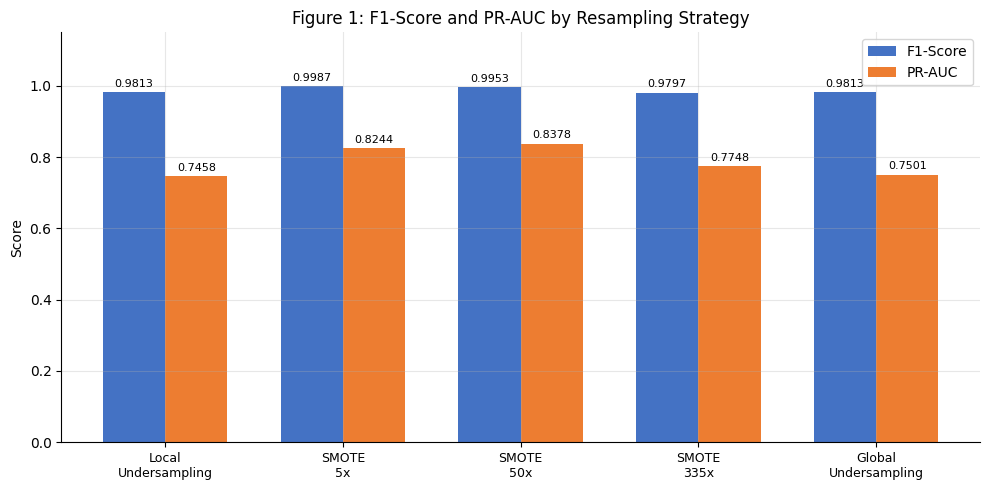

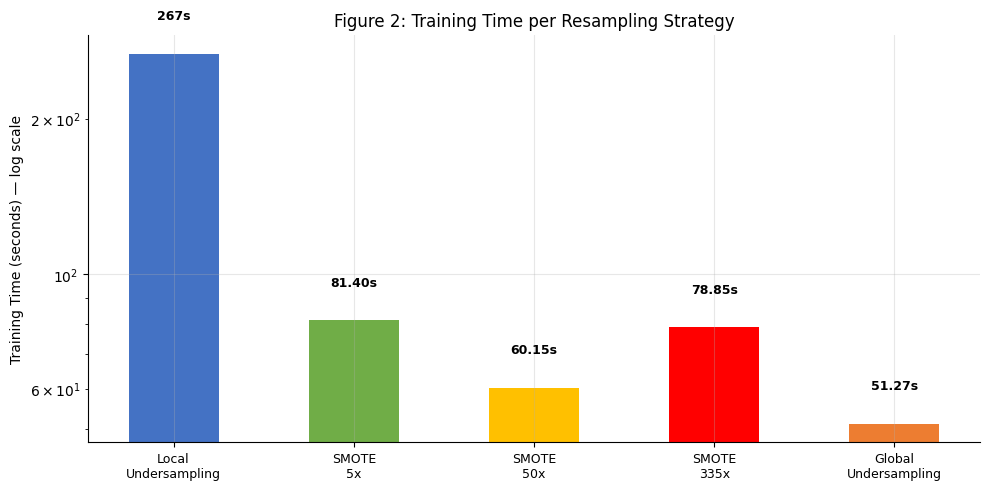

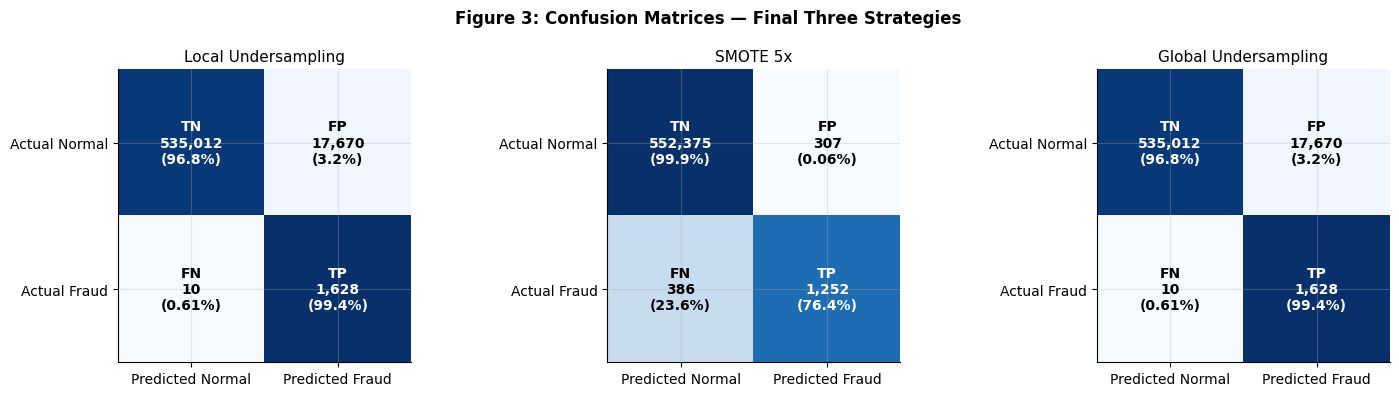

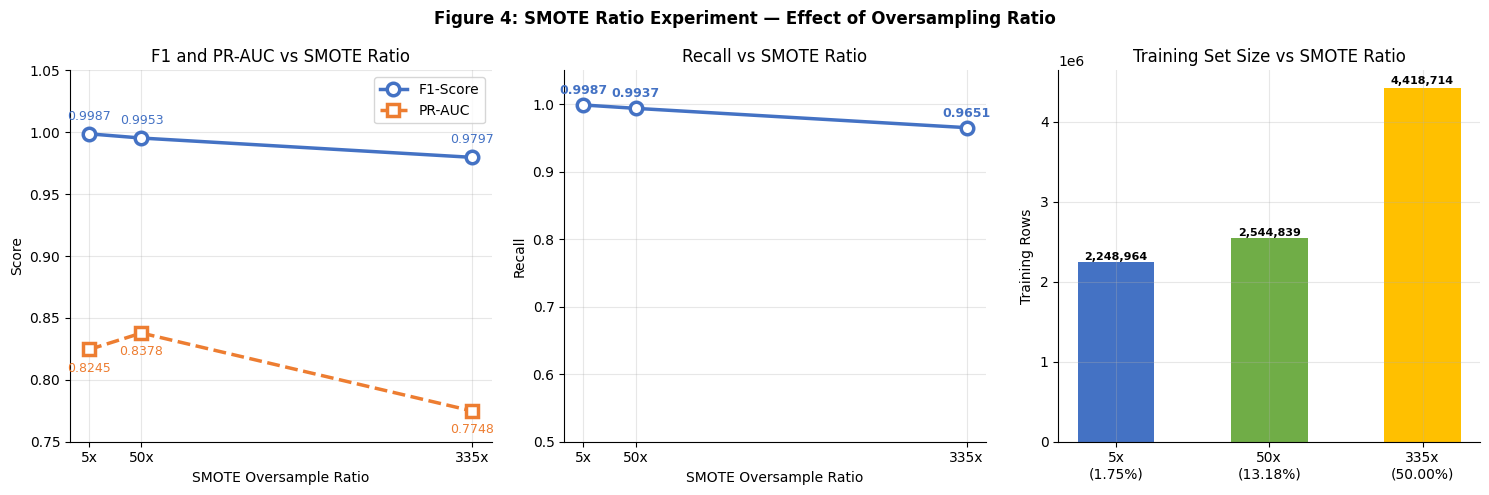

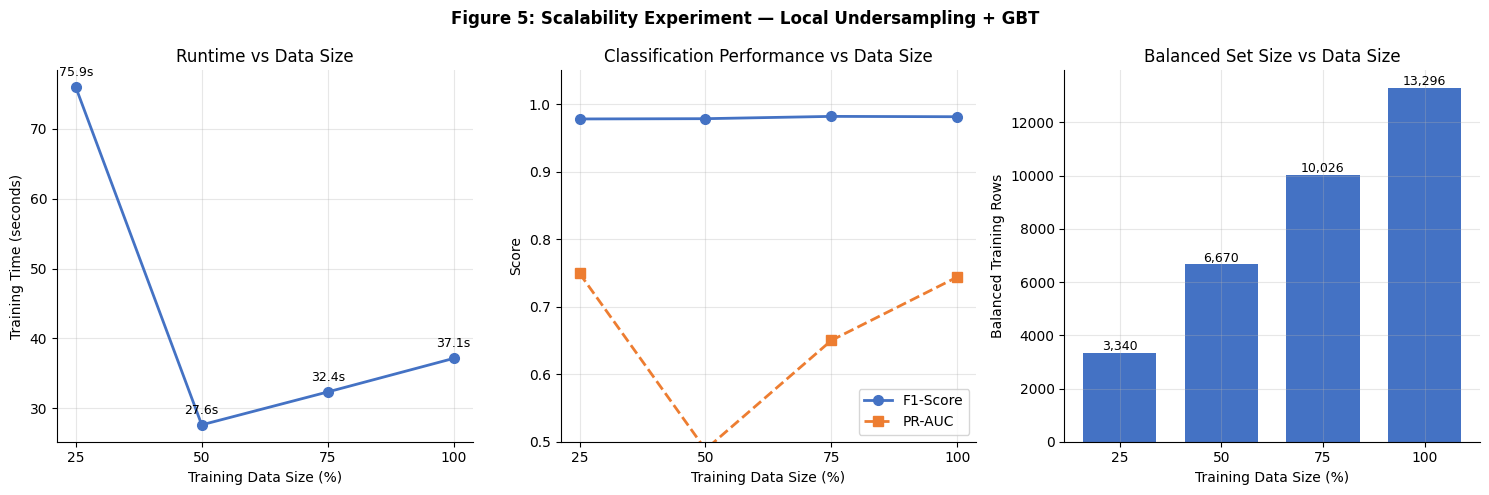

In [0]:
# Cell 12: Visualisations
# Author: Mohammed Adnan


BLUE   = "#4472C4"
ORANGE = "#ED7D31"
COLORS = ["#4472C4", "#70AD47", "#FFC000", "#FF0000", "#ED7D31"]

# Build data from stored results 
methods     = ["Local\nUndersampling", "SMOTE\n5x",
               "SMOTE\n50x", "SMOTE\n335x", "Global\nUndersampling"]

f1_scores   = [
    results_local_under["f1"],
    results_smote_5x["f1"],
    smote_results[1]["f1"],    # 50x from ratio experiment
    smote_results[2]["f1"],    # 335x from ratio experiment
    results_global_under["f1"]
]
pr_auc_vals = [
    results_local_under["pr_auc"],  
    results_smote_5x["pr_auc"],
    smote_results[1]["pr_auc"],
    smote_results[2]["pr_auc"],
    results_global_under["pr_auc"]
]
train_times = [
    results_local_under["train_time"],
    results_smote_5x["train_time"],
    smote_results[1]["train_time"],
    smote_results[2]["train_time"],
    results_global_under["train_time"]
]
train_rows  = [
    results_local_under["train_rows"],
    results_smote_5x["train_rows"],
    smote_results[1]["total_rows"],
    smote_results[2]["total_rows"],
    results_global_under["train_rows"]
]

# SMOTE ratio experiment data from Cell 7 
ratios       = [r["ratio"]      for r in smote_results]
smote_f1     = [r["f1"]         for r in smote_results]
smote_prauc  = [r["pr_auc"]     for r in smote_results]
smote_recall = [r["recall"]     for r in smote_results]
smote_rows   = [r["total_rows"] for r in smote_results]
smote_pct    = [r["fraud_pct"]  for r in smote_results]

# Scalability data from Cell 11 
sizes        = [r["fraction"]      for r in scalability_results]
scale_times  = [r["train_time"]    for r in scalability_results]
scale_f1     = [r["f1"]            for r in scalability_results]
scale_prauc  = [r["pr_auc"]        for r in scalability_results]
scale_rows   = [r["balanced_rows"] for r in scalability_results]

x, width = np.arange(len(methods)), 0.35

# Figure 1: F1 and PR-AUC
fig, ax = plt.subplots(figsize=(10, 5))
bars1   = ax.bar(x - width/2, f1_scores,   width, label="F1-Score", color=BLUE)
bars2   = ax.bar(x + width/2, pr_auc_vals, width, label="PR-AUC",   color=ORANGE)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Figure 1: F1-Score and PR-AUC by Resampling Strategy")
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=9)
ax.legend()
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()
print()

# Figure 2: Training time (log scale)
fig, ax = plt.subplots(figsize=(10, 5))
bars    = ax.bar(methods, train_times, color=COLORS, width=0.5)
ax.set_yscale("log")
ax.set_ylabel("Training Time (seconds) — log scale")
ax.set_title("Figure 2: Training Time per Resampling Strategy")
ax.set_xticks(np.arange(len(methods)))
ax.set_xticklabels(methods, fontsize=9)
for bar, t in zip(bars, train_times):
    label = f"{int(t)}s" if t > 100 else f"{t:.2f}s"
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.15,
            label, ha="center", va="bottom", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.show()
print()

# Figure 3: Confusion matrices 
# Values from Cell 9 confusion matrix results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Figure 3: Confusion Matrices — Final Three Strategies",
             fontsize=12, fontweight="bold")
cms = [
    {"matrix": [[cm_local_under["TN"], cm_local_under["FP"]],
                [cm_local_under["FN"], cm_local_under["TP"]]],
     "title": "Local Undersampling"},
    {"matrix": [[cm_smote["TN"],       cm_smote["FP"]],
                [cm_smote["FN"],       cm_smote["TP"]]],
     "title": "SMOTE 5x"},
    {"matrix": [[cm_global["TN"],      cm_global["FP"]],
                [cm_global["FN"],      cm_global["TP"]]],
     "title": "Global Undersampling"},
]
for ax, cm_data in zip(axes, cms):
    matrix      = np.array(cm_data["matrix"])
    matrix_norm = matrix.astype(float)
    matrix_norm[0] = matrix_norm[0] / matrix_norm[0].sum()
    matrix_norm[1] = matrix_norm[1] / matrix_norm[1].sum()
    ax.imshow(matrix_norm, cmap="Blues", vmin=0, vmax=1)
    labels = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            val = matrix[i][j]
            pct = matrix_norm[i][j] * 100
            tc  = "white" if matrix_norm[i][j] > 0.5 else "black"
            pct_str = f"{pct:.2f}%" if pct < 1.0 else f"{pct:.1f}%"
            ax.text(j, i, f"{labels[i][j]}\n{val:,}\n({pct_str})",
                    ha="center", va="center", fontsize=10,
                    fontweight="bold", color=tc)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Predicted Normal", "Predicted Fraud"])
    ax.set_yticklabels(["Actual Normal", "Actual Fraud"])
    ax.set_title(cm_data["title"], fontsize=11)
plt.tight_layout()
plt.show()
print()

# Figure 4: SMOTE ratio experiment 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Figure 4: SMOTE Ratio Experiment — Effect of Oversampling Ratio",
             fontsize=12, fontweight="bold")

axes[0].plot(ratios, smote_f1, "o-", color=BLUE,
             linewidth=2.5, markersize=9,
             markerfacecolor="white", markeredgewidth=2.5, label="F1-Score")
axes[0].plot(ratios, smote_prauc, "s--", color=ORANGE,
             linewidth=2.5, markersize=9,
             markerfacecolor="white", markeredgewidth=2.5, label="PR-AUC")
axes[0].set_xlabel("SMOTE Oversample Ratio")
axes[0].set_ylabel("Score")
axes[0].set_title("F1 and PR-AUC vs SMOTE Ratio")
axes[0].set_xticks(ratios)
axes[0].set_xticklabels([f"{r}x" for r in ratios])
axes[0].set_ylim(0.75, 1.05)
axes[0].legend()
for xv, yv in zip(ratios, smote_f1):
    axes[0].annotate(f"{yv:.4f}", (xv, yv), textcoords="offset points",
                     xytext=(0, 10), ha="center", fontsize=9, color=BLUE)
for xv, yv in zip(ratios, smote_prauc):
    axes[0].annotate(f"{yv:.4f}", (xv, yv), textcoords="offset points",
                     xytext=(0, -16), ha="center", fontsize=9, color=ORANGE)

axes[1].plot(ratios, smote_recall, "o-", color=BLUE,
             linewidth=2.5, markersize=9,
             markerfacecolor="white", markeredgewidth=2.5)
axes[1].set_xlabel("SMOTE Oversample Ratio")
axes[1].set_ylabel("Recall")
axes[1].set_title("Recall vs SMOTE Ratio")
axes[1].set_xticks(ratios)
axes[1].set_xticklabels([f"{r}x" for r in ratios])
axes[1].set_ylim(0.5, 1.05)
for xv, yv in zip(ratios, smote_recall):
    axes[1].annotate(f"{yv:.4f}", (xv, yv), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=9,
                     fontweight="bold", color=BLUE)

axes[2].bar(range(len(ratios)), smote_rows, color=COLORS[:3], width=0.5)
axes[2].set_ylabel("Training Rows")
axes[2].set_title("Training Set Size vs SMOTE Ratio")
axes[2].set_xticks(range(len(ratios)))
axes[2].set_xticklabels([f"{r}x\n({p:.2f}%)"
                          for r, p in zip(ratios, smote_pct)])
for pos, val in zip(range(len(ratios)), smote_rows):
    axes[2].text(pos, val * 1.01, f"{val:,}",
                 ha="center", fontsize=8, fontweight="bold")
plt.tight_layout()
plt.show()
print()

# Figure 5: Scalability experiment
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Figure 5: Scalability Experiment — Local Undersampling + GBT",
             fontsize=12, fontweight="bold")

axes[0].plot(sizes, scale_times, "o-", color=BLUE, linewidth=2, markersize=7)
axes[0].set_xlabel("Training Data Size (%)")
axes[0].set_ylabel("Training Time (seconds)")
axes[0].set_title("Runtime vs Data Size")
axes[0].set_xticks(sizes)
for xv, yv in zip(sizes, scale_times):
    axes[0].annotate(f"{yv:.1f}s", (xv, yv), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=9)

axes[1].plot(sizes, scale_f1, "o-", color=BLUE,
             linewidth=2, markersize=7, label="F1-Score")
axes[1].plot(sizes, scale_prauc, "s--", color=ORANGE,
             linewidth=2, markersize=7, label="PR-AUC")
axes[1].set_xlabel("Training Data Size (%)")
axes[1].set_ylabel("Score")
axes[1].set_title("Classification Performance vs Data Size")
axes[1].set_xticks(sizes)
axes[1].set_ylim(0.5, 1.05)
axes[1].legend()

axes[2].bar(sizes, scale_rows, color=BLUE, width=18)
axes[2].set_xlabel("Training Data Size (%)")
axes[2].set_ylabel("Balanced Training Rows")
axes[2].set_title("Balanced Set Size vs Data Size")
axes[2].set_xticks(sizes)
for xv, yv in zip(sizes, scale_rows):
    axes[2].text(xv, yv + 100, f"{yv:,}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## Cell 13 - Scalability Experiment Visualisations
**Author: Mohammed Adnan**

Generates five figures from the data size scalability experiment (Cell 11).

- **Figure 6 - Runtime vs data size**
- **Figure 7 - Classification performance vs data size**
- **Figure 8 - Raw vs balanced training set size**
- **Figure 9 - Recall vs data size**
- **Figure 10 - Scalability results summary table**

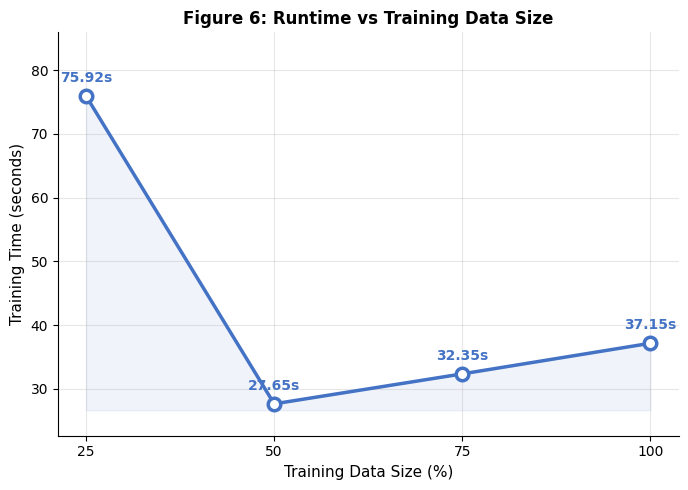

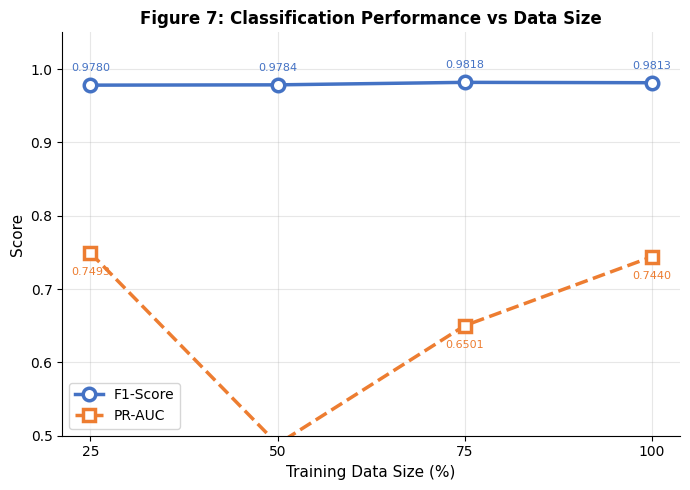

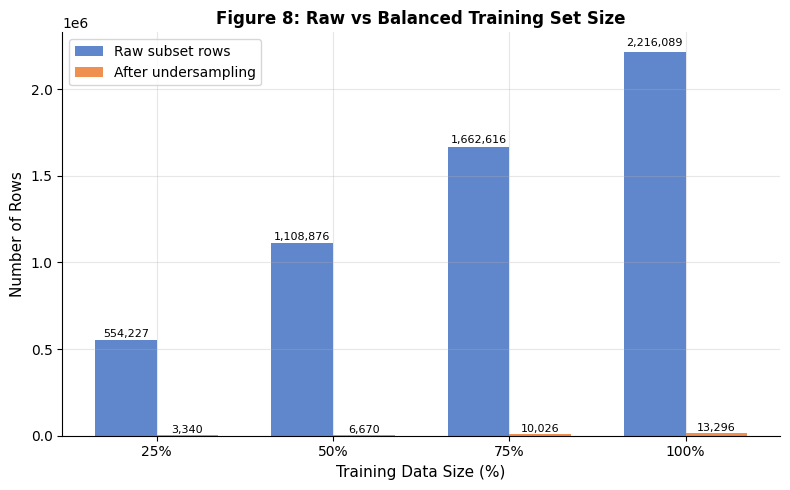

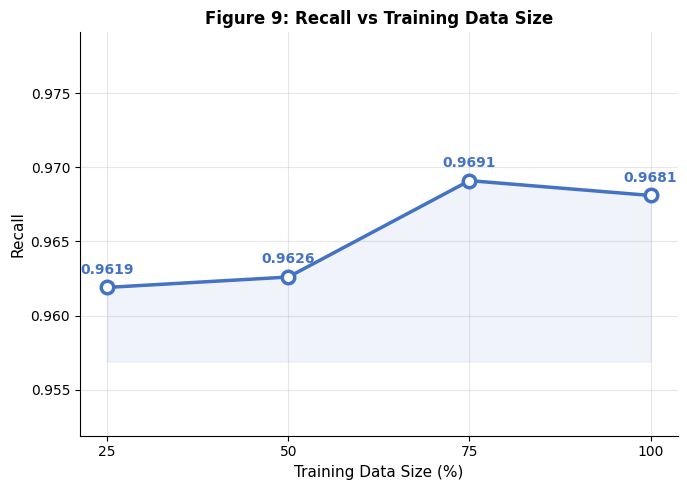

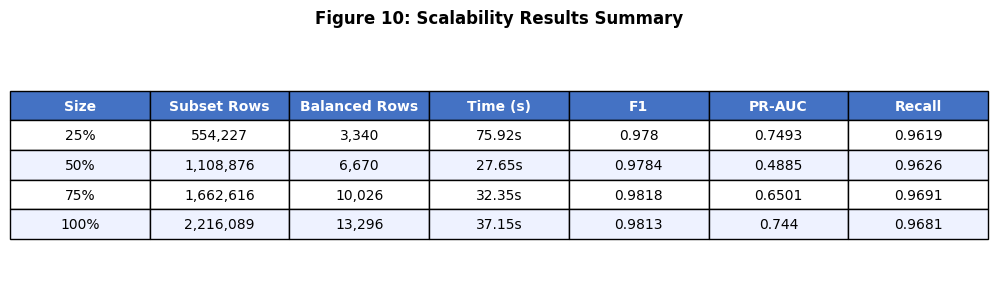

In [0]:
# Cell 13: Scalability Experiment Visualisations
# Author: Mohammed Adnan

BLUE   = "#4472C4"
ORANGE = "#ED7D31"

# Build data from scalability_results
sizes        = [r["fraction"]      for r in scalability_results]
scale_times  = [r["train_time"]    for r in scalability_results]
scale_f1     = [r["f1"]            for r in scalability_results]
scale_prauc  = [r["pr_auc"]        for r in scalability_results]
scale_recall = [r["recall"]        for r in scalability_results]
scale_rows   = [r["train_rows"]    for r in scalability_results]
scale_bal    = [r["balanced_rows"] for r in scalability_results]

# Figure 6: Runtime vs data size 
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(sizes, scale_times, "o-", color=BLUE,
        linewidth=2.5, markersize=9,
        markerfacecolor="white", markeredgewidth=2.5)
ax.fill_between(sizes, scale_times, min(scale_times) - 1,
                alpha=0.08, color=BLUE)
ax.set_xlabel("Training Data Size (%)", fontsize=11)
ax.set_ylabel("Training Time (seconds)", fontsize=11)
ax.set_title("Figure 6: Runtime vs Training Data Size",
             fontsize=12, fontweight="bold")
ax.set_xticks(sizes)
ax.set_ylim(min(scale_times) - 5, max(scale_times) + 10)
for xv, yv in zip(sizes, scale_times):
    ax.annotate(f"{yv:.2f}s", (xv, yv),
                textcoords="offset points",
                xytext=(0, 10), ha="center",
                fontsize=10, fontweight="bold", color=BLUE)
plt.tight_layout()
plt.show()
print()

# Figure 7: Classification performance vs data size 
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(sizes, scale_f1, "o-", color=BLUE,
        linewidth=2.5, markersize=9,
        markerfacecolor="white", markeredgewidth=2.5,
        label="F1-Score")
ax.plot(sizes, scale_prauc, "s--", color=ORANGE,
        linewidth=2.5, markersize=9,
        markerfacecolor="white", markeredgewidth=2.5,
        label="PR-AUC")
ax.set_xlabel("Training Data Size (%)", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Figure 7: Classification Performance vs Data Size",
             fontsize=12, fontweight="bold")
ax.set_xticks(sizes)
ax.set_ylim(0.5, 1.05)
ax.legend(fontsize=10)
for xv, yv in zip(sizes, scale_f1):
    ax.annotate(f"{yv:.4f}", (xv, yv),
                textcoords="offset points",
                xytext=(0, 10), ha="center",
                fontsize=8, color=BLUE)
for xv, yv in zip(sizes, scale_prauc):
    ax.annotate(f"{yv:.4f}", (xv, yv),
                textcoords="offset points",
                xytext=(0, -16), ha="center",
                fontsize=8, color=ORANGE)
plt.tight_layout()
plt.show()
print()

# Figure 8: Raw vs balanced training set size 
x, width = np.arange(len(sizes)), 0.35

fig, ax  = plt.subplots(figsize=(8, 5))
bars1    = ax.bar(x - width/2, scale_rows, width,
                  label="Raw subset rows", color=BLUE, alpha=0.85)
bars2    = ax.bar(x + width/2, scale_bal,  width,
                  label="After undersampling", color=ORANGE, alpha=0.85)
ax.set_xlabel("Training Data Size (%)", fontsize=11)
ax.set_ylabel("Number of Rows", fontsize=11)
ax.set_title("Figure 8: Raw vs Balanced Training Set Size",
             fontsize=12, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([f"{s}%" for s in sizes])
ax.legend(fontsize=10)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() * 1.01,
            f"{int(bar.get_height()):,}",
            ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() * 1.01,
            f"{int(bar.get_height()):,}",
            ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()
print()

# Figure 9: Recall vs data size
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(sizes, scale_recall, "o-", color=BLUE,
        linewidth=2.5, markersize=9,
        markerfacecolor="white", markeredgewidth=2.5)
ax.fill_between(sizes, scale_recall, min(scale_recall) - 0.005,
                alpha=0.08, color=BLUE)
ax.set_xlabel("Training Data Size (%)", fontsize=11)
ax.set_ylabel("Recall", fontsize=11)
ax.set_title("Figure 9: Recall vs Training Data Size",
             fontsize=12, fontweight="bold")
ax.set_xticks(sizes)
ax.set_ylim(min(scale_recall) - 0.01, max(scale_recall) + 0.01)
for xv, yv in zip(sizes, scale_recall):
    ax.annotate(f"{yv:.4f}", (xv, yv),
                textcoords="offset points",
                xytext=(0, 10), ha="center",
                fontsize=10, fontweight="bold", color=BLUE)
plt.tight_layout()
plt.show()
print()

# Figure 10: Summary results table 
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis("off")

table_data = [
    [f"{r['fraction']}%",
     f"{r['train_rows']:,}",
     f"{r['balanced_rows']:,}",
     f"{r['train_time']}s",
     f"{r['f1']}",
     f"{r['pr_auc']}",
     f"{r['recall']}"]
    for r in scalability_results
]
columns = ["Size", "Subset Rows", "Balanced Rows",
           "Time (s)", "F1", "PR-AUC", "Recall"]

table = ax.table(cellText=table_data, colLabels=columns,
                 cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)
for j in range(len(columns)):
    table[0, j].set_facecolor(BLUE)
    table[0, j].set_text_props(color="white", fontweight="bold")
for i in range(1, len(table_data) + 1):
    for j in range(len(columns)):
        if i % 2 == 0:
            table[i, j].set_facecolor("#EEF2FF")
ax.set_title("Figure 10: Scalability Results Summary",
             fontsize=12, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

## Cell 14 - Partition Count Experiment Visualisations
**Author: Mohammed Adnan**

Generates four figures from the partition count experiment (Cell 12).

- **Figure 11 - Runtime vs partition count**  
- **Figure 12 - F1 and PR-AUC vs partition count**  .
- **Figure 13 - Rows per partition**  
- **Figure 14 - Partition experiment summary table** 

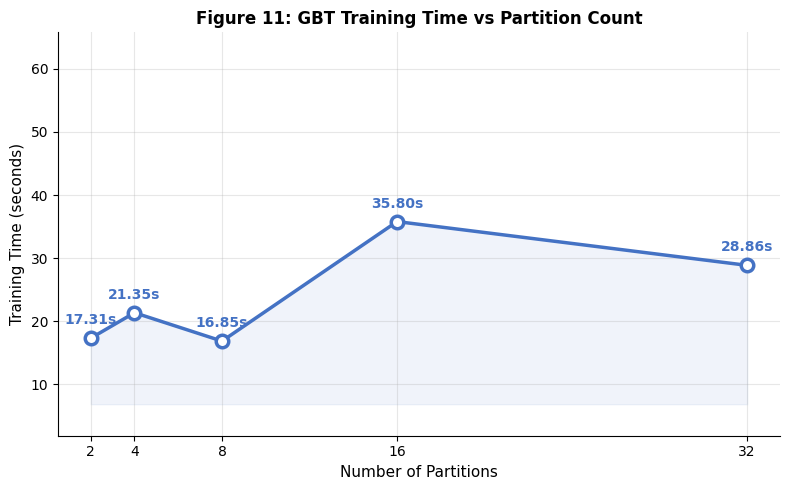

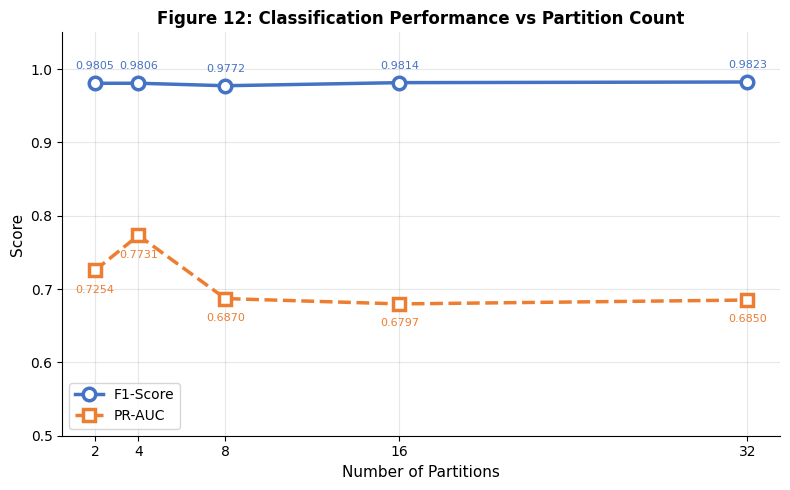

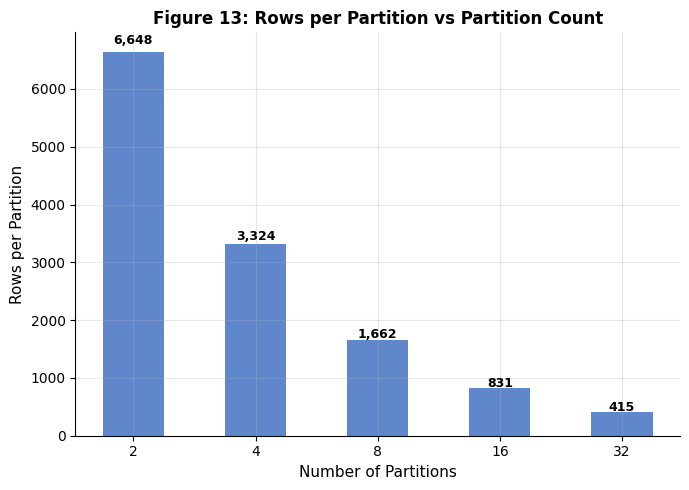

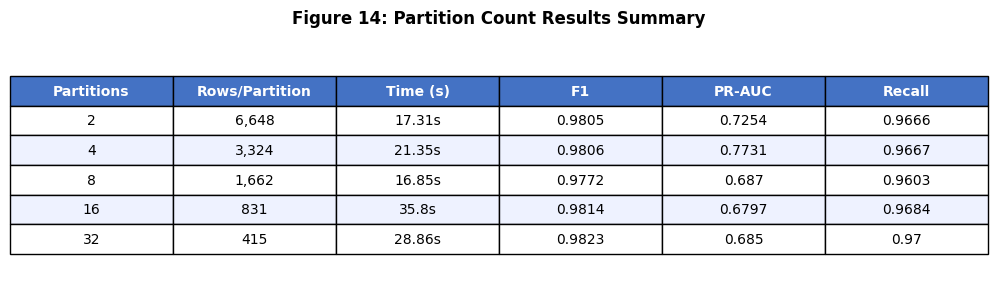

In [0]:
# Cell 14: Partition Count Experiment Visualisations
# Author: Mohammed Adnan

BLUE   = "#4472C4"
ORANGE = "#ED7D31"

# Build data from partition_results
parts         = [r["partitions"]    for r in partition_results]
part_times    = [r["train_time"]    for r in partition_results]
part_f1       = [r["f1"]            for r in partition_results]
part_prauc    = [r["pr_auc"]        for r in partition_results]
part_recall   = [r["recall"]        for r in partition_results]
rows_per_part = [r["rows_per_part"] for r in partition_results]


# Figure 11: Runtime vs partition count
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(parts, part_times, "o-", color=BLUE,
        linewidth=2.5, markersize=9,
        markerfacecolor="white", markeredgewidth=2.5)
ax.fill_between(parts, part_times, min(part_times) - 10,
                alpha=0.08, color=BLUE)
ax.set_xlabel("Number of Partitions", fontsize=11)
ax.set_ylabel("Training Time (seconds)", fontsize=11)
ax.set_title("Figure 11: GBT Training Time vs Partition Count",
             fontsize=12, fontweight="bold")
ax.set_xticks(parts)
ax.set_ylim(min(part_times) - 15, max(part_times) + 30)
for xv, yv in zip(parts, part_times):
    ax.annotate(f"{yv:.2f}s", (xv, yv),
                textcoords="offset points",
                xytext=(0, 10), ha="center",
                fontsize=10, fontweight="bold", color=BLUE)
plt.tight_layout()
plt.show()
print()

# Figure 12: F1 and PR-AUC vs partition count
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(parts, part_f1, "o-", color=BLUE,
        linewidth=2.5, markersize=9,
        markerfacecolor="white", markeredgewidth=2.5,
        label="F1-Score")
ax.plot(parts, part_prauc, "s--", color=ORANGE,
        linewidth=2.5, markersize=9,
        markerfacecolor="white", markeredgewidth=2.5,
        label="PR-AUC")
ax.set_xlabel("Number of Partitions", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Figure 12: Classification Performance vs Partition Count",
             fontsize=12, fontweight="bold")
ax.set_xticks(parts)
ax.set_ylim(0.5, 1.05)
ax.legend(fontsize=10)
for xv, yv in zip(parts, part_f1):
    ax.annotate(f"{yv:.4f}", (xv, yv),
                textcoords="offset points",
                xytext=(0, 10), ha="center",
                fontsize=8, color=BLUE)
for xv, yv in zip(parts, part_prauc):
    ax.annotate(f"{yv:.4f}", (xv, yv),
                textcoords="offset points",
                xytext=(0, -16), ha="center",
                fontsize=8, color=ORANGE)
plt.tight_layout()
plt.show()
print()

# Figure 13: Rows per partition 
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(range(len(parts)), rows_per_part,
       color=BLUE, alpha=0.85, width=0.5)
ax.set_xlabel("Number of Partitions", fontsize=11)
ax.set_ylabel("Rows per Partition", fontsize=11)
ax.set_title("Figure 13: Rows per Partition vs Partition Count",
             fontsize=12, fontweight="bold")
ax.set_xticks(range(len(parts)))
ax.set_xticklabels([str(p) for p in parts])
for pos, val in zip(range(len(parts)), rows_per_part):
    ax.text(pos, val * 1.02, f"{val:,}",
            ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.show()
print()

# Figure 14: Partition experiment summary table 
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis("off")

table_data = [
    [str(r["partitions"]),
     f"{r['rows_per_part']:,}",
     f"{r['train_time']}s",
     f"{r['f1']}",
     f"{r['pr_auc']}",
     f"{r['recall']}"]
    for r in partition_results
]
columns = ["Partitions", "Rows/Partition",
           "Time (s)", "F1", "PR-AUC", "Recall"]

table = ax.table(cellText=table_data, colLabels=columns,
                 cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)
for j in range(len(columns)):
    table[0, j].set_facecolor(BLUE)
    table[0, j].set_text_props(color="white", fontweight="bold")
for i in range(1, len(table_data) + 1):
    for j in range(len(columns)):
        if i % 2 == 0:
            table[i, j].set_facecolor("#EEF2FF")
ax.set_title("Figure 14: Partition Count Results Summary",
             fontsize=12, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

# Distributed Global AdaBoost using PySpark

## Fahad Al Mannan - Individual Contribution for the AdaBoost Pipeline Below

**Module:** COMP4124 Big Data  
**Dataset:** PaySim - 6,362,620 mobile money transactions, 0.13% fraud rate  
**Dataset Source:** Lopez-Rojas et al. (2016) / PaySim synthetic financial transactions  
**Main Focus:** Global AdaBoost implementation in PySpark, threshold tuning, size-up analysis, boosting-round scaling, and partition-count evaluation

---

## Pipeline Overview

| Step | Description |
|---:|---|
| 1 | **Environment Setup** - Importing PySpark SQL, PySpark ML, evaluators, vector utilities, storage tools, plotting, and timing libraries. |
| 2 | **Spark Session Setup** - Starting a local multi-core Spark session with memory and shuffle settings for distributed-style experiments. |
| 3 | **Data Ingestion** - Loading `Synthetic_Financial_Data.csv` into a Spark DataFrame with header and inferred schema. |
| 4 | **Initial Dataset Inspection** - Checking schema, first rows, total row count, and class imbalance between fraud and non-fraud transactions. |
| 5 | **Column Selection and Label Casting** - Selecting modelling columns and casting `isFraud` into the Spark ML `label` column. |
| 6 | **Balance Movement Feature Engineering** - Creating `orig_balance_delta`, `dest_balance_delta`, `orig_zero_after`, and `dest_zero_before`. |
| 7 | **Balance Error Feature Engineering** - Computing absolute origin balance error and binary `is_balance_inconsistent` flag. |
| 8 | **Preprocessing Pipeline Definition** - Indexing transaction `type`, one-hot encoding it, and assembling all numeric and encoded features into a single `features` vector. |
| 9 | **Train/Validation/Test Split** - Splitting data into 70% training, 15% validation, and 15% test sets using a fixed seed. |
| 10 | **Leakage-Safe Pipeline Fitting** - Fitting preprocessing only on the training split, then transforming validation and test data. |
| 11 | **Caching and Repartitioning** - Repartitioning prepared Spark DataFrames and caching them to reduce repeated feature-engineering cost. |
| 12 | **Class-Balanced Weight Initialisation** - Creating `weights_0` so fraud and non-fraud classes each contribute approximately half of the initial total weight. |
| 13 | **Round 1 Weak Learner Training** - Training a weighted Spark `DecisionTreeClassifier` using `weights_0`. |
| 14 | **Weighted Error Calculation** - Transforming the training DataFrame, comparing predictions to labels, and aggregating weighted error. |
| 15 | **Classifier Weight Calculation** - Computing AdaBoost learner weight `alpha = 0.5 * log((1 - error) / error)`. |
| 16 | **Row Weight Update** - Increasing weights for misclassified rows and decreasing weights for correctly classified rows using Spark `withColumn`. |
| 17 | **Weight Normalisation** - Normalising the new weight column so the updated weights sum to 1 before the next boosting round. |
| 18 | **Distributed AdaBoost Training Function** - Generalising the manual round logic into `train_distributed_adaboost` for repeated boosting rounds. |
| 19 | **Three-Round Ensemble Training** - Training a compact AdaBoost ensemble with 3 weak decision-tree models and storing each model with its alpha. |
| 20 | **Ensemble Prediction Function** - Applying all weak learners, converting predictions to signed votes, summing `alpha`-weighted votes into `ensemble_score`, and thresholding predictions. |
| 21 | **Validation Evaluation** - Computing validation accuracy, weighted F1, ROC AUC, PR AUC, and confusion matrix using the default threshold. |
| 22 | **Threshold Tuning** - Searching ensemble-score thresholds on validation data to maximise fraud-class F1. |
| 23 | **Tuned Test Evaluation** - Applying the best validation threshold to the test set and reporting fraud precision, fraud recall, fraud F1, ROC AUC, and PR AUC. |
| 24 | **Size-Up Experiment** - Training the same 3-round AdaBoost model on 10% to 100% of training data to measure runtime scaling with data size. |
| 25 | **Size-Up Visualisations** - Plotting runtime, size-up versus ideal linear scaling, throughput, and scaling efficiency. |
| 26 | **Boosting-Round Scaling Experiment** - Training models with 1 to 5 boosting rounds to measure how runtime grows with the number of weak learners. |
| 27 | **Iteration-Scaling Visualisations** - Plotting runtime versus boosting rounds, ideal linear comparison, and average cost per round. |
| 28 | **Confusion Matrix Visualisation** - Plotting raw and normalised tuned test-set confusion matrices. |
| 29 | **Partition-Count Experiment** - Repartitioning the weighted training set into 8, 14, 20, 26, and 30 partitions and retraining the 3-round ensemble. |
| 30 | **Partition Evaluation** - Measuring runtime, accuracy, weighted F1, ROC AUC, PR AUC, fraud precision, fraud recall, and fraud F1 for each partition count. |
| 31 | **Partition Visualisations** - Plotting accuracy/F1, fraud-class metrics, runtime, measured speedup, and scaling efficiency across partition counts. |

---

## Distributed AdaBoost Workflow Summary

| Stage | Spark Operation | Purpose |
|---:|---|---|
| 1 | `DecisionTreeClassifier.fit(working_df)` | Train a weak learner using the current row-weight column. |
| 2 | `model.transform(working_df)` | Generate predictions for each row while keeping computation distributed across partitions. |
| 3 | `filter(...).agg(F.sum(weight_col)).collect()` | Collect only scalar weighted error to the driver. |
| 4 | `withColumn(next_weight_col, ...)` | Update row weights in Spark without collecting rows. |
| 5 | `agg(F.sum(next_weight_col)).collect()` | Collect only scalar normalisation value. |
| 6 | `select("features", "label", next_weight_col).cache()` | Prepare the next round's distributed training state. |
| 7 | `working_df = next_working_df` | Repeat the next boosting round using `weights_i+1`. |

---

## Main Results Included in the Notebook

| Experiment | Key Result |
|---|---|
| Class imbalance inspection | 6,362,620 total rows: 6,354,407 non-fraud and 8,213 fraud. |
| Training split | 4,454,299 training rows with 5,809 fraud cases. |
| Three-round AdaBoost | Weighted errors: 0.00329, 0.11389, 0.17353. |
| Learner alpha values | 2.8562, 1.0258, 0.7804. |
| Validation metrics | Accuracy 0.999954, ROC AUC 0.999589, PR AUC 0.988928. |
| Best validation threshold | 1.1656, selected by fraud-class F1. |
| Tuned test metrics | Fraud precision 0.9616, fraud recall 0.9966, fraud F1 0.9788, PR AUC 0.9877. |
| Tuned test confusion matrix | TN=953,368, FP=47, FN=4, TP=1,178. |
| Size-up experiment | Runtime grows from 1.93s at 10% data to 6.52s at 100% data. |
| Boosting-round experiment | Runtime grows near-linearly from 1.93s for 1 round to 9.84s for 5 rounds. |
| Partition experiment | Fraud recall remains stable at approximately 0.9967 across tested partition counts. |

---

## Key Contribution

The notebook implements a global AdaBoost training loop around Spark ML decision-tree weak learners. Spark ML handles the distributed tree fitting, while the notebook implements the AdaBoost-specific logic: class-balanced initial weights, weighted-error aggregation, alpha calculation, distributed row-weight updates, normalisation, model/alpha storage, signed ensemble voting, threshold tuning, and scalability experiments.


Research Questions

**RQ1:** How to implement different class imbalance techniques like undersampling, oversampling and class weights and different classification algorithms like Decision Tree , Gradient Boosting and Adaboost in distributed design for this dataset?

**RQ2:** Size up analysis of these implementations , which implementation follows linear, sub linear and super linear and why?

**RQ3:** How the accuracy changes with change in the partitions count whether the implementations folllowing ideal case or not and why?

## Loading Spark Session and Data + Feature Engineering

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.feature import ElementwiseProduct
from pyspark.ml.functions import array_to_vector, vector_to_array
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.linalg import Vectors

Starting a local Spark session. The memory and shuffle settings are chosen for a single-machine distributed-style run.


In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("PaySim_Distributed_AdaBoost") \
    .master("local[*]") \
    .config("spark.driver.memory", "16g") \
    .config("spark.executor.memory", "16g") \
    .config("spark.sql.shuffle.partitions", "12") \
    .getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/01 10:59:48 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Loading the dataset, inferring schema and inspecting first five rows.

In [3]:
df = spark.read.csv(
    "Synthetic_Financial_Data.csv",
    header=True,
    inferSchema=True
)

df.printSchema()
df.show(5, truncate=False)

root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- nameOrig: string (nullable = true)
 |-- oldbalanceOrg: double (nullable = true)
 |-- newbalanceOrig: double (nullable = true)
 |-- nameDest: string (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- newbalanceDest: double (nullable = true)
 |-- isFraud: integer (nullable = true)
 |-- isFlaggedFraud: integer (nullable = true)

+----+--------+--------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|step|type    |amount  |nameOrig   |oldbalanceOrg|newbalanceOrig|nameDest   |oldbalanceDest|newbalanceDest|isFraud|isFlaggedFraud|
+----+--------+--------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|1   |PAYMENT |9839.64 |C1231006815|170136.0     |160296.36     |M1979787155|0.0           |0.0           |0      |0             |
|1   |PAY

Inspecting total row count and the high class imbalance.

In [4]:
print("Total rows:", df.count())

df.groupBy("isFraud").count().show()

Total rows: 6362620
+-------+-------+
|isFraud|  count|
+-------+-------+
|      0|6354407|
|      1|   8213|
+-------+-------+



Now we select our required columns used for modeling and cast the `isFraud` column to the ML `label` column which is expected by Spark classifiers and then inspect

In [5]:
data = df.select(
    "step",
    "type",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    F.col("isFraud").cast("double").alias("label")
)

data.printSchema()
data.show(5, truncate=False)

root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- oldbalanceOrg: double (nullable = true)
 |-- newbalanceOrig: double (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- newbalanceDest: double (nullable = true)
 |-- label: double (nullable = true)

+----+--------+--------+-------------+--------------+--------------+--------------+-----+
|step|type    |amount  |oldbalanceOrg|newbalanceOrig|oldbalanceDest|newbalanceDest|label|
+----+--------+--------+-------------+--------------+--------------+--------------+-----+
|1   |PAYMENT |9839.64 |170136.0     |160296.36     |0.0           |0.0           |0.0  |
|1   |PAYMENT |1864.28 |21249.0      |19384.72      |0.0           |0.0           |0.0  |
|1   |TRANSFER|181.0   |181.0        |0.0           |0.0           |0.0           |1.0  |
|1   |CASH_OUT|181.0   |181.0        |0.0           |21182.0       |0.0           |1.0  |
|1   |PAYMENT |11668.14|41554.0  

Here we perform feature engineering. Firstly, by creating a balance movement feature that will capture how origin and destination balance changes during a transaction.

In [6]:
data = data.withColumn(
    "orig_balance_delta",
    F.col("oldbalanceOrg") - F.col("newbalanceOrig")
).withColumn(
    "dest_balance_delta",
    F.col("newbalanceDest") - F.col("oldbalanceDest")
).withColumn(
    "orig_zero_after",
    F.when(F.col("newbalanceOrig") == 0, 1.0).otherwise(0.0)
).withColumn(
    "dest_zero_before",
    F.when(F.col("oldbalanceDest") == 0, 1.0).otherwise(0.0)
)

Now, we inspect our implementation

In [7]:
data.select(
    "oldbalanceOrg",
    "newbalanceOrig",
    "orig_balance_delta",
    "oldbalanceDest",
    "newbalanceDest",
    "dest_balance_delta"
).show(5, truncate=False)

+-------------+--------------+------------------+--------------+--------------+------------------+
|oldbalanceOrg|newbalanceOrig|orig_balance_delta|oldbalanceDest|newbalanceDest|dest_balance_delta|
+-------------+--------------+------------------+--------------+--------------+------------------+
|170136.0     |160296.36     |9839.640000000014 |0.0           |0.0           |0.0               |
|21249.0      |19384.72      |1864.2799999999988|0.0           |0.0           |0.0               |
|181.0        |0.0           |181.0             |0.0           |0.0           |0.0               |
|181.0        |0.0           |181.0             |21182.0       |0.0           |-21182.0          |
|41554.0      |29885.86      |11668.14          |0.0           |0.0           |0.0               |
+-------------+--------------+------------------+--------------+--------------+------------------+
only showing top 5 rows


Now, we compare the `orig_balance_delta` to identify unusual behaviours.


In [8]:
data.select(
    "amount",
    "orig_balance_delta",
    (F.col("orig_balance_delta") - F.col("amount")).alias("diff")
).show(10, truncate=False)

+--------+------------------+-----------------------+
|amount  |orig_balance_delta|diff                   |
+--------+------------------+-----------------------+
|9839.64 |9839.640000000014 |1.4551915228366852E-11 |
|1864.28 |1864.2799999999988|-1.1368683772161603E-12|
|181.0   |181.0             |0.0                    |
|181.0   |181.0             |0.0                    |
|11668.14|11668.14          |0.0                    |
|7817.71 |7817.709999999999 |-9.094947017729282E-13 |
|7107.77 |7107.7699999999895|-1.0913936421275139E-11|
|7861.64 |7861.640000000014 |1.3642420526593924E-11 |
|4024.36 |2671.0            |-1353.3600000000001    |
|5337.77 |5337.769999999997 |-3.637978807091713E-12 |
+--------+------------------+-----------------------+
only showing top 10 rows


Adding the the raw absolute balance error feature.


In [9]:
data = data.withColumn(
    "balance_error",
    F.abs(F.col("orig_balance_delta") - F.col("amount"))
)

Converting the `balance_error` into a binary classification.

In [10]:
data = data.withColumn(
    "is_balance_inconsistent",
    F.when(F.col("balance_error") > 1.0, 1.0).otherwise(0.0)
)

Inspecting the changes

In [11]:
data.select(
    "amount",
    "orig_balance_delta",
    "balance_error",
    "is_balance_inconsistent"
).show(10, truncate=False)

+--------+------------------+----------------------+-----------------------+
|amount  |orig_balance_delta|balance_error         |is_balance_inconsistent|
+--------+------------------+----------------------+-----------------------+
|9839.64 |9839.640000000014 |1.4551915228366852E-11|0.0                    |
|1864.28 |1864.2799999999988|1.1368683772161603E-12|0.0                    |
|181.0   |181.0             |0.0                   |0.0                    |
|181.0   |181.0             |0.0                   |0.0                    |
|11668.14|11668.14          |0.0                   |0.0                    |
|7817.71 |7817.709999999999 |9.094947017729282E-13 |0.0                    |
|7107.77 |7107.7699999999895|1.0913936421275139E-11|0.0                    |
|7861.64 |7861.640000000014 |1.3642420526593924E-11|0.0                    |
|4024.36 |2671.0            |1353.3600000000001    |1.0                    |
|5337.77 |5337.769999999997 |3.637978807091713E-12 |0.0                    |

## Data Splitting and inspection + Model Pipeline

Defining the preprocessing pipeline. For avoiding validation and test leakage, our fitted preprocessing model must be learned from the training split only.


In [12]:
# Step 1: encode transaction type
indexer = StringIndexer(inputCol="type", outputCol="type_idx", handleInvalid="keep")
encoder = OneHotEncoder(inputCols=["type_idx"], outputCols=["type_ohe"])

# Step 2: defining all feature columns
feature_cols = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "orig_balance_delta",
    "dest_balance_delta",
    "orig_zero_after",
    "dest_zero_before",
    "balance_error",
    "is_balance_inconsistent",
    "type_ohe"
]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features",
    handleInvalid="keep"
)

# Step 3: building the pipeline object.
pipeline = Pipeline(stages=[indexer, encoder, assembler])

Spliting the engineered data first, fitting preprocessing on the training rows only, then caching the prepared train/validation/test DataFrames. Caching here prevents Spark from re-running feature engineering every time these DataFrames are used minimizing computation cost.


In [13]:
train_raw, valid_raw, test_raw = data.randomSplit([0.7, 0.15, 0.15], seed=42)

# Fitting the preprocessing only on training data to avoid validation/test leakage.
prep_model = pipeline.fit(train_raw)


train = prep_model.transform(train_raw).select("features", "label").repartition(8).cache()
valid = prep_model.transform(valid_raw).select("features", "label").repartition(8).cache()
test = prep_model.transform(test_raw).select("features", "label").repartition(8).cache()

# With action, creating the dataframes
print("Train:", train.count())
print("Valid:", valid.count())
print("Test :", test.count())

train.show(5, truncate=False)

26/05/01 11:00:14 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Train: 4454299


Valid: 953724


Test : 954597
+---------------------------------------------------------------------------------------------------------------------------+-----+
|features                                                                                                                   |label|
+---------------------------------------------------------------------------------------------------------------------------+-----+
|(17,[0,1,4,5,7,8,10,11,12],[17.0,684979.55,1558653.7,2243633.25,684979.55,1.0,684979.55,1.0,1.0])                          |0.0  |
|(17,[0,1,4,5,7,8,10,11,12],[14.0,203206.27,796585.66,999791.93,203206.27000000002,1.0,203206.27,1.0,1.0])                  |0.0  |
|[12.0,104371.33,325.0,104696.33,507594.3,676539.05,-104371.33,168944.75000000006,0.0,0.0,208742.66,1.0,0.0,0.0,1.0,0.0,0.0]|0.0  |
|(17,[0,1,2,3,6,9,10,11,14],[16.0,268162.04,2558.0,270720.04,-268162.04,1.0,536324.08,1.0,1.0])                             |0.0  |
|(17,[0,1,2,3,6,9,10,13],[18.0,2994.15,216973.03,213978.88,299

Verifying training set

In [14]:
train.groupBy("label").count().show()

+-----+-------+
|label|  count|
+-----+-------+
|  0.0|4448490|
|  1.0|   5809|
+-----+-------+



In [15]:
train.withColumn(
    "partition_id",
    F.spark_partition_id()
).groupBy(
    "partition_id", "label"
).count().orderBy(
    "partition_id", "label"
).show()

+------------+-----+------+
|partition_id|label| count|
+------------+-----+------+
|           0|  0.0|556049|
|           0|  1.0|   739|
|           1|  0.0|556056|
|           1|  1.0|   730|
|           2|  0.0|556097|
|           2|  1.0|   691|
|           3|  0.0|556066|
|           3|  1.0|   721|
|           4|  0.0|556044|
|           4|  1.0|   743|
|           5|  0.0|556097|
|           5|  1.0|   691|
|           6|  0.0|556040|
|           6|  1.0|   748|
|           7|  0.0|556041|
|           7|  1.0|   746|
+------------+-----+------+



Our Training set has the data distributed with portions from both classes accross the partitions

## Global AdaBoost Implementation

Initialize AdaBoost row weights dynamically, then cache the weighted training DataFrame because every boosting round starts from this repeatedly used base data.

In [16]:
def initialize_adaboost_weights(df, label_col="label", weight_col="weights_0", class_balanced=True):
    #Create normalized starting weights for AdaBoost.
    
    counts = {row[label_col]: row["count"] for row in df.groupBy(label_col).count().collect()}

    if class_balanced:
        n_classes = len(counts)
        weighted = df.withColumn(
            weight_col,
            F.when(F.col(label_col) == 1.0, F.lit(1.0 / (n_classes * counts.get(1.0, 1))))
             .otherwise(F.lit(1.0 / (n_classes * counts.get(0.0, 1))))
        )
    else:
        total = sum(counts.values())
        weighted = df.withColumn(weight_col, F.lit(1.0 / total))

    return weighted

# Cache the weighted training set because AdaBoost scans it repeatedly.
train_w = initialize_adaboost_weights(train, class_balanced=True).cache()

# Materialize the cache before entering the iterative training loop.
train_w.count()

4454299

Confirm that the initial training weights sum to one, with half of the total weight assigned to each class in class-balanced mode.

In [17]:
train_w.groupBy("label").agg(F.sum("weights_0")).show()

+-----+-------------------+
|label|     sum(weights_0)|
+-----+-------------------+
|  0.0|0.49999999999918726|
|  1.0|0.49999999999999545|
+-----+-------------------+



Training the first weighted decision-tree weak learner.

In [18]:
dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="label",
    weightCol="weights_0",
    maxDepth=3,
    minInstancesPerNode=100,
    seed=42
)

model_0 = dt.fit(train_w)

Score the weighted training set with the first weak learner.

In [19]:
pred_0 = model_0.transform(train_w)

Computing the first round's weighted error as the sum of weights for misclassified rows.

In [20]:
err_row = pred_0.filter(F.col("prediction") != F.col("label")) \
    .agg(F.sum("weights_0").alias("weighted_error")) \
    .collect()[0]

err = err_row["weighted_error"]

print("Weighted error:", err)

Weighted error: 0.003293603441347698


Converting weighted error into the AdaBoost classifier weight `alpha`.

In [21]:
import math

alpha_0 = 0.5 * math.log((1 - err) / err)

print("Alpha:", alpha_0)

Alpha: 2.8562370016789806


Marking correct predictions as `+1` and mistakes as `-1`, then applying the AdaBoost exponential weight update.

In [22]:
pred_0 = pred_0.withColumn(
    "correct_0",
    F.when(F.col("prediction") == F.col("label"), 1.0).otherwise(-1.0)
)

pred_0 = pred_0.withColumn(
    "weights_1",
    F.exp(-F.col("correct_0") * F.lit(alpha_0)) * F.col("weights_0")
)

Normalising the updated weights so the next round again sees a proper probability distribution.

In [23]:
sum_w1 = pred_0.agg(F.sum("weights_1").alias("sum_w1")).collect()[0]["sum_w1"]

pred_0 = pred_0.withColumn(
    "weights_1",
    F.col("weights_1") / F.lit(sum_w1)
)

Checking if the first updated weight column sums to one.

In [24]:
pred_0.agg(F.sum("weights_1").alias("sum_weights_1")).show()

+------------------+
|     sum_weights_1|
+------------------+
|0.9999999999869742|
+------------------+



Comparing average weights before and after the update

In [25]:
pred_0.groupBy("correct_0").agg(
    F.count("*").alias("rows"),
    F.avg("weights_0").alias("avg_weight_before"),
    F.avg("weights_1").alias("avg_weight_after")
).show()

+---------+-------+--------------------+--------------------+
|correct_0|   rows|   avg_weight_before|    avg_weight_after|
+---------+-------+--------------------+--------------------+
|      1.0|4454058|2.237749029217621...|1.122571821008354...|
|     -1.0|    241|1.366640432094480...|0.002074688796652695|
+---------+-------+--------------------+--------------------+



Train the second weak learner with the first round's updated weights and unique output column names.

In [26]:
dt_1 = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="label",
    weightCol="weights_1",
    predictionCol="prediction_1",
    rawPredictionCol="rawPrediction_1",
    probabilityCol="probability_1",
    maxDepth=3,
    minInstancesPerNode=100,
    seed=43
)

model_1 = dt_1.fit(pred_0)
pred_1 = model_1.transform(pred_0)

Compute the second round's weighted error.

In [27]:
err_1 = pred_1.filter(F.col("prediction_1") != F.col("label")) \
    .agg(F.sum("weights_1").alias("weighted_error")) \
    .collect()[0]["weighted_error"]

print("Weighted error round 2:", err_1)

Weighted error round 2: 0.11389329145660114


Computing the second weak learner's alpha.

In [28]:
alpha_1 = 0.5 * math.log((1 - err_1) / err_1)
print("Alpha round 2:", alpha_1)

Alpha round 2: 1.025787705854132


Applying the second round's correct/mistake marker and exponential weight update.

In [29]:
pred_1 = pred_1.withColumn(
    "correct_1",
    F.when(F.col("prediction_1") == F.col("label"), 1.0).otherwise(-1.0)
)

pred_1 = pred_1.withColumn(
    "weights_2",
    F.exp(-F.col("correct_1") * F.lit(alpha_1)) * F.col("weights_1")
)

Normalize the second updated weight column.

In [30]:
sum_w2 = pred_1.agg(F.sum("weights_2").alias("sum_w2")).collect()[0]["sum_w2"]

pred_1 = pred_1.withColumn(
    "weights_2",
    F.col("weights_2") / F.lit(sum_w2)
)

Checking if the second updated weight column sums to one.


In [31]:
pred_1.agg(F.sum("weights_2").alias("sum_weights_2")).show()

+-----------------+
|    sum_weights_2|
+-----------------+
|1.000000000000254|
+-----------------+



Inspecting how the second round changed average weights for correct and misclassified rows.

In [32]:
pred_1.groupBy("correct_1").agg(
    F.count("*").alias("rows"),
    F.avg("weights_1").alias("avg_weight_before"),
    F.avg("weights_2").alias("avg_weight_after")
).show()

+---------+-------+--------------------+--------------------+
|correct_1|   rows|   avg_weight_before|    avg_weight_after|
+---------+-------+--------------------+--------------------+
|      1.0|2492272|3.555417340203479E-7|2.006201570278889...|
|     -1.0|1962027|5.804878906182287E-8|2.548384910125283...|
+---------+-------+--------------------+--------------------+



Now, we package the global AdaBoost design into a reusable training loop. The loop now caches each newly weighted training DataFrame and unpersists the previous round's DataFrame to reduce recomputation and memory pressure.


In [33]:
def train_distributed_adaboost(
    train_df,
    max_iter=5,
    max_depth=3,
    min_instances_per_node=100,
    seed=42,
    eps=1e-12,
    keep_debug_columns=False
):
    """
    Each round trains a weighted weak learner, computes weighted error, derives
    alpha, up-weights misclassified rows, normalizes the next weight column, and
    stores the fitted model plus alpha for inference.
    """
    models = []
    alphas = []
    history = []

    # The input is already cached by the caller; this loop caches only the newly
    # weighted DataFrame created at the end of each boosting round.
    working_df = train_df
    cached_working_df = None

    for i in range(max_iter):
        print(f"\n=== Boosting round {i + 1}/{max_iter} ===")

        pred_col = f"prediction_{i}"
        raw_col = f"rawPrediction_{i}"
        prob_col = f"probability_{i}"
        correct_col = f"correct_{i}"
        weight_col = f"weights_{i}"
        next_weight_col = f"weights_{i + 1}"

        dt = DecisionTreeClassifier(
            featuresCol="features",
            labelCol="label",
            weightCol=weight_col,
            predictionCol=pred_col,
            rawPredictionCol=raw_col,
            probabilityCol=prob_col,
            maxDepth=max_depth,
            minInstancesPerNode=min_instances_per_node,
            seed=seed + i
        )

        model = dt.fit(working_df)
        scored = model.transform(working_df)

        err = scored.filter(F.col(pred_col) != F.col("label")) \
            .agg(F.sum(weight_col).alias("weighted_error")) \
            .collect()[0]["weighted_error"]

        err = 0.0 if err is None else float(err)
        print(f"Weighted error: {err}")

        if err <= eps:
            alpha = 0.5 * math.log((1.0 - eps) / eps)
            print(f"Near-perfect learner detected. Using capped alpha={alpha}")
            models.append(model)
            alphas.append(alpha)
            history.append({"round": i, "error": err, "alpha": alpha})
            break

        if err >= 0.5:
            print("Error >= 0.5, stopping and discarding this weak learner.")
            break

        alpha = 0.5 * math.log((1.0 - err) / err)
        print(f"Alpha: {alpha}")

        scored = scored.withColumn(
            correct_col,
            F.when(F.col(pred_col) == F.col("label"), F.lit(1.0)).otherwise(F.lit(-1.0))
        )

        scored = scored.withColumn(
            next_weight_col,
            F.exp(-F.col(correct_col) * F.lit(alpha)) * F.col(weight_col)
        )

        sum_w = scored.agg(F.sum(next_weight_col).alias("sum_w")).collect()[0]["sum_w"]
        scored = scored.withColumn(next_weight_col, F.col(next_weight_col) / F.lit(sum_w))

        models.append(model)
        alphas.append(alpha)
        history.append({"round": i, "error": err, "alpha": alpha})

        if keep_debug_columns:
            next_working_df = scored
        else:
            next_working_df = scored.select("features", "label", next_weight_col)

        # Cache each round's updated training state so the next weak learner does not recompute the full chain of feature engineering and previous rounds.
        next_working_df = next_working_df.cache()
        next_working_df.count()  # materialize the cache

        # Once the next round is cached, release the previous round's cached state.
        if cached_working_df is not None:
            cached_working_df.unpersist()

        cached_working_df = next_working_df
        working_df = next_working_df

    return models, alphas, history, working_df

Training a compact three-round AdaBoost ensemble for validation and test experiments.

In [34]:
models, alphas, history, final_df = train_distributed_adaboost(
    train_df=train_w,
    max_iter=3
)


=== Boosting round 1/3 ===
Weighted error: 0.003293603441347698
Alpha: 2.8562370016789806

=== Boosting round 2/3 ===
Weighted error: 0.11389329145660114
Alpha: 1.025787705854132

=== Boosting round 3/3 ===
Weighted error: 0.1735287936390073
Alpha: 0.7804107677122428


Inspecting the learned alpha values and round-by-round weighted errors.

In [35]:
print("Alphas:", alphas)
print("History:", history)

Alphas: [2.8562370016789806, 1.025787705854132, 0.7804107677122428]
History: [{'round': 0, 'error': 0.003293603441347698, 'alpha': 2.8562370016789806}, {'round': 1, 'error': 0.11389329145660114, 'alpha': 1.025787705854132}, {'round': 2, 'error': 0.1735287936390073, 'alpha': 0.7804107677122428}]


After that, we score new data with the trained ensemble using the explicit signed weighted-vote form of AdaBoost: predictions are mapped to `-1/+1`, weighted by alpha, summed, and thresholded at zero.

In [36]:
def predict_adaboost_ensemble(dataset, models, alphas):
    """Apply the trained weak learners using AdaBoost's signed weighted vote."""
    scored = dataset

    for model in models:
        scored = model.transform(scored)

    signed_terms = []
    for i, alpha in enumerate(alphas):
        pred_col = f"prediction_{i}"
        signed_col = f"signed_prediction_{i}"
        scored = scored.withColumn(signed_col, F.when(F.col(pred_col) == 1.0, F.lit(1.0)).otherwise(F.lit(-1.0)))
        signed_terms.append(F.lit(float(alpha)) * F.col(signed_col))

    if signed_terms:
        score_expr = signed_terms[0]
        for term in signed_terms[1:]:
            score_expr = score_expr + term
        scored = scored.withColumn("ensemble_score", score_expr)
    else:
        scored = scored.withColumn("ensemble_score", F.lit(0.0))

    scored = scored.withColumn(
        "ensemble_prediction",
        (F.col("ensemble_score") > F.lit(0.0)).cast("double")
    )

    return scored


Generating validation predictions from the AdaBoost ensemble.

In [37]:
valid_pred = predict_adaboost_ensemble(valid, models, alphas)

Inspecting individual weak-learner predictions alongside the final ensemble score and prediction.

In [38]:
valid_pred.select(
    "label",
    "prediction_0",
    "prediction_1",
    "prediction_2",
    "ensemble_score",
    "ensemble_prediction"
).show(10, truncate=False)

+-----+------------+------------+------------+-------------------+-------------------+
|label|prediction_0|prediction_1|prediction_2|ensemble_score     |ensemble_prediction|
+-----+------------+------------+------------+-------------------+-------------------+
|0.0  |0.0         |0.0         |0.0         |-4.662435475245355 |0.0                |
|0.0  |0.0         |0.0         |0.0         |-4.662435475245355 |0.0                |
|0.0  |0.0         |0.0         |0.0         |-4.662435475245355 |0.0                |
|0.0  |0.0         |1.0         |1.0         |-1.050038528112606 |0.0                |
|0.0  |0.0         |0.0         |1.0         |-3.1016139398208695|0.0                |
|0.0  |0.0         |0.0         |0.0         |-4.662435475245355 |0.0                |
|0.0  |0.0         |1.0         |1.0         |-1.050038528112606 |0.0                |
|0.0  |0.0         |0.0         |0.0         |-4.662435475245355 |0.0                |
|0.0  |0.0         |1.0         |1.0       

Evaluating validation performance with accuracy, weighted F1, ROC AUC, and PR AUC. PR AUC is especially useful for the rare fraud class.

In [39]:
# Accuracy
acc_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="ensemble_prediction",
    metricName="accuracy"
)

# F1 score
f1_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="ensemble_prediction",
    metricName="f1"
)

# ROC AUC
roc_eval = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="ensemble_score",
    metricName="areaUnderROC"
)

# PR AUC (VERY important for imbalance)
pr_eval = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="ensemble_score",
    metricName="areaUnderPR"
)

print("Accuracy:", acc_eval.evaluate(valid_pred))
print("F1 Score:", f1_eval.evaluate(valid_pred))
print("ROC AUC:", roc_eval.evaluate(valid_pred))
print("PR AUC:", pr_eval.evaluate(valid_pred))

Accuracy: 0.9999538650594931
F1 Score: 0.9999541994739397
ROC AUC: 0.9995888668417675
PR AUC: 0.988927888146029


Inspecting the validation confusion counts for the default AdaBoost decision threshold.

In [40]:
valid_pred.groupBy("label", "ensemble_prediction").count().orderBy("label", "ensemble_prediction").show()

+-----+-------------------+------+
|label|ensemble_prediction| count|
+-----+-------------------+------+
|  0.0|                0.0|952462|
|  0.0|                1.0|    40|
|  1.0|                0.0|     4|
|  1.0|                1.0|  1218|
+-----+-------------------+------+



We tune the decision threshold using fraud-class precision, recall, and F1 so the selected cutoff reflects minority-class fraud detection performance rather than majority-class accuracy.

In [41]:
def positive_class_f1_at_threshold(scored_df, threshold, label_col="label", score_col="ensemble_score"):
    temp = scored_df.withColumn(
        "custom_pred",
        (F.col(score_col) > F.lit(float(threshold))).cast("double")
    )

    counts = {
        (row[label_col], row["custom_pred"]): row["count"]
        for row in temp.groupBy(label_col, "custom_pred").count().collect()
    }
    tp = counts.get((1.0, 1.0), 0)
    fp = counts.get((0.0, 1.0), 0)
    fn = counts.get((1.0, 0.0), 0)

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return precision, recall, f1

score_limit = float(sum(alphas))
thresholds = [(-score_limit + (2 * score_limit) * x / 40.0) for x in range(1, 40)]

best_threshold = None
best_f1 = -1.0
best_precision = 0.0
best_recall = 0.0

for th in thresholds:
    precision, recall, f1 = positive_class_f1_at_threshold(valid_pred, th)
    print(f"Threshold={th:.4f} | precision={precision:.6f} | recall={recall:.6f} | fraud_F1={f1:.6f}")

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = th
        best_precision = precision
        best_recall = recall

print("\nBest threshold:", best_threshold)
print("Best fraud precision:", best_precision)
print("Best fraud recall:", best_recall)
print("Best fraud F1:", best_f1)


Threshold=-4.4293 | precision=0.002696 | recall=1.000000 | fraud_F1=0.005378
Threshold=-4.1962 | precision=0.002696 | recall=1.000000 | fraud_F1=0.005378
Threshold=-3.9631 | precision=0.002696 | recall=1.000000 | fraud_F1=0.005378
Threshold=-3.7299 | precision=0.002696 | recall=1.000000 | fraud_F1=0.005378
Threshold=-3.4968 | precision=0.002696 | recall=1.000000 | fraud_F1=0.005378
Threshold=-3.2637 | precision=0.002696 | recall=1.000000 | fraud_F1=0.005378
Threshold=-3.0306 | precision=0.002897 | recall=1.000000 | fraud_F1=0.005777
Threshold=-2.7975 | precision=0.002897 | recall=1.000000 | fraud_F1=0.005777
Threshold=-2.5643 | precision=0.009269 | recall=0.999182 | fraud_F1=0.018367
Threshold=-2.3312 | precision=0.009269 | recall=0.999182 | fraud_F1=0.018367
Threshold=-2.0981 | precision=0.009269 | recall=0.999182 | fraud_F1=0.018367
Threshold=-1.8650 | precision=0.009269 | recall=0.999182 | fraud_F1=0.018367
Threshold=-1.6319 | precision=0.009269 | recall=0.999182 | fraud_F1=0.018367

Appling the selected validation threshold to test predictions.

In [42]:
test_pred = predict_adaboost_ensemble(test, models, alphas)

test_tuned = test_pred.withColumn(
    "tuned_prediction",
    (F.col("ensemble_score") > F.lit(best_threshold)).cast("double")
)

Evaluating the tuned test predictions, including fraud precision, fraud recall, and fraud F1.

In [43]:
print("Test metrics (tuned threshold):")

acc = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="tuned_prediction",
    metricName="accuracy"
).evaluate(test_tuned)

weighted_f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="tuned_prediction",
    metricName="f1"
).evaluate(test_tuned)

roc = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="ensemble_score",
    metricName="areaUnderROC"
).evaluate(test_tuned)

pr = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="ensemble_score",
    metricName="areaUnderPR"
).evaluate(test_tuned)

precision, recall, fraud_f1 = positive_class_f1_at_threshold(test_pred, best_threshold)

print("Accuracy:", acc)
print("Weighted F1:", weighted_f1)
print("Fraud precision:", precision)
print("Fraud recall:", recall)
print("Fraud F1:", fraud_f1)
print("ROC AUC:", roc)
print("PR AUC:", pr)

Test metrics (tuned threshold):
Accuracy: 0.9999465743135585
Weighted F1: 0.9999470509243923
Fraud precision: 0.9616326530612245
Fraud recall: 0.9966159052453468
Fraud F1: 0.9788117989198172
ROC AUC: 0.9995745230656424
PR AUC: 0.9876602741353169


Inspecting the tuned test-set confusion counts.

In [44]:
test_tuned.groupBy("label", "tuned_prediction").count().orderBy("label", "tuned_prediction").show()

+-----+----------------+------+
|label|tuned_prediction| count|
+-----+----------------+------+
|  0.0|             0.0|953368|
|  0.0|             1.0|    47|
|  1.0|             0.0|     4|
|  1.0|             1.0|  1178|
+-----+----------------+------+



## Evaluation and Visualization

Now we start runtime measurements

In [45]:
import time

Defining timing helpers for dynamic experiments. Each sampled DataFrame is normalized, cached, materialized, timed, and then unpersisted so repeated runs do not reuse hard-coded measurements or stale lineage.


In [46]:
def normalize_weights(df, weight_col="weights_0"):
    total = df.agg(F.sum(weight_col).alias("total_weight")).collect()[0]["total_weight"]
    return df.withColumn(weight_col, F.col(weight_col) / F.lit(total))


def timed_train_adaboost(train_df, max_iter, label=None):
    # Sampling changes the total weight, so normalize and cache before timing.
    normalized_df = normalize_weights(train_df, "weights_0").cache()
    row_count = normalized_df.count()  # materialize cache and record actual sample size

    start = time.time()

    models, alphas, history, final_df = train_distributed_adaboost(
        train_df=normalized_df,
        max_iter=max_iter
    )

    elapsed = time.time() - start

    # Release cached experiment DataFrames so the next timing run has enough memory.
    try:
        final_df.unpersist()
    except Exception:
        pass
    normalized_df.unpersist()

    return {
        "label": label,
        "max_iter": max_iter,
        "elapsed_seconds": elapsed,
        "rows": row_count,
        "rows_per_second": row_count / elapsed if elapsed else None,
        "n_models": len(models),
        "alphas": alphas,
        "history": history
    }

Running size-up experiments dynamically for 10% through 100% of the weighted training data using the same number of boosting rounds for every size.


In [47]:
SIZEUP_PERCENTS = list(range(10, 101, 10))
SIZEUP_MAX_ITER = 3
SIZEUP_SEED = 42

sizeup_results = []

for pct in SIZEUP_PERCENTS:
    fraction = pct / 100.0
    print(f"\n=== Size-up experiment: {pct}% of training data, {SIZEUP_MAX_ITER} rounds ===")

    if pct == 100:
        experiment_df = train_w
    else:
        # Use a deterministic sample so the experiment can be reproduced.
        experiment_df = train_w.sample(False, fraction, seed=SIZEUP_SEED + pct)

    result = timed_train_adaboost(
        experiment_df,
        max_iter=SIZEUP_MAX_ITER,
        label=f"{pct}%"
    )
    result["percent"] = pct
    result["fraction"] = fraction
    sizeup_results.append(result)

    print(
        f"{pct}% | rows={result['rows']:,} | "
        f"seconds={result['elapsed_seconds']:.3f} | "
        f"rows/sec={result['rows_per_second']:.0f}"
    )


=== Size-up experiment: 10% of training data, 3 rounds ===

=== Boosting round 1/3 ===
Weighted error: 0.0003022532702970883
Alpha: 4.0519714748641995

=== Boosting round 2/3 ===
Weighted error: 0.00610504835783168
Alpha: 2.546257745033598

=== Boosting round 3/3 ===
Weighted error: 0.003754263242222611
Alpha: 2.790550945985939
10% | rows=446,153 | seconds=1.912 | rows/sec=233342

=== Size-up experiment: 20% of training data, 3 rounds ===

=== Boosting round 1/3 ===
Weighted error: 0.002488396103403737
Alpha: 2.9968127069610997

=== Boosting round 2/3 ===
Weighted error: 0.11193992663583807
Alpha: 1.0355385164070643

=== Boosting round 3/3 ===
Weighted error: 0.12080328014641822
Alpha: 0.9924226167948298
20% | rows=889,639 | seconds=2.493 | rows/sec=356793

=== Size-up experiment: 30% of training data, 3 rounds ===

=== Boosting round 1/3 ===
Weighted error: 0.003253646194777084
Alpha: 2.8623600273053227

=== Boosting round 2/3 ===
Weighted error: 0.12524427504700253
Alpha: 0.97183932

Converting the dynamic size-up results into a Spark DataFrame for inspection and into Python lists for plotting.

In [48]:
sizeup_results_df = spark.createDataFrame([
    {
        "percent": r["percent"],
        "fraction": r["fraction"],
        "rows": r["rows"],
        "elapsed_seconds": r["elapsed_seconds"],
        "rows_per_second": r["rows_per_second"],
        "n_models": r["n_models"],
        "max_iter": r["max_iter"]
    }
    for r in sizeup_results
])

sizeup_results_df.orderBy("percent").show(20, truncate=False)

sizeup_percents = [r["percent"] for r in sizeup_results]
sizeup_rows = [r["rows"] for r in sizeup_results]
sizeup_times = [r["elapsed_seconds"] for r in sizeup_results]
sizeup_throughput = [r["rows_per_second"] for r in sizeup_results]

baseline_time = sizeup_times[0]
baseline_percent = sizeup_percents[0]
size_multipliers = [pct / baseline_percent for pct in sizeup_percents]
sizeup_multipliers = [t / baseline_time for t in sizeup_times]
sizeup_efficiency = [ideal / observed if observed else None for ideal, observed in zip(size_multipliers, sizeup_multipliers)]

+------------------+--------+--------+--------+-------+-------+------------------+
|elapsed_seconds   |fraction|max_iter|n_models|percent|rows   |rows_per_second   |
+------------------+--------+--------+--------+-------+-------+------------------+
|1.912013053894043 |0.1     |3       |3       |10     |446153 |233342.0261390769 |
|2.493433713912964 |0.2     |3       |3       |20     |889639 |356792.72123255406|
|3.2498888969421387|0.3     |3       |3       |30     |1336329|411192.2106806078 |
|3.4328179359436035|0.4     |3       |3       |40     |1782674|519303.392508634  |
|3.9358270168304443|0.5     |3       |3       |50     |2225599|565471.7523109779 |
|4.343902111053467 |0.6     |3       |3       |60     |2673403|615438.1318117817 |
|4.888515949249268 |0.7     |3       |3       |70     |3117282|637674.5074297492 |
|5.1729230880737305|0.8     |3       |3       |80     |3562689|688718.7262099151 |
|5.544075012207031 |0.9     |3       |3       |90     |4009371|723181.2324277908 |
|6.3

Plot the dynamic size-up experiment from the collected results: raw runtime, size-up against the ideal line, throughput, and scaling efficiency.

In [49]:
import matplotlib.pyplot as plt
import numpy as np

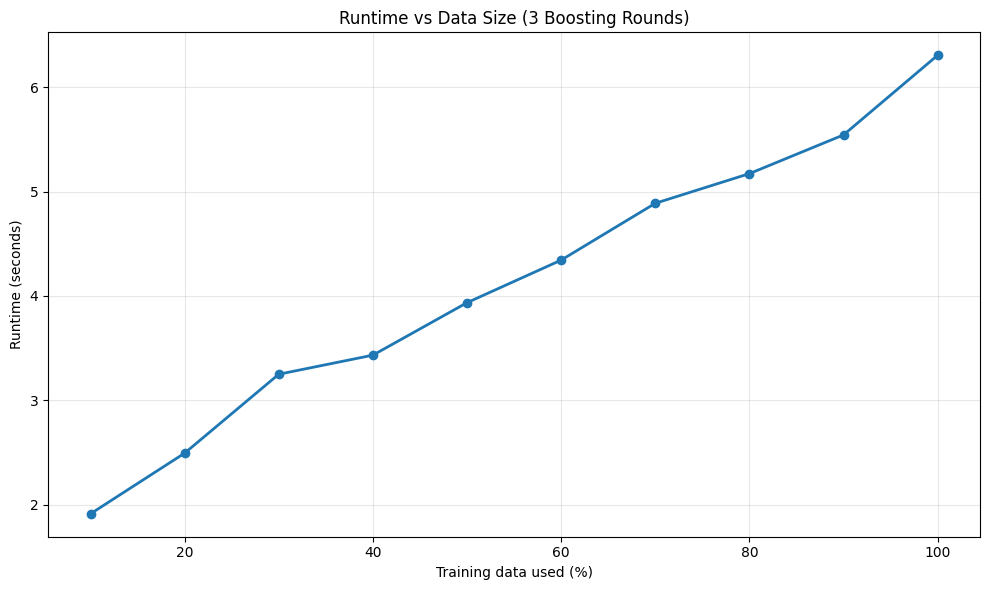

In [50]:
# Plot 1: Runtime vs data size
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(sizeup_percents, sizeup_times, "o-", linewidth=2)
ax.set_xlabel("Training data used (%)")
ax.set_ylabel("Runtime (seconds)")
ax.set_title(f"Runtime vs Data Size ({SIZEUP_MAX_ITER} Boosting Rounds)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

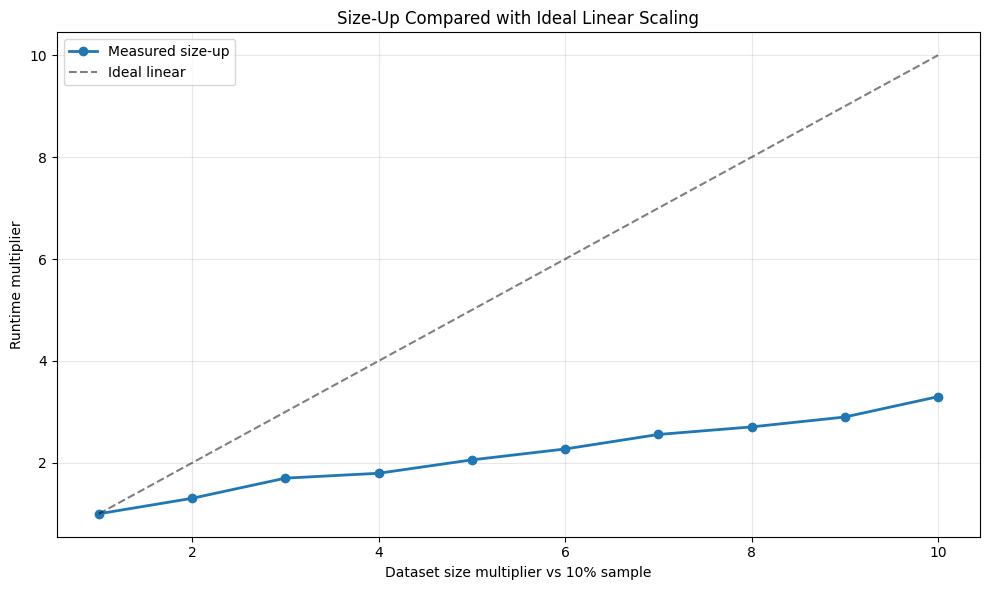

In [51]:
# Plot 2: Size-up vs ideal linear scaling
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(size_multipliers, sizeup_multipliers, "o-", linewidth=2, label="Measured size-up")
ax.plot(size_multipliers, size_multipliers, "k--", alpha=0.5, label="Ideal linear")
ax.set_xlabel(f"Dataset size multiplier vs {baseline_percent}% sample")
ax.set_ylabel("Runtime multiplier")
ax.set_title("Size-Up Compared with Ideal Linear Scaling")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


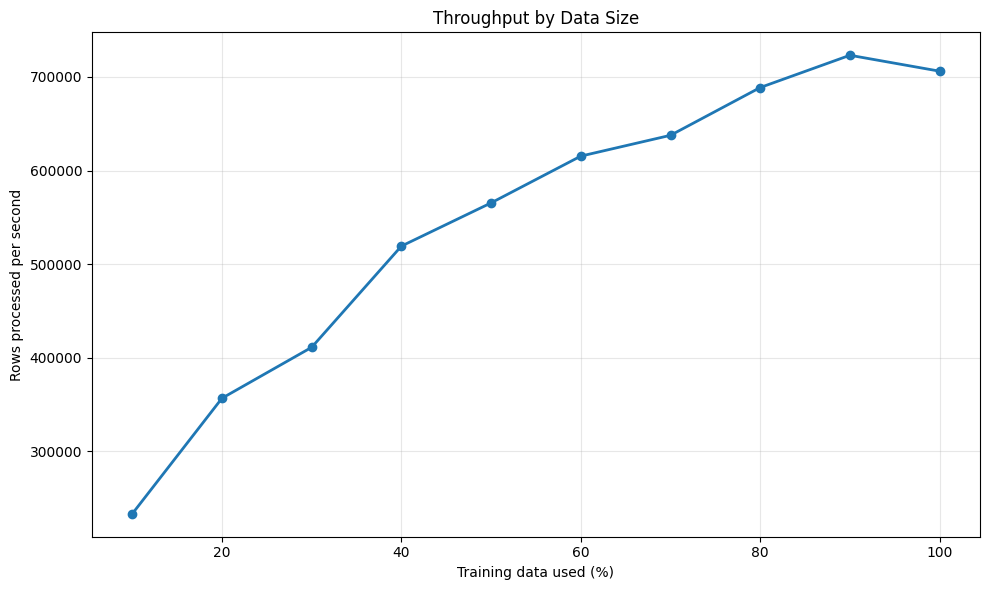

In [52]:
# Plot 3: Throughput by data size
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(sizeup_percents, sizeup_throughput, "o-", linewidth=2)
ax.set_xlabel("Training data used (%)")
ax.set_ylabel("Rows processed per second")
ax.set_title("Throughput by Data Size")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


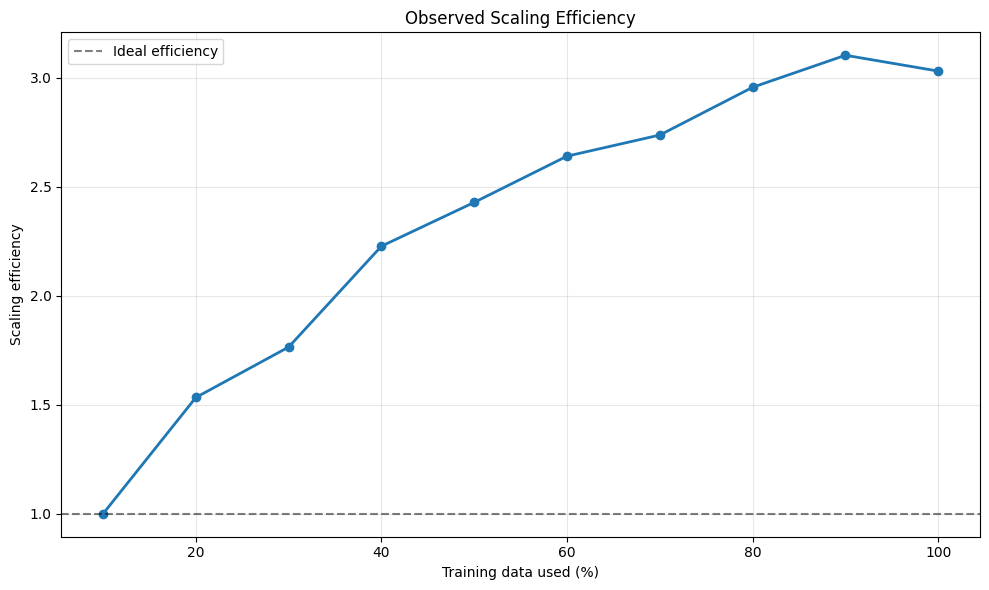

In [53]:
# Plot 4: Scaling efficiency
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(sizeup_percents, sizeup_efficiency, "o-", linewidth=2)
ax.axhline(1.0, color="black", linestyle="--", alpha=0.5, label="Ideal efficiency")
ax.set_xlabel("Training data used (%)")
ax.set_ylabel("Scaling efficiency")
ax.set_title("Observed Scaling Efficiency")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Now, we run iteration-scaling experiments dynamically on the full weighted training set to measure how runtime changes as boosting rounds increase.

In [54]:
ITERATION_ROUNDS = [1, 2, 3, 4, 5]
iteration_results = []

for rounds in ITERATION_ROUNDS:
    print(f"\n=== Iteration-scaling experiment: {rounds} boosting rounds ===")
    result = timed_train_adaboost(
        train_w,
        max_iter=rounds,
        label=f"{rounds} rounds"
    )
    result["rounds"] = rounds
    iteration_results.append(result)

    print(
        f"rounds={rounds} | rows={result['rows']:,} | "
        f"seconds={result['elapsed_seconds']:.3f} | "
        f"seconds/round={result['elapsed_seconds'] / rounds:.3f}"
    )


=== Iteration-scaling experiment: 1 boosting rounds ===

=== Boosting round 1/1 ===
Weighted error: 0.003293603441350096
Alpha: 2.856237001678615
rounds=1 | rows=4,454,299 | seconds=1.944 | seconds/round=1.944

=== Iteration-scaling experiment: 2 boosting rounds ===

=== Boosting round 1/2 ===
Weighted error: 0.003293603441350096
Alpha: 2.856237001678615

=== Boosting round 2/2 ===
Weighted error: 0.11389329145660287
Alpha: 1.0257877058541236
rounds=2 | rows=4,454,299 | seconds=3.428 | seconds/round=1.714

=== Iteration-scaling experiment: 3 boosting rounds ===

=== Boosting round 1/3 ===
Weighted error: 0.003293603441350096
Alpha: 2.856237001678615

=== Boosting round 2/3 ===
Weighted error: 0.11389329145660287
Alpha: 1.0257877058541236

=== Boosting round 3/3 ===
Weighted error: 0.17352879363903498
Alpha: 0.7804107677121463
rounds=3 | rows=4,454,299 | seconds=5.212 | seconds/round=1.737

=== Iteration-scaling experiment: 4 boosting rounds ===

=== Boosting round 1/4 ===
Weighted err

Convert the dynamic iteration-scaling results into a Spark DataFrame and plotting lists.

In [55]:
iteration_results_df = spark.createDataFrame([
    {
        "rounds": r["rounds"],
        "rows": r["rows"],
        "elapsed_seconds": r["elapsed_seconds"],
        "seconds_per_round": r["elapsed_seconds"] / r["rounds"],
        "rows_per_second": r["rows_per_second"],
        "n_models": r["n_models"]
    }
    for r in iteration_results
])

iteration_results_df.orderBy("rounds").show(20, truncate=False)

iteration_rounds = [r["rounds"] for r in iteration_results]
iteration_times = [r["elapsed_seconds"] for r in iteration_results]
seconds_per_round = [r["elapsed_seconds"] / r["rounds"] for r in iteration_results]

baseline_iter_time = iteration_times[0]
iteration_multipliers = [t / baseline_iter_time for t in iteration_times]


+------------------+--------+------+-------+------------------+------------------+
|elapsed_seconds   |n_models|rounds|rows   |rows_per_second   |seconds_per_round |
+------------------+--------+------+-------+------------------+------------------+
|1.9442999362945557|1       |1     |4454299|2290952.6029656706|1.9442999362945557|
|3.428271770477295 |2       |2     |4454299|1299284.099457453 |1.7141358852386475|
|5.212342023849487 |3       |3     |4454299|854567.6741125197 |1.7374473412831624|
|7.466081857681274 |4       |4     |4454299|596604.629430538  |1.8665204644203186|
|9.688478946685791 |5       |5     |4454299|459752.14731964865|1.9376957893371582|
+------------------+--------+------+-------+------------------+------------------+



Plotting iteration scaling from the collected results: raw runtime, runtime multiplier, and average seconds per boosting round.

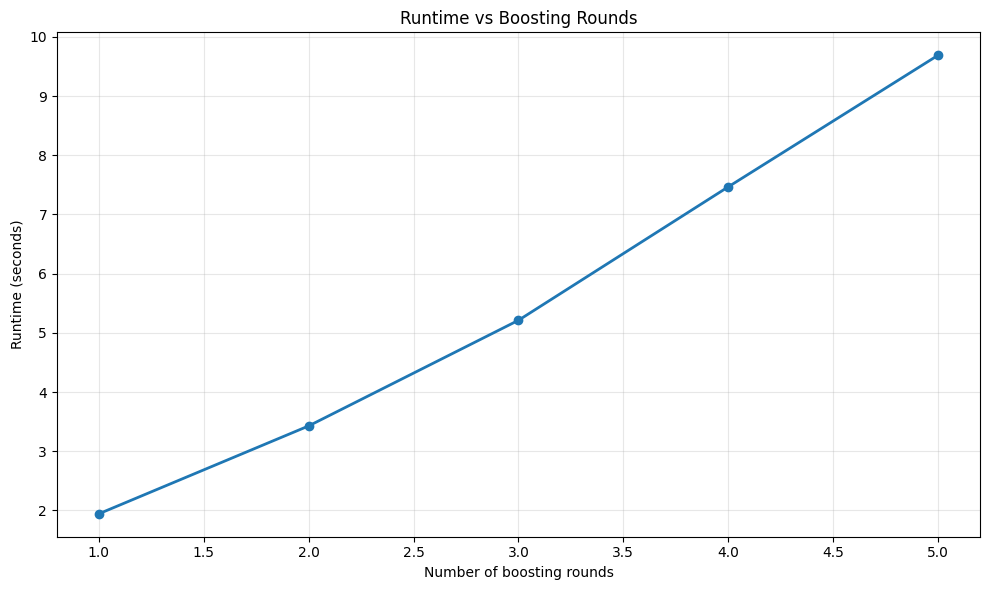

In [56]:
# Plot 1: Runtime vs boosting rounds
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(iteration_rounds, iteration_times, "o-", linewidth=2)
ax.set_xlabel("Number of boosting rounds")
ax.set_ylabel("Runtime (seconds)")
ax.set_title("Runtime vs Boosting Rounds")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

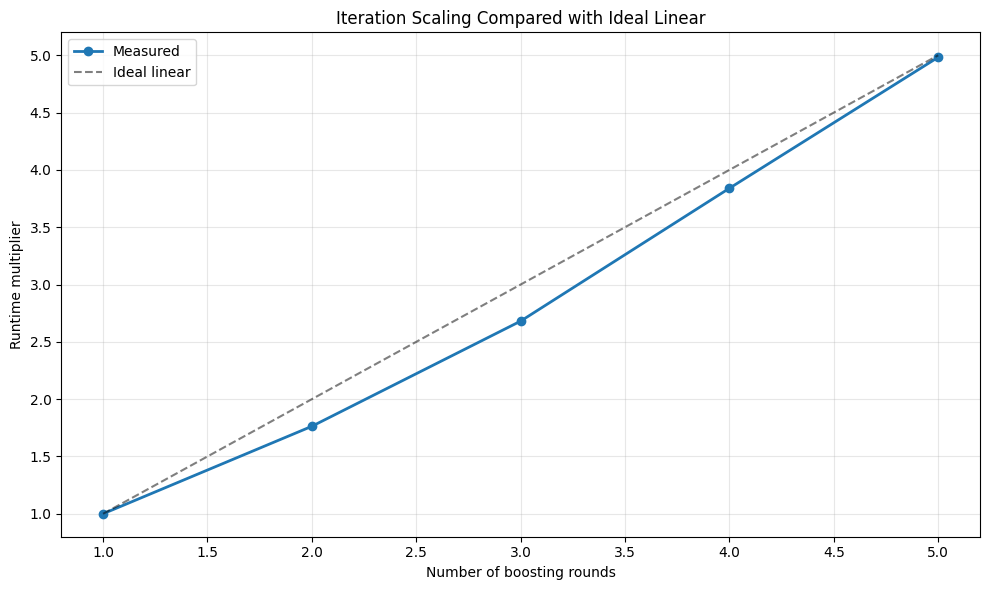

In [57]:
# Plot 2: Runtime multiplier vs ideal linear scaling
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(iteration_rounds, iteration_multipliers, "o-", linewidth=2, label="Measured")
ax.plot(iteration_rounds, iteration_rounds, "k--", alpha=0.5, label="Ideal linear")
ax.set_xlabel("Number of boosting rounds")
ax.set_ylabel("Runtime multiplier")
ax.set_title("Iteration Scaling Compared with Ideal Linear")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

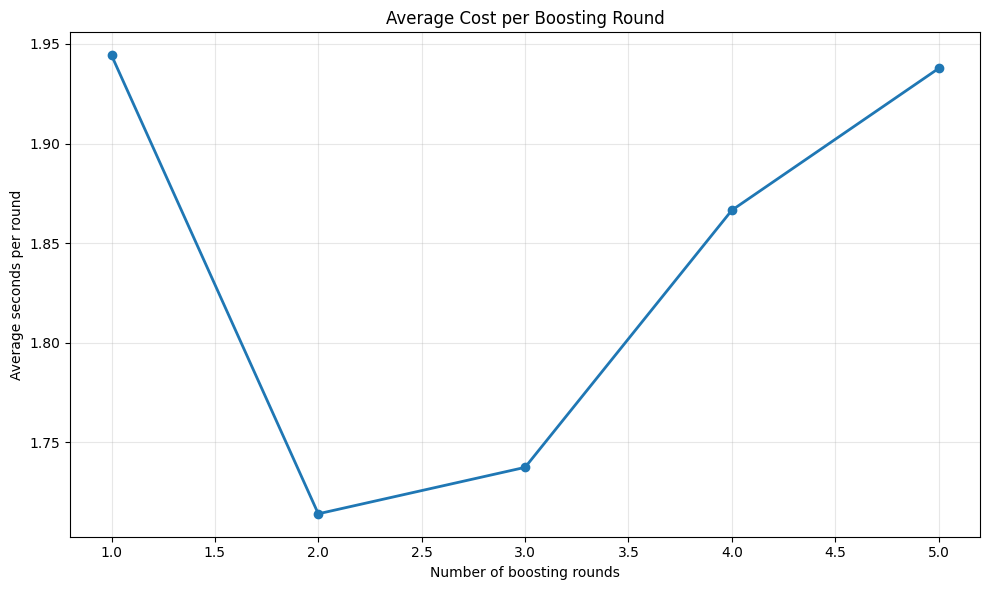

In [58]:
# Plot 3: Average cost per boosting round
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(iteration_rounds, seconds_per_round, "o-", linewidth=2)
ax.set_xlabel("Number of boosting rounds")
ax.set_ylabel("Average seconds per round")
ax.set_title("Average Cost per Boosting Round")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Confusion matrix visualization

In [59]:
cm_df = test_tuned.groupBy("label", "tuned_prediction").count()

cm = {(row["label"], row["tuned_prediction"]): row["count"] for row in cm_df.collect()}

# Extract values
TN = cm.get((0.0, 0.0), 0)
FP = cm.get((0.0, 1.0), 0)
FN = cm.get((1.0, 0.0), 0)
TP = cm.get((1.0, 1.0), 0)

print("TN:", TN, "FP:", FP, "FN:", FN, "TP:", TP)

TN: 953368 FP: 47 FN: 4 TP: 1178


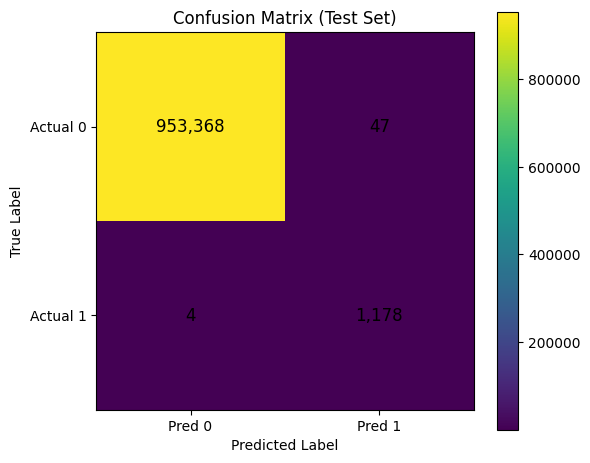

In [60]:
matrix = np.array([[TN, FP],
                   [FN, TP]])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(matrix)

# Labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred 0", "Pred 1"])
ax.set_yticklabels(["Actual 0", "Actual 1"])

# Add values inside cells
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{matrix[i, j]:,}", ha="center", va="center", fontsize=12)

ax.set_title("Confusion Matrix (Test Set)")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

plt.colorbar(im)
plt.tight_layout()
plt.show()

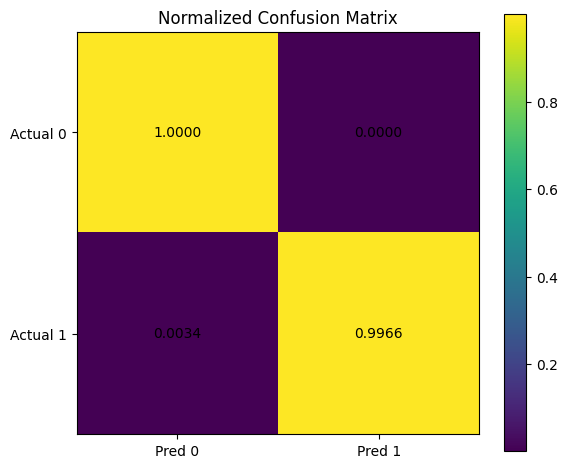

In [61]:
row_sums = matrix.sum(axis=1, keepdims=True)
matrix_norm = np.divide(matrix, row_sums, out=np.zeros_like(matrix, dtype=float), where=row_sums != 0)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(matrix_norm)

for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{matrix_norm[i, j]:.4f}", ha="center", va="center")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred 0", "Pred 1"])
ax.set_yticklabels(["Actual 0", "Actual 1"])

ax.set_title("Normalized Confusion Matrix")
plt.colorbar(im)
plt.tight_layout()
plt.show()


## Partitioning experiment

In [62]:
PARTITION_COUNTS = [8, 14, 20, 26, 30]
PARTITION_MAX_ITER = 3

partition_results = []

for n_parts in PARTITION_COUNTS:
    print(f"\n=== Partition experiment: {n_parts} partitions ===")

    # Repartitioning cached weighted training data for this experiment.
    # Normalize again because repartitioning/sampling experiments should keep weights summing to 1.
    train_part = normalize_weights(
        train_w.repartition(n_parts),
        weight_col="weights_0"
    ).cache()

    train_part.count()  # materialize cache

    start = time.time()

    models_p, alphas_p, history_p, final_df_p = train_distributed_adaboost(
        train_df=train_part,
        max_iter=PARTITION_MAX_ITER
    )

    train_seconds = time.time() - start

    valid_pred_p = predict_adaboost_ensemble(valid, models_p, alphas_p).cache()
    valid_pred_p.count()

    accuracy = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="ensemble_prediction",
        metricName="accuracy"
    ).evaluate(valid_pred_p)

    weighted_f1 = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="ensemble_prediction",
        metricName="f1"
    ).evaluate(valid_pred_p)

    roc_auc = BinaryClassificationEvaluator(
        labelCol="label",
        rawPredictionCol="ensemble_score",
        metricName="areaUnderROC"
    ).evaluate(valid_pred_p)

    pr_auc = BinaryClassificationEvaluator(
        labelCol="label",
        rawPredictionCol="ensemble_score",
        metricName="areaUnderPR"
    ).evaluate(valid_pred_p)

    cm = {
        (row["label"], row["ensemble_prediction"]): row["count"]
        for row in valid_pred_p.groupBy("label", "ensemble_prediction").count().collect()
    }

    tn = cm.get((0.0, 0.0), 0)
    fp = cm.get((0.0, 1.0), 0)
    fn = cm.get((1.0, 0.0), 0)
    tp = cm.get((1.0, 1.0), 0)

    fraud_precision = tp / (tp + fp) if (tp + fp) else 0.0
    fraud_recall = tp / (tp + fn) if (tp + fn) else 0.0
    fraud_f1 = (
        2 * fraud_precision * fraud_recall / (fraud_precision + fraud_recall)
        if (fraud_precision + fraud_recall)
        else 0.0
    )

    partition_results.append({
        "partitions": n_parts,
        "train_seconds": train_seconds,
        "accuracy": accuracy,
        "weighted_f1": weighted_f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "fraud_precision": fraud_precision,
        "fraud_recall": fraud_recall,
        "fraud_f1": fraud_f1,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "n_models": len(models_p),
        "alphas": alphas_p,
        "history": history_p
    })

    print(
        f"Partitions={n_parts} | "
        f"seconds={train_seconds:.3f} | "
        f"accuracy={accuracy:.6f} | "
        f"fraud_f1={fraud_f1:.6f} | "
        f"PR AUC={pr_auc:.6f}"
    )

    valid_pred_p.unpersist()
    train_part.unpersist()

    try:
        final_df_p.unpersist()
    except Exception:
        pass


=== Partition experiment: 8 partitions ===

=== Boosting round 1/3 ===
Weighted error: 0.0032830380584900677
Alpha: 2.8578488044411894

=== Boosting round 2/3 ===
Weighted error: 0.11238418356205962
Alpha: 1.033307899156106

=== Boosting round 3/3 ===
Weighted error: 0.17531813357660708
Alpha: 0.7741977329125042
Partitions=8 | seconds=6.994 | accuracy=0.999975 | fraud_f1=0.990244 | PR AUC=0.986511

=== Partition experiment: 14 partitions ===

=== Boosting round 1/3 ===
Weighted error: 0.003283262853870231
Alpha: 2.8578144569674158



=== Boosting round 2/3 ===
Weighted error: 0.1125205708560376
Alpha: 1.0326246428344328



=== Boosting round 3/3 ===
Weighted error: 0.1791389658481574
Alpha: 0.7610959904189444
Partitions=14 | seconds=6.971 | accuracy=0.999978 | fraud_f1=0.991453 | PR AUC=0.986524

=== Partition experiment: 20 partitions ===

=== Boosting round 1/3 ===
Weighted error: 0.0032828132631102162
Alpha: 2.85788315425908

=== Boosting round 2/3 ===
Weighted error: 0.1124525302554706
Alpha: 1.0329654138214241



=== Boosting round 3/3 ===
Weighted error: 0.17445648698220648
Alpha: 0.7771833103986827


Partitions=20 | seconds=6.788 | accuracy=0.999975 | fraud_f1=0.990244 | PR AUC=0.982635

=== Partition experiment: 26 partitions ===

=== Boosting round 1/3 ===
Weighted error: 0.003283712444630237
Alpha: 2.8577457690511303


...


=== Boosting round 3/3 ===
Weighted error: 0.18135219857907067
Alpha: 0.7536064837041961


Partitions=26 | seconds=7.754 | accuracy=0.999978 | fraud_f1=0.991453 | PR AUC=0.985753

=== Partition experiment: 30 partitions ===

=== Boosting round 1/3 ===
Weighted error: 0.0032841620353902473
Alpha: 2.857677090507654



=== Boosting round 2/3 ===
Weighted error: 0.11265659602735127
Alpha: 1.0319439205529182

=== Boosting round 3/3 ===


26/05/01 11:04:36 WARN BlockManager: Asked to remove block rdd_5956_4, which does not exist
26/05/01 11:04:36 WARN BlockManager: Asked to remove block rdd_5956_11, which does not exist
26/05/01 11:04:36 WARN BlockManager: Asked to remove block rdd_5956_14, which does not exist
26/05/01 11:04:36 WARN BlockManager: Asked to remove block rdd_5956_6, which does not exist
26/05/01 11:04:36 WARN BlockManager: Asked to remove block rdd_5956_29, which does not exist
26/05/01 11:04:36 WARN BlockManager: Asked to remove block rdd_5956_20, which does not exist


Weighted error: 0.17583593589438087
Alpha: 0.7724091195734915
Partitions=30 | seconds=6.449 | accuracy=0.999976 | fraud_f1=0.990647 | PR AUC=0.985780


In [63]:
partition_results_df = spark.createDataFrame([
    {
        "partitions": int(r["partitions"]),
        "train_seconds": float(r["train_seconds"]),
        "accuracy": float(r["accuracy"]),
        "weighted_f1": float(r["weighted_f1"]),
        "roc_auc": float(r["roc_auc"]),
        "pr_auc": float(r["pr_auc"]),
        "fraud_precision": float(r["fraud_precision"]),
        "fraud_recall": float(r["fraud_recall"]),
        "fraud_f1": float(r["fraud_f1"]),
        "tp": int(r["tp"]),
        "fp": int(r["fp"]),
        "fn": int(r["fn"]),
        "tn": int(r["tn"]),
        "n_models": int(r["n_models"])
    }
    for r in partition_results
])

partition_results_df.orderBy("partitions").show(truncate=False)


+------------------+---+---+------------------+------------------+------------------+--------+----------+------------------+------------------+------+----+-----------------+------------------+
|accuracy          |fn |fp |fraud_f1          |fraud_precision   |fraud_recall      |n_models|partitions|pr_auc            |roc_auc           |tn    |tp  |train_seconds    |weighted_f1       |
+------------------+---+---+------------------+------------------+------------------+--------+----------+------------------+------------------+------+----+-----------------+------------------+
|0.9999748354869963|4  |20 |0.9902439024390244|0.9838449111470113|0.9967266775777414|3       |8         |0.9865112889632179|0.9995706694410729|952482|1218|6.994055986404419|0.9999749172171324|
|0.9999779810511217|4  |17 |0.9914529914529915|0.9862348178137652|0.9967266775777414|3       |14        |0.9865237949129128|0.9995670760966413|952485|1218|6.970798015594482|0.9999780392271784|
|0.9999748354869963|4  |20 |0.99024

In [64]:
partition_counts = [r["partitions"] for r in partition_results]
partition_times = [r["train_seconds"] for r in partition_results]
partition_accuracy = [r["accuracy"] for r in partition_results]
partition_weighted_f1 = [r["weighted_f1"] for r in partition_results]
partition_pr_auc = [r["pr_auc"] for r in partition_results]
partition_fraud_f1 = [r["fraud_f1"] for r in partition_results]

baseline_partitions = partition_counts[0]
baseline_time = partition_times[0]

speedup = [baseline_time / t for t in partition_times]
ideal_speedup = [p / baseline_partitions for p in partition_counts]
efficiency = [
    measured / ideal if ideal else 0.0
    for measured, ideal in zip(speedup, ideal_speedup)
]


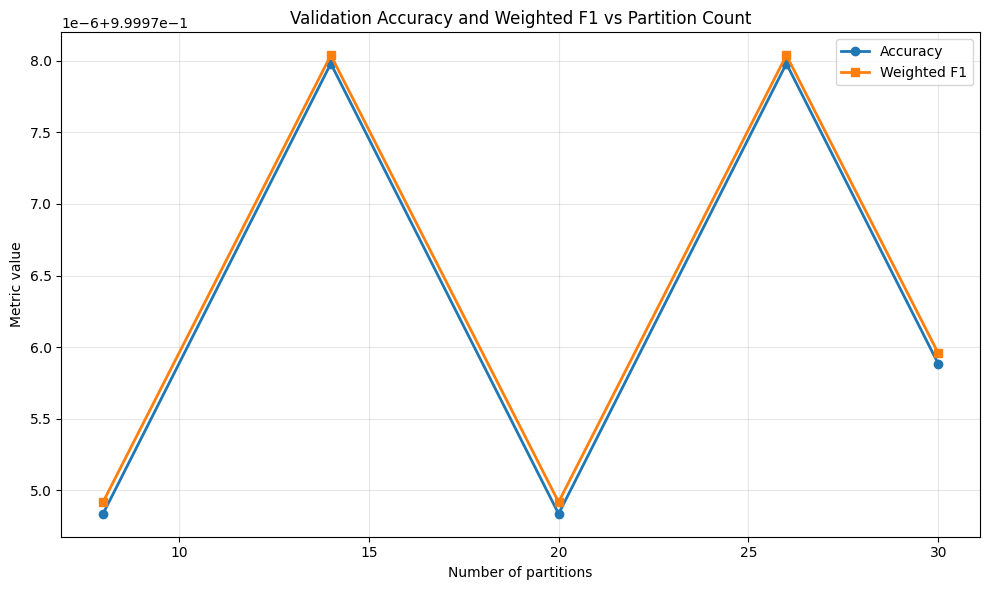

In [65]:
# Plot 1: Accuracy vs partition count
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(partition_counts, partition_accuracy, "o-", linewidth=2, label="Accuracy")
ax.plot(partition_counts, partition_weighted_f1, "s-", linewidth=2, label="Weighted F1")
ax.set_xlabel("Number of partitions")
ax.set_ylabel("Metric value")
ax.set_title("Validation Accuracy and Weighted F1 vs Partition Count")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


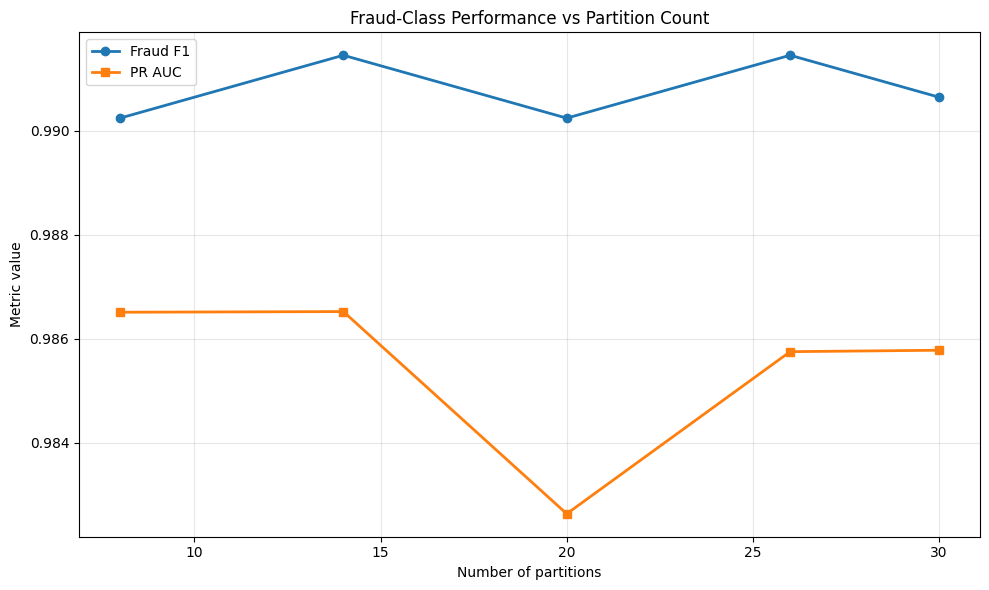

In [66]:
# Plot 2: fraud-class metrics vs partition count
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(partition_counts, partition_fraud_f1, "o-", linewidth=2, label="Fraud F1")
ax.plot(partition_counts, partition_pr_auc, "s-", linewidth=2, label="PR AUC")
ax.set_xlabel("Number of partitions")
ax.set_ylabel("Metric value")
ax.set_title("Fraud-Class Performance vs Partition Count")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


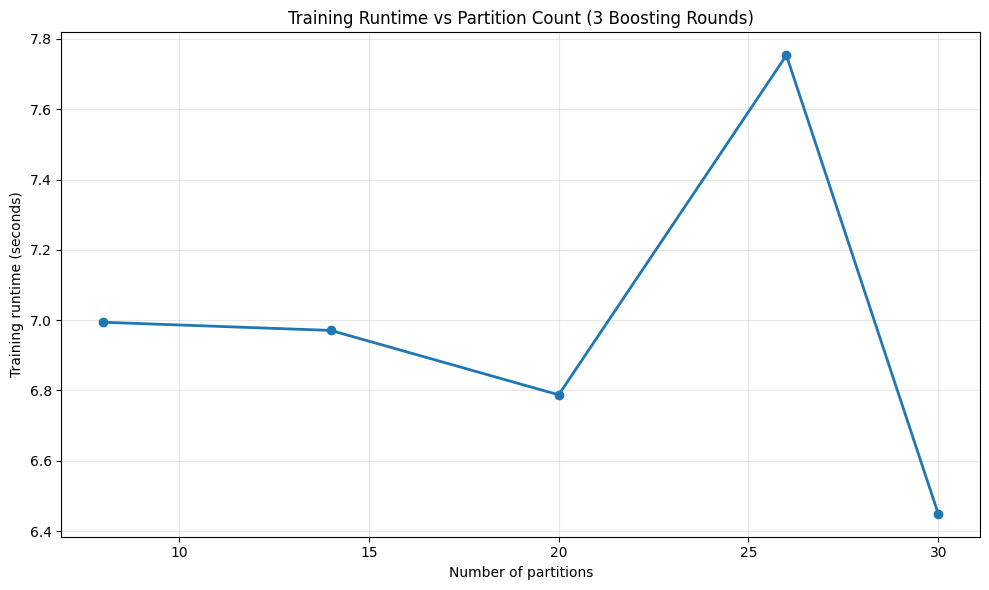

In [67]:
# Plot 3: runtime vs partition count.
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(partition_counts, partition_times, "o-", linewidth=2)
ax.set_xlabel("Number of partitions")
ax.set_ylabel("Training runtime (seconds)")
ax.set_title(f"Training Runtime vs Partition Count ({PARTITION_MAX_ITER} Boosting Rounds)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


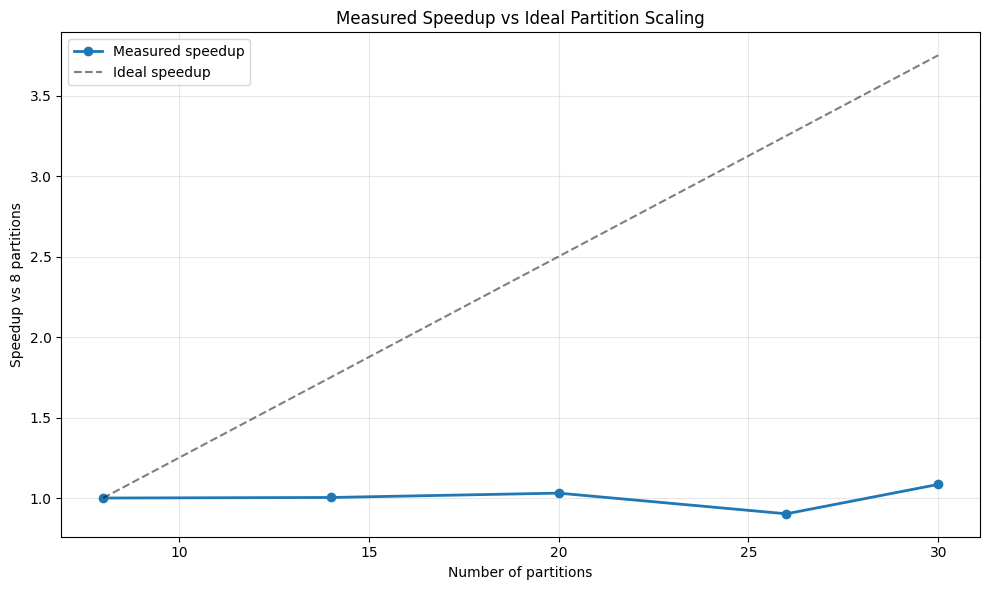

In [68]:
# Measured speedup vs ideal speedup
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(partition_counts, speedup, "o-", linewidth=2, label="Measured speedup")
ax.plot(partition_counts, ideal_speedup, "k--", alpha=0.5, label="Ideal speedup")
ax.set_xlabel("Number of partitions")
ax.set_ylabel(f"Speedup vs {baseline_partitions} partitions")
ax.set_title("Measured Speedup vs Ideal Partition Scaling")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


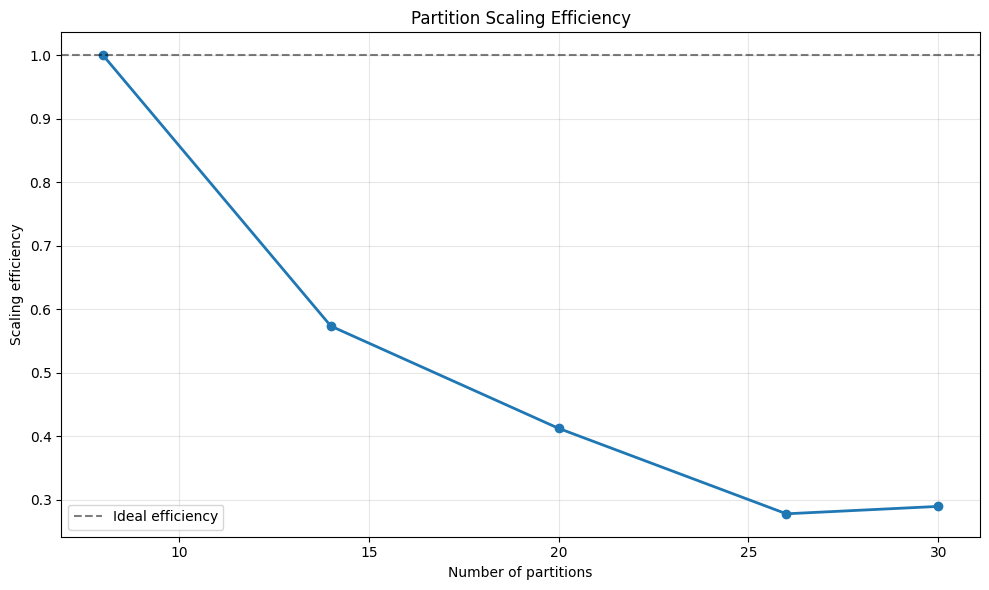

In [69]:
#Plot 5: scaling efficiency.
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(partition_counts, efficiency, "o-", linewidth=2)
ax.axhline(1.0, color="black", linestyle="--", alpha=0.5, label="Ideal efficiency")
ax.set_xlabel("Number of partitions")
ax.set_ylabel("Scaling efficiency")
ax.set_title("Partition Scaling Efficiency")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [70]:
spark.stop()

Dependencies:

```appnope==0.1.4
asttokens==3.0.1
comm==0.2.3
contourpy==1.3.3
cycler==0.12.1
debugpy==1.8.20
decorator==5.2.1
executing==2.2.1
fonttools==4.61.1
ipykernel==7.2.0
ipython==9.10.0
ipython_pygments_lexers==1.1.1
jedi==0.19.2
jupyter_client==8.8.0
jupyter_core==5.9.1
kiwisolver==1.4.9
matplotlib==3.10.8
matplotlib-inline==0.2.1
nest-asyncio==1.6.0
numpy==2.4.2
packaging @ file:///home/conda/feedstock_root/build_artifacts/bld/rattler-build_packaging_1769093650/work
pandas==3.0.1
parso==0.8.6
pexpect==4.9.0
pillow==12.1.1
platformdirs==4.9.2
prompt_toolkit==3.0.52
psutil==7.2.2
ptyprocess==0.7.0
pure_eval==0.2.3
py4j==0.10.9.9
Pygments==2.19.2
pyparsing==3.3.2
pyspark==4.1.1
python-dateutil==2.9.0.post0
pyzmq==27.1.0
setuptools==82.0.0
six==1.17.0
stack-data==0.6.3
tornado==6.5.4
traitlets==5.14.3
wcwidth==0.6.0
wheel==0.46.3```